In [12]:
import tensorflow as tf
import tensorflow_probability as tfp 
import tensorflow_addons as tfa
from tensorflow import keras

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import IsolationForest

import numpy as np
import pandas as pd
import functions
from Models.LSTM_VAE import LSTM_VAE
from Models.LSTM_AE import LSTM_AE
from Models.DAGMM import DAGMM_AE
from Models.USAD import USAD_MTS
from Models.COUTA import COUTA
from Models.CTAD import CTAD
from Models.LSTM_CBCL import LSTM_CBCL
from Models.Sklearn_models import PCA_AE_for_MTS, IsolationForest_MTS

import ast, os, gc, shutil, math
import pickle


In [13]:
# 1. TensorFlow version
print("TF version:", tf.__version__)

# 2. Is this a GPU build?
print("Built with CUDA:", tf.test.is_built_with_cuda())

# 3. Any GPUs visible?
print("Physical GPUs:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print("Could not set memory growth:", e)


TF version: 2.10.0
Built with CUDA: True
Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [14]:
WINDOW_SIZE = 10
STRIDE = 1
LATENT_DIM = 10
LSTM_H_DIM = 128
DROPOUT_RATE = 0.2
KL_BETA = 1.0
KERNEL_REGULARIZER = keras.regularizers.L2(1e-4)
SMALL=64
MED=128
LARGE=256
XLARGE=512
XXLARGE=1024
EPOCHS = 100
LEARNING_RATE = 3e-4
CLIPNORM = 10.0
EARLY_STOP_PATIENCE = 5

PCA_COMP = 10
IF_ESTIMATORS=300

# COUTA PARAM
COUTA_DIMS = [16]
COUTA_EMB_DIM = 16

# CTAD PARAM
CTAD_LSTM=64
CTAD_PROJECTION_HU=128
CTAD_LATENT_DIM=32
                
                
LSTM_CBCL_HIDDEN_UNITS = 64
NUM_LAYERS=2
LSTM_LATENT_DIM=10
BOTTLENECK=True 
MLP_HU=128
REP_DIM=128

In [ ]:
class ModelGenerator():
    @staticmethod
    def get_PCA_AE(n_components=PCA_COMP, window_size=WINDOW_SIZE, use_incremental=False):
        return PCA_AE_for_MTS(n_components=n_components, window_size=window_size, use_incremental=use_incremental)
    
    @staticmethod
    def get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42):
        return IsolationForest_MTS(n_estimators=n_estimators, max_samples=max_samples, contamination=contamination, random_state=random_state)
    
    @staticmethod
    def get_LSTM_AE(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size=MED):
        LSTM_AE_model = LSTM_AE(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size=batch_size)
        LSTM_AE_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                              loss_fn=keras.losses.MeanSquaredError(), 
                              clipnorm=CLIPNORM, 
                              early_stop_patience=EARLY_STOP_PATIENCE)
        return LSTM_AE_model
    
    @staticmethod
    def get_LSTM_VAE(timesteps=WINDOW_SIZE, n_features=None, lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED):
        LSTM_VAE_model = LSTM_VAE(timesteps=timesteps, n_features=n_features, lstm_h_dim=lstm_h_dim, latent_dim=latent_dim, 
                                  dropout_rate=DROPOUT_RATE, kl_beta=KL_BETA, batch_size=batch_size)
        LSTM_VAE_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), 
                               clipnorm=CLIPNORM, 
                               early_stop_patience=EARLY_STOP_PATIENCE)
        return LSTM_VAE_model
    
    @staticmethod
    def get_DAGMM(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size=LARGE):
        DAGMM_model = DAGMM_AE(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size=batch_size)
        DAGMM_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), clipnorm=CLIPNORM, early_stop_patience=EARLY_STOP_PATIENCE)
        return DAGMM_model
        
    @staticmethod
    def get_USAD(timesteps=WINDOW_SIZE, n_features=None, latent_dim=LATENT_DIM, batch_size = MED):
        USAD_model = USAD_MTS(timesteps=timesteps, n_features=n_features, latent_dim=latent_dim, batch_size = batch_size)
        USAD_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE), clipnorm=CLIPNORM, early_stop_patience=EARLY_STOP_PATIENCE)
        return USAD_model
        
    @staticmethod
    def get_COUTA(input_dim=None, hidden_dims=[16], emb_dim = 16, dropout_rate=DROPOUT_RATE, batch_size=SMALL):
        couta_model = COUTA(input_dim=input_dim, hidden_dims=hidden_dims, emb_dim = emb_dim, dropout_rate=dropout_rate, batch_size=batch_size)
        couta_model.compile(keras.optimizers.Adam(learning_rate=LEARNING_RATE))
        return couta_model
    
    @staticmethod
    def get_CTAD(lstm_units=64, projection_hu=128, latent_dim=32, kernel_regularizer=None, dropout_rate=0.0,
                 batch_size=512, clip_val=1, patience =5, score='l2', aug_params={}):
        ctad_model = CTAD(lstm_units=lstm_units, projection_hu=projection_hu, latent_dim=latent_dim, kernel_regularizer=kernel_regularizer, dropout_rate=dropout_rate,
                 batch_size=batch_size, clip_val=clip_val, patience = patience, score=score)
        ctad_model.compile(tf.optimizers.Adam(learning_rate=1e-4))
        ctad_model.set_aug_params(nv_pos1=aug_params["nv_pos1"], nv_pos2=aug_params["nv_pos2"], nv_neg1=aug_params["nv_neg1"], nv_neg2=aug_params["nv_neg2"], 
                                p_pos1=aug_params["p_pos1"], p_pos2=aug_params["p_pos2"], p_neg1=aug_params["p_neg1"], p_neg2=aug_params["p_neg2"],
                                noise_sigma=aug_params["noise_sigma"], bias=aug_params["bias"], amp=aug_params["amp"])
        return ctad_model
    
    @staticmethod
    def get_LSTM_CBCL(timesteps=WINDOW_SIZE, n_features = None, latent_dim=LATENT_DIM, num_layers=2, bottleneck=True, 
                    hidden_units = 64, dropout_rate=0.2, kernel_regularizer=False, batch_size=512, patience=5, recurrent_regularizer=True, MLP_hu=MLP_HU, rep_dim=REP_DIM, aug_params={}):
        LSTM_CBCL_model = LSTM_CBCL(timesteps=timesteps, n_features = n_features, latent_dim=latent_dim, num_layers=num_layers, bottleneck=bottleneck, 
                                hidden_units = hidden_units, dropout_rate=dropout_rate, kernel_regularizer=kernel_regularizer, batch_size=batch_size, 
                                patience=patience, recurrent_regularizer=recurrent_regularizer, MLP_hu=MLP_hu, rep_dim=rep_dim)
        LSTM_CBCL_model.compile(tfa.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5))
        LSTM_CBCL_model.set_aug_params(nv_pos1=aug_params["nv_pos1"], nv_pos2=aug_params["nv_pos2"], nv_neg1=aug_params["nv_neg1"], nv_neg2=aug_params["nv_neg2"], 
                                p_pos1=aug_params["p_pos1"], p_pos2=aug_params["p_pos2"], p_neg1=aug_params["p_neg1"], p_neg2=aug_params["p_neg2"],
                                noise_sigma=aug_params["noise_sigma"], bias=aug_params["bias"], amp=aug_params["amp"])
        return LSTM_CBCL_model

In [ ]:
def run_models(models, train_ds, test_ds, y_true:np.ndarray, epochs=50, verbose=1, use_timestamp_level=False, use_point_adjust=False, stride=STRIDE, frame=WINDOW_SIZE):
    preds = {}
    anom_scores = {}
    expected_anom_ratio = y_true.sum() / len(y_true)
    for model_name, model in models.items():
        print(f"\t\tTraining: {model_name}")
        if isinstance(model, (LSTM_AE, LSTM_VAE, DAGMM_AE, USAD_MTS, COUTA, CTAD, LSTM_CBCL)):
            model.fit_manual(train_ds, epochs=epochs, verbose=verbose)
            anom_score = model.score(test_ds)
        elif isinstance(model, (PCA_AE_for_MTS, IsolationForest_MTS)):
            model.fit(train_ds)
            anom_score = model.score(test_ds)['anomaly_score']
        else: 
            break
        
        if use_timestamp_level:
            scores = functions.timestamp_score_maxpooling(anom_score, stride=stride, n_timestamps=len(y_true), frame_length=frame)
            anom_scores[model_name] = scores
            preds[model_name] = (scores > np.percentile(scores, (1.0-expected_anom_ratio)*100)).astype(int)
            if use_point_adjust:
                if isinstance(y_true, pd.Series):
                    y_true = y_true.to_numpy()
                preds[model_name] = functions.point_adjust(y_true=y_true.reshape([-1]), y_pred=preds[model_name])
        else:
            anom_scores[model_name] = anom_score
            y_preds = (anom_score > np.percentile(anom_score, (1.0-expected_anom_ratio)*100)).astype(int)
            preds[model_name] = y_preds

    tf.keras.backend.clear_session()
    gc.collect()
    return preds, anom_scores

def train_baselines_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_baselines_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # BASELINES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=True)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:   
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_baselines_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # BASELINES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_baselines_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            models = {
                'PCA_AE' : ModelGenerator().get_PCA_AE(n_components=PCA_COMP, window_size=window_size, use_incremental=False),
                'IsoForest_MTS': ModelGenerator().get_IF_MTS(n_estimators=IF_ESTIMATORS, max_samples='auto', contamination='auto', random_state=42),
                'LSTM_AE': ModelGenerator().get_LSTM_AE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=MED),
                'LSTM_VAE': ModelGenerator().get_LSTM_VAE(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], lstm_h_dim=LSTM_H_DIM, latent_dim=LATENT_DIM, batch_size=MED),
                'DAGMM_AE': ModelGenerator().get_DAGMM(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size=LARGE),
                'USAD_MTS': ModelGenerator().get_USAD(timesteps=window_size, n_features=train_ds.element_spec.shape[-1], latent_dim=LATENT_DIM, batch_size = MED)
            }
            preds, anom_scores = run_models(models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del models
            return preds, anom_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_SMD(server, m, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, 
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_COUTA_PSM(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, lazy=True, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_PSM_windows(mm_clip_scaler, window_size=window_size, frame_step=frame_step, lazy=lazy)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=STRIDE, frame=WINDOW_SIZE)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_SMAP_MSL(rover, sys, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose, 
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_COUTA_WADI(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            couta_train_ds, couta_test_ds, test_labels = functions.load_preprocessed_WADI_windows(mm_clip_scaler, window_size=window_size, frame_step=frame_step)
            couta_train_ds, couta_test_ds = couta_train_ds.cache().prefetch(tf.data.AUTOTUNE), couta_test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'COUTA' : ModelGenerator().get_COUTA(input_dim=couta_train_ds.element_spec.shape[-1], hidden_dims=COUTA_DIMS, 
                                                        emb_dim = COUTA_EMB_DIM, dropout_rate=DROPOUT_RATE, batch_size=SMALL)
                }
            proto_preds, proto_scores = run_models(prototype_models, couta_train_ds, couta_test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                    batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.5, "amp":2
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, 
                                                verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_CTAD_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: 
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=True)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                            batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.5, "amp":2
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                    batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='l2',
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.2, "amp":1.5
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMAP_MSL dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_CTAD_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'CTAD' : ModelGenerator().get_CTAD(lstm_units=CTAD_LSTM, projection_hu=CTAD_PROJECTION_HU, latent_dim=CTAD_LATENT_DIM, kernel_regularizer=None, dropout_rate=DROPOUT_RATE,
                                                            batch_size=XLARGE, clip_val=CLIPNORM, patience = EARLY_STOP_PATIENCE, score='cosine',
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.1, "amp":1.5,
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, verbose=verbose,
                                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, stride=frame_step, frame=window_size)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except  tf.errors.ResourceExhaustedError as e:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue


def train_LSTM_CBCL_SMD(server, m, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_SMD_windows(server, m, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_SMD(server, m)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=1, bottleneck=BOTTLENECK, 
                                                    hidden_units = 256, dropout_rate=0.1, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=64, rep_dim=64,
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.8, "amp": 1.5
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels

        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on SMD dataset, retrying...")
            tf.keras.backend.clear_session()
            gc.collect() 
            continue

def train_LSTM_CBCL_PSM(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, lazy=True, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_PSM_windows(scaler, window_size=window_size, frame_step=frame_step, lazy=lazy)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_PSM()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=NUM_LAYERS, bottleneck=BOTTLENECK, 
                                                          hidden_units = 128, dropout_rate=0.2, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=64, rep_dim=32,
                                                          aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.01, "bias":0.7, "amp": 1.5
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels

        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_LSTM_CBCL_SMAP_MSL(rover, sys, scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True: # PROTOTYPES
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_MSL_SMAP_windows(rover, sys, scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_MSL_SMAP(rover, sys)
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=NUM_LAYERS, bottleneck=BOTTLENECK, 
                                                    hidden_units = LSTM_CBCL_HIDDEN_UNITS, dropout_rate=0.1, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=MLP_HU, rep_dim=REP_DIM,
                                                    aug_params = {
                                                        "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                        "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                        "noise_sigma":0.05, "bias":0.8, "amp": 1.5
                                                    })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels

        except tf.errors.ResourceExhaustedError as e:
            print("OOM Error on PSM dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue

def train_LSTM_CBCL_WADI(scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, use_timestamp_level=False, use_point_adjust=False, verbose=0):
    while True:
        try:
            train_ds, test_ds, test_labels = functions.load_preprocessed_WADI_windows(scaler, window_size=window_size, frame_step=frame_step)
            train_ds, test_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE), test_ds.cache().prefetch(tf.data.AUTOTUNE)
            if use_timestamp_level: 
                _, _, test_labels = functions.load_WADI()
                if isinstance(test_labels, pd.DataFrame):
                    test_labels = test_labels.to_numpy()
            prototype_models = {
                'LSTM_CBCL' : ModelGenerator.get_LSTM_CBCL(timesteps=window_size, n_features = train_ds.element_spec.shape[-1], latent_dim=LSTM_LATENT_DIM, num_layers=NUM_LAYERS, bottleneck=BOTTLENECK, 
                                                          hidden_units = LSTM_CBCL_HIDDEN_UNITS, dropout_rate=0.1, kernel_regularizer=True, batch_size=XLARGE, patience=5, recurrent_regularizer=True, MLP_hu=128, rep_dim=128,
                                                            aug_params = {
                                                                "nv_pos1":train_ds.element_spec.shape[1], "nv_pos2":int(train_ds.element_spec.shape[1]/2), "nv_neg1":1, "nv_neg2":1, 
                                                                "p_pos1":0.5, "p_pos2":0.5, "p_neg1":0.5, "p_neg2":0.5,
                                                                "noise_sigma":0.05, "bias":0.2, "amp": 1.5,
                                                            })
                }
            proto_preds, proto_scores = run_models(prototype_models, train_ds, test_ds, test_labels, epochs=EPOCHS, stride=frame_step, frame=window_size,
                                                            verbose=verbose, use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust)
            del prototype_models
            return proto_preds, proto_scores, test_labels
        except:
            print("OOM Error on WADI dataset")
            tf.keras.backend.clear_session()
            gc.collect()
            continue


def run_results(use_timestamp_level=False, use_point_adjust=False, verbose=0):
    F1_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    roc_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    print ('Testing models on SMD dataset:')
    smd_combos = {1:[1, 5], 2:[3,4], 3:[2,10]}
    for server, machines in smd_combos.items():
        for m in machines:
            print (f"\t Server {server} - Machine {m}")
            std_scaler = StandardScaler()
            mm_scaler = MinMaxScaler()
            mm_clip_scaler = functions.MinMaxClippingScaler(4)
            preds, anom_scores, test_labels = train_baselines_SMD(server, m, std_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            #couta_preds, couta_scores, test_labels = train_COUTA_SMD(server, m, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
            #                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            #ctad_preds, ctad_scores, test_labels = train_CTAD_SMD(server, m, mm_scaler, window_size=4, frame_step=STRIDE, 
            #                                         use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_SMD(server, m, mm_scaler, window_size=4, frame_step=1, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            """ preds['COUTA'] = couta_preds['COUTA']
            anom_scores['COUTA'] = couta_scores['COUTA']
            preds['CTAD'] = ctad_preds['CTAD']
            anom_scores['CTAD'] = ctad_scores['CTAD'] """
            preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
            anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']

            f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_pr-bar.png')
            functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMD/{server}_{m}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMD"]:
                    F1_scores["SMD"][model] = []
                    roc_scores["SMD"][model] = []
                F1_scores["SMD"][model].append(f1_scores[model])
                roc_scores["SMD"][model].append(roc_score[model])
            tf.keras.backend.clear_session()
            gc.collect() 
            
    """ print ("Testing models on PSM dataset:")
    std_scaler = StandardScaler()
    mm_scaler = MinMaxScaler()
    mm_clip_scaler = functions.MinMaxClippingScaler(4)
    preds, anom_scores, test_labels = train_baselines_PSM(std_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    couta_preds, couta_scores, test_labels = train_COUTA_PSM(mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                 use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    ctad_preds, ctad_scores, test_labels = train_CTAD_PSM(mm_scaler, window_size=4, frame_step=STRIDE, 
                                              use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_PSM(mm_scaler, window_size=5, frame_step=1, lazy=True, 
                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    preds['COUTA'] = couta_preds['COUTA']
    anom_scores['COUTA'] = couta_scores['COUTA'] 
    preds['CTAD'] = ctad_preds['CTAD']
    anom_scores['CTAD'] = ctad_scores['CTAD']
    preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
    anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
            
    f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Comparisons/PSM/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/pr-bar.png')
    functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/PSM/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["PSM"][model]= [f1_scores[model]]
        roc_scores["PSM"][model] = [roc_score[model]]
    tf.keras.backend.clear_session() 
    gc.collect()  """
    
    
    print ("Testing models on SMAP_MSL dataset:")
    SMAP_MSL_combos = {'A':1, 'B':1, 'C':1, 'D':2, 'E':1, 'F':1, 'G':1, 'M': 2, 'P':1, 'R':1, 'S':1, 'T':2}
    print("Using window size of 10...")
    """ for rover, n_systems in SMAP_MSL_combos.items():
        for sys in range(1, n_systems+1):
            print (f"\t Rover {rover} - Number {sys}")
            std_scaler = StandardScaler()
            mm_scaler = MinMaxScaler()
            mm_clip_scaler = functions.MinMaxClippingScaler(4)
            preds, anom_scores, test_labels = train_baselines_SMAP_MSL(rover, sys, std_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            couta_preds, couta_scores, test_labels = train_COUTA_SMAP_MSL(rover, sys, mm_clip_scaler, window_size=WINDOW_SIZE, frame_step=STRIDE, 
                                                         use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            ctad_preds, ctad_scores, test_labels = train_CTAD_SMAP_MSL(rover, sys, mm_scaler, window_size=4, frame_step=STRIDE, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_SMAP_MSL(rover, sys, mm_scaler, window_size=4, frame_step=1, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
            preds['COUTA'] = couta_preds['COUTA']
            anom_scores['COUTA'] = couta_scores['COUTA']
            preds['CTAD'] = ctad_preds['CTAD']
            anom_scores['CTAD'] = ctad_scores['CTAD']
            preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
            anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
        
            f1_scores =functions.display_f1_models(test_labels, preds, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-bar.png')
            functions.compare_pr_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path=f'Model Comparisons/SMAP_MSL/{rover}_{sys}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMAP_MSL"]:
                    F1_scores["SMAP_MSL"][model] = []
                    roc_scores["SMAP_MSL"][model] = []
                F1_scores["SMAP_MSL"][model].append(f1_scores[model])
                roc_scores["SMAP_MSL"][model].append(roc_score[model])
                
            tf.keras.backend.clear_session() 
            gc.collect()  """
   
                      
    print ("Testing models on WADI dataset:")
    """ std_scaler = StandardScaler()
    mm_scaler = MinMaxScaler()
    mm_clip_scaler = functions.MinMaxClippingScaler(4)
    wadi_frame_l, wadi_stride = 25, 10
    preds, anom_scores, test_labels = train_baselines_WADI(std_scaler, window_size=wadi_frame_l, frame_step=wadi_stride, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    couta_preds, couta_scores, test_labels = train_COUTA_WADI(mm_clip_scaler, window_size=wadi_frame_l, frame_step=wadi_stride, 
                                                use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    ctad_preds, ctad_scores, test_labels = train_CTAD_WADI(mm_scaler, window_size=4, frame_step=wadi_stride, 
                                            use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    lstm_preds, lstm_scores, test_labels = train_LSTM_CBCL_WADI(mm_scaler, window_size=4, frame_step=5, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)

    
    preds['COUTA'] = couta_preds['COUTA']
    anom_scores['COUTA'] = couta_scores['COUTA']
    preds['CTAD'] = ctad_preds['CTAD']
    anom_scores['CTAD'] = ctad_scores['CTAD']
    preds['LSTM_CBCL'] = lstm_preds['LSTM_CBCL']
    anom_scores['LSTM_CBCL'] = lstm_scores['LSTM_CBCL']
    
    f1_scores = functions.display_f1_models(test_labels, preds, save=True, save_path='Model Comparisons/WADI/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/pr-bar.png')
    functions.compare_pr_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, anom_scores, save=True, save_path='Model Comparisons/WADI/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["WADI"][model]= [f1_scores[model]]
        roc_scores["WADI"][model] = [roc_score[model]]  """ 
        
    tf.keras.backend.clear_session() 
    gc.collect() 
    
    avg_f1s, avg_rocs = {}, {}
    for dataset in F1_scores.keys():
        avg_f1s[dataset]={}
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in F1_scores[dataset].keys():
            avg_f1 = np.mean(F1_scores[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in roc_scores.keys():
        avg_rocs[dataset]={}
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in roc_scores[dataset].keys():
            avg_roc = np.mean(roc_scores[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocs[dataset][model] = avg_roc
    print(avg_f1s, avg_rocs)
    with open("Model Comparisons/Dataset Performance/model_f1.pkl", "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open("Model Comparisons/Dataset Performance/model_rocauc.pkl", "wb") as f:
        pickle.dump(avg_rocs, f)    
    
    functions.visualize_model_results(avg_f1s, avg_rocs, save=True, save_path='Model Comparisons/Dataset Performance/')

In [17]:
def compare_existing_scores(dir='Model Comparisons - Point Adjusted', new_f1s={}, new_rocs={}):
    with open(os.path.join(dir, 'model_f1.pkl'), 'rb') as f:
        avg_f1s = pickle.load(f)
        
    with open(os.path.join(dir, 'model_rocauc.pkl'), 'rb') as f:
        avg_rocauc = pickle.load(f)
    
    for dataset in new_f1s.keys():
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in new_f1s[dataset].keys():
            avg_f1 = np.mean(new_f1s[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in new_rocs.keys():
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in new_rocs[dataset].keys():
            avg_roc = np.mean(new_rocs[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocauc[dataset][model] = avg_roc

    with open(os.path.join(dir, 'model_f1.pkl'), "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open(os.path.join(dir, 'model_rocauc.pkl'), "wb") as f:
        pickle.dump(avg_rocauc, f)    
        
    functions.visualize_model_results(avg_f1s, avg_rocauc, save=True, save_path=dir)
    


In [18]:
def extra_model_results(use_timestamp_level=False, use_point_adjust=False, verbose=0):
    F1_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    roc_scores = {"SMD": {}, "PSM": {}, "SMAP_MSL": {}, "WADI": {}}
    print ('Testing models on SMD dataset:')
    smd_combos = {1:[1, 5], 2:[3,4], 3:[2,10]}
    for server, machines in smd_combos.items():
        for m in machines:
            print (f"\t Server {server} - Machine {m}")
            scaler = MinMaxScaler()
            proto_preds, proto_scores, test_labels = train_LSTM_CBCL_SMD(server, m, scaler, window_size=4, frame_step=1, 
                                                     use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
                                
            f1_scores = functions.display_f1_models(test_labels, proto_preds, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_pr-bar.png')
            functions.compare_pr_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMD/{server}_{m}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMD"]:
                    F1_scores["SMD"][model] = []
                    roc_scores["SMD"][model] = []
                F1_scores["SMD"][model].append(f1_scores[model])
                roc_scores["SMD"][model].append(roc_score[model])
                
            tf.keras.backend.clear_session()
            gc.collect() 
            
    print ("Testing models on PSM dataset:")
    scaler = MinMaxScaler()
    lazy=False
    proto_preds, proto_scores, test_labels = train_LSTM_CBCL_PSM(scaler, window_size=4, frame_step=1, lazy=lazy, 
                                             use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
    
    f1_scores = functions.display_f1_models(test_labels, proto_preds, save=True, save_path='Model Logs/LSTM_CBCL/PSM/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/pr-bar.png')
    functions.compare_pr_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/PSM/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["PSM"][model]= [f1_scores[model]]
        roc_scores["PSM"][model] = [roc_score[model]]

    tf.keras.backend.clear_session() 
    gc.collect() 


    print ("Testing models on SMAP_MSL dataset:")
    SMAP_MSL_combos = {'A':1, 'B':1, 'C':1, 'D':2, 'E':1, 'F':1, 'G':1, 'M': 2, 'P':1, 'R':1, 'S':1, 'T':2}
    print("Using window size of 10...")
    for rover, n_systems in SMAP_MSL_combos.items():
        for sys in range(1, n_systems+1):
            print (f"\t Rover {rover} - Number {sys}")
            scaler = MinMaxScaler()
            proto_preds, proto_scores, test_labels = train_LSTM_CBCL_SMAP_MSL(rover, sys, scaler, window_size=4, frame_step=1, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)
        
            f1_scores =functions.display_f1_models(test_labels, proto_preds, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_f1-bar.png')
            functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_pr-bar.png')
            functions.compare_pr_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_pr-graph.png')
            functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_roc-bar.png')
            roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path=f'Model Logs/LSTM_CBCL/SMAP_MSL/{rover}_{sys}_roc-graph.png')
            for model in f1_scores.keys():
                if model not in F1_scores["SMAP_MSL"]:
                    F1_scores["SMAP_MSL"][model] = []
                    roc_scores["SMAP_MSL"][model] = []
                F1_scores["SMAP_MSL"][model].append(f1_scores[model])
                roc_scores["SMAP_MSL"][model].append(roc_score[model])

            tf.keras.backend.clear_session() 
            gc.collect() 

                        
    print ("Testing models on WADI dataset:")
    scaler = MinMaxScaler()
    wadi_frame_l, wadi_stride = 25, 10
    proto_preds, proto_scores, test_labels = train_LSTM_CBCL_WADI(scaler, window_size=4, frame_step=5, 
                                                          use_timestamp_level=use_timestamp_level, use_point_adjust=use_point_adjust, verbose=verbose)

    f1_scores = functions.display_f1_models(test_labels, proto_preds, save=True, save_path='Model Logs/LSTM_CBCL/WADI/f1-bar.png')
    functions.compare_pr_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/pr-bar.png')
    functions.compare_pr_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/pr-graph.png')
    functions.compare_roc_bar_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/roc-bar.png')
    roc_score = functions.compare_roc_models(test_labels, proto_scores, save=True, save_path='Model Logs/LSTM_CBCL/WADI/roc-graph.png')
    for model in f1_scores.keys():
        F1_scores["WADI"][model]= [f1_scores[model]]
        roc_scores["WADI"][model] = [roc_score[model]]  
        
    tf.keras.backend.clear_session() 
    gc.collect() 

    avg_f1s, avg_rocs = {}, {}
    for dataset in F1_scores.keys():
        avg_f1s[dataset]={}
        print (f"Average F1 Scores for {dataset} dataset:")
        for model in F1_scores[dataset].keys():
            avg_f1 = np.mean(F1_scores[dataset][model])
            print (f"\t {model} : {avg_f1:.4f}")
            avg_f1s[dataset][model] = avg_f1
    for dataset in roc_scores.keys():
        avg_rocs[dataset]={}
        print (f"Average ROC-AUC Scores for {dataset} dataset:")
        for model in roc_scores[dataset].keys():
            avg_roc = np.mean(roc_scores[dataset][model])
            print (f"\t {model} : {avg_roc:.4f}")        
            avg_rocs[dataset][model] = avg_roc

    functions.visualize_model_results(avg_f1s, avg_rocs, save=True, save_path='Model Logs/LSTM_CBCL/Dataset Performance/')
    """ with open("Model Logs/LSTM_CBCL/Dataset Performance/model_f1.pkl", "wb") as f:
        pickle.dump(avg_f1s, f)
    
    with open("Model Logs/LSTM_CBCL/Dataset Performance/model_rocauc.pkl", "wb") as f:
        pickle.dump(avg_rocs, f)   """  
    print(avg_f1s, avg_rocs)
    
    return avg_f1s, avg_rocs

Testing models on SMD dataset:
	 Server 1 - Machine 1
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.528330 | Val Loss: 0.494116
Epoch 2
	 Train Loss: 0.387617 | Val Loss: 0.406278
Epoch 3
	 Train Loss: 0.355855 | Val Loss: 0.356976
Epoch 4
	 Train Loss: 0.333935 | Val Loss: 0.315492
Epoch 5
	 Train Loss: 0.311256 | Val Loss: 0.297576
Epoch 6
	 Train Loss: 0.291596 | Val Loss: 0.286420
Epoch 7
	 Train Loss: 0.276234 | Val Loss: 0.277886
Epoch 8
	 Train Loss: 0.265754 | Val Loss: 0.269727
Epoch 9
	 Train Loss: 0.257705 | Val Loss: 0.263392
Epoch 10
	 Train Loss: 0.251036 | Val Loss: 0.261356
Epoch 11
	 Train Loss: 0.243689 | Val Loss: 0.256015
Epoch 12
	 Train Loss: 0.235801 | Val Loss: 0.253648
Epoch 13
	 Train Loss: 0.230189 | Val Loss: 0.245458
Epoch 14
	 Train Loss: 0.225995 | Val Loss: 0.244461
Epoch 15
	 Train Loss: 0.223315 | Val Loss: 0.241029
Epoch 16
	 Train Loss: 0.219810 | Val Loss: 0.235278
Epoch 17
	 Train Loss: 0.216437 | Val Loss

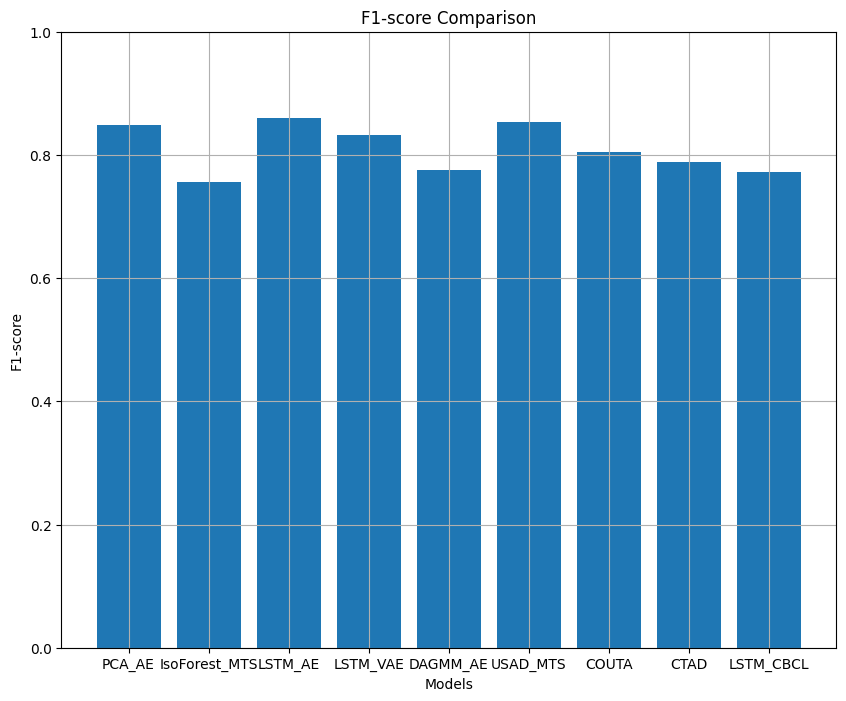

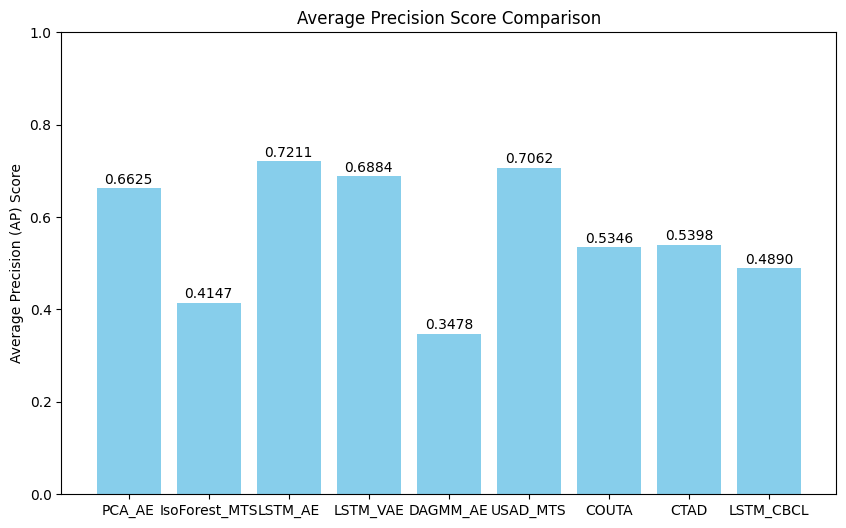

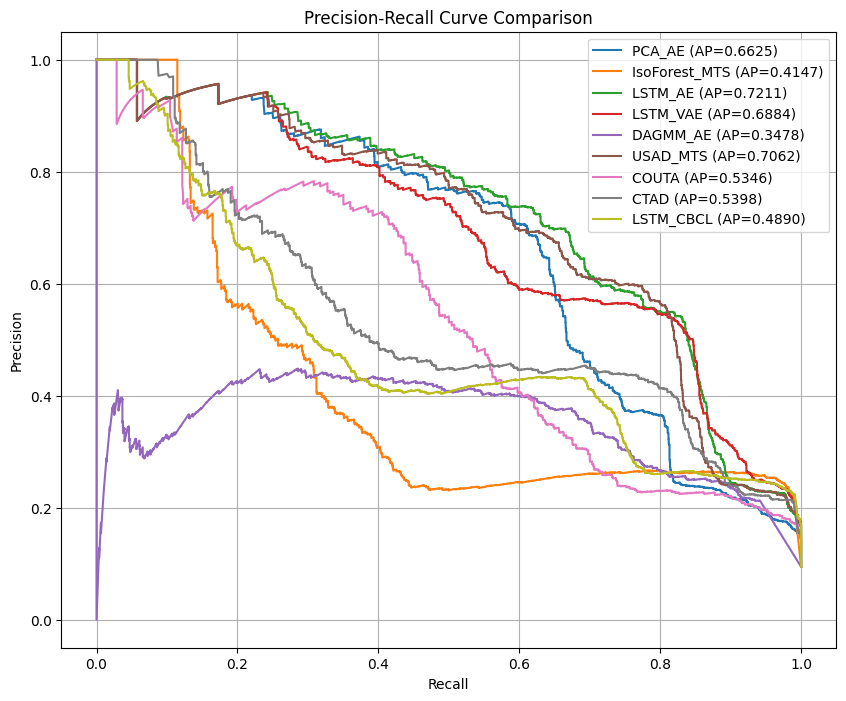

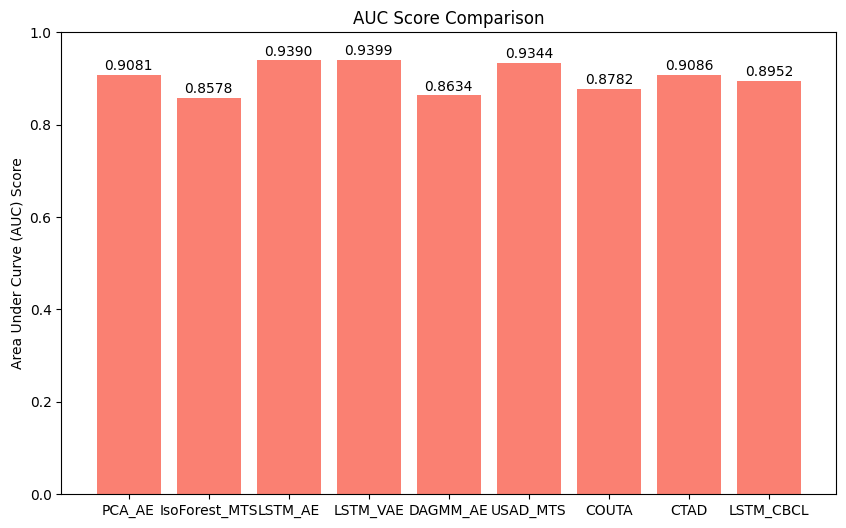

	 Server 1 - Machine 5
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.588115 | Val Loss: 0.783170
Epoch 2
	 Train Loss: 0.475248 | Val Loss: 0.740712
Epoch 3
	 Train Loss: 0.447898 | Val Loss: 0.711881
Epoch 4
	 Train Loss: 0.431106 | Val Loss: 0.689240
Epoch 5
	 Train Loss: 0.421114 | Val Loss: 0.674904
Epoch 6
	 Train Loss: 0.414207 | Val Loss: 0.663274
Epoch 7
	 Train Loss: 0.409482 | Val Loss: 0.653851
Epoch 8
	 Train Loss: 0.404096 | Val Loss: 0.646617
Epoch 9
	 Train Loss: 0.399979 | Val Loss: 0.640526
Epoch 10
	 Train Loss: 0.396733 | Val Loss: 0.634818
Epoch 11
	 Train Loss: 0.394030 | Val Loss: 0.629408
Epoch 12
	 Train Loss: 0.391345 | Val Loss: 0.626415
Epoch 13
	 Train Loss: 0.389613 | Val Loss: 0.623646
Epoch 14
	 Train Loss: 0.388284 | Val Loss: 0.622115
Epoch 15
	 Train Loss: 0.386639 | Val Loss: 0.620322
Epoch 16
	 Train Loss: 0.385674 | Val Loss: 0.618474
Epoch 17
	 Train Loss: 0.384597 | Val Loss: 0.617396
Epoch 18
	 Train Los

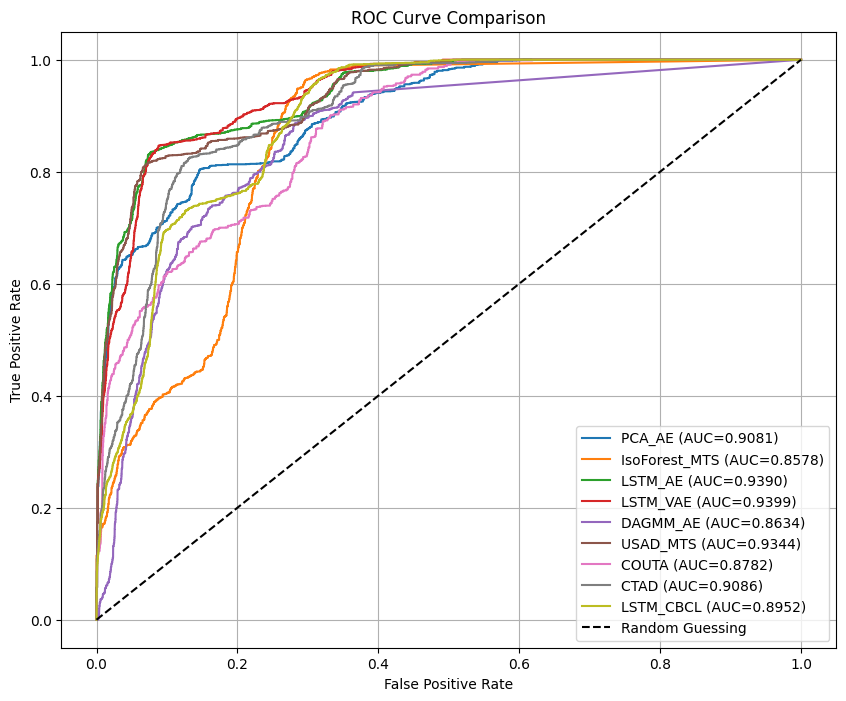

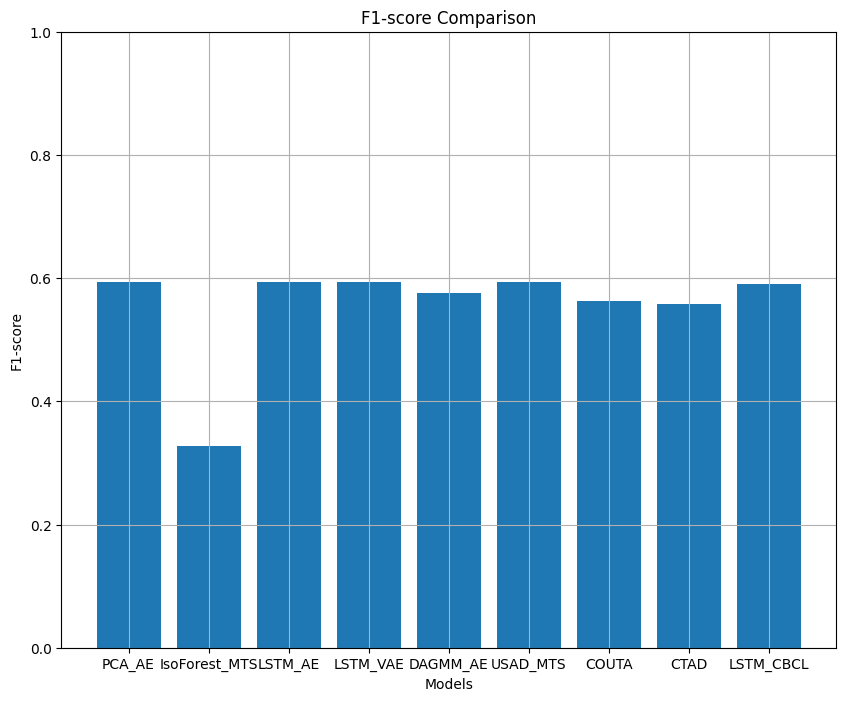

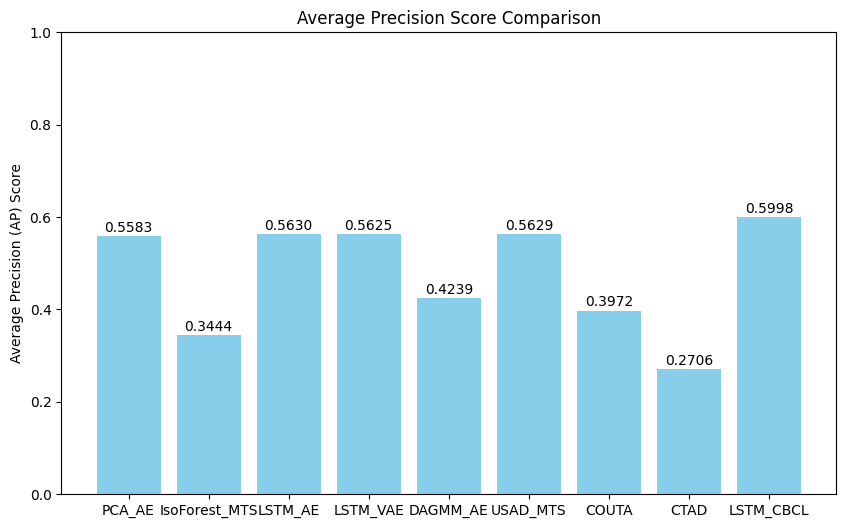

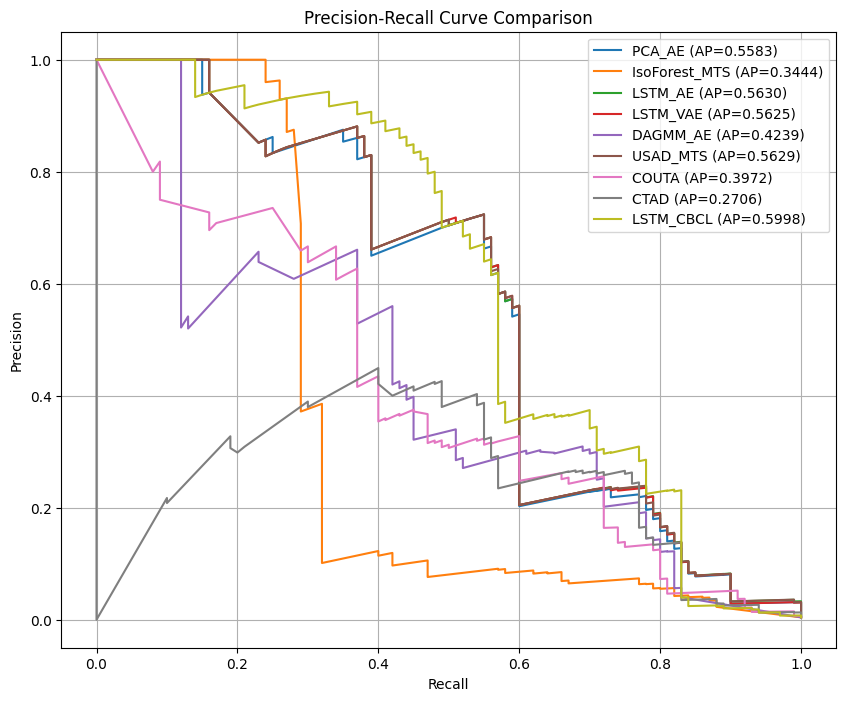

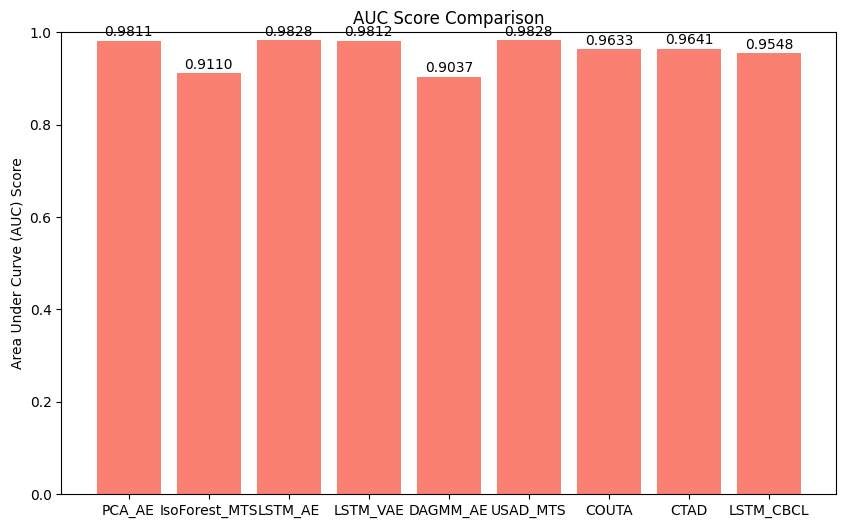

	 Server 2 - Machine 3
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.822066 | Val Loss: 0.259836
Epoch 2
	 Train Loss: 0.724467 | Val Loss: 0.220840
Epoch 3
	 Train Loss: 0.673134 | Val Loss: 0.185565
Epoch 4
	 Train Loss: 0.635280 | Val Loss: 0.169697
Epoch 5
	 Train Loss: 0.606305 | Val Loss: 0.161927
Epoch 6
	 Train Loss: 0.582768 | Val Loss: 0.156335
Epoch 7
	 Train Loss: 0.563297 | Val Loss: 0.152964
Epoch 8
	 Train Loss: 0.547689 | Val Loss: 0.149452
Epoch 9
	 Train Loss: 0.537175 | Val Loss: 0.147331
Epoch 10
	 Train Loss: 0.523664 | Val Loss: 0.144433
Epoch 11
	 Train Loss: 0.513670 | Val Loss: 0.142526
Epoch 12
	 Train Loss: 0.502982 | Val Loss: 0.140555
Epoch 13
	 Train Loss: 0.493547 | Val Loss: 0.138614
Epoch 14
	 Train Loss: 0.485122 | Val Loss: 0.138008
Epoch 15
	 Train Loss: 0.481263 | Val Loss: 0.136300
Epoch 16
	 Train Loss: 0.472184 | Val Loss: 0.135852
Epoch 17
	 Train Loss: 0.467419 | Val Loss: 0.134356
Epoch 18
	 Train Los

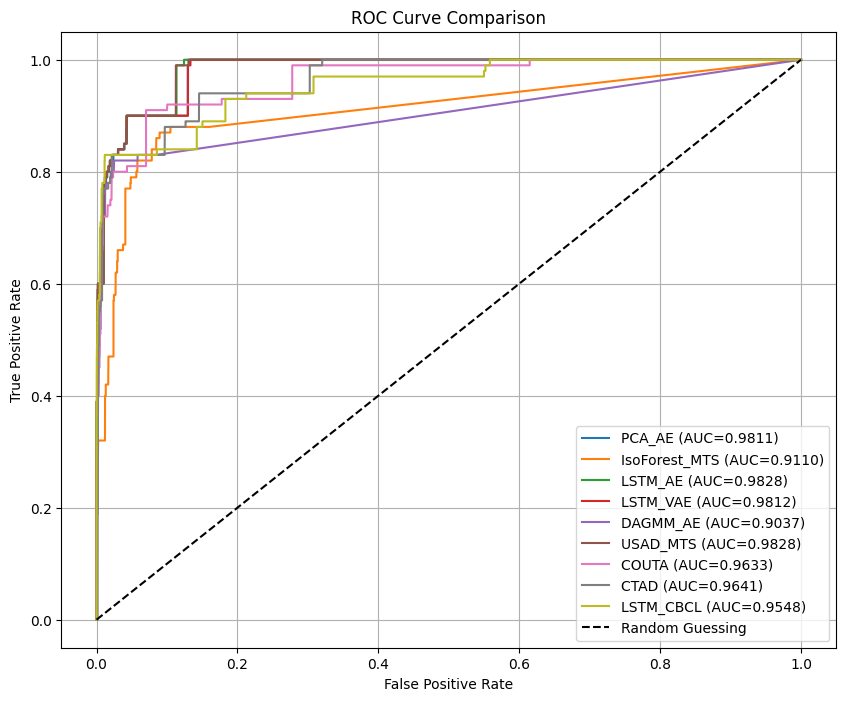

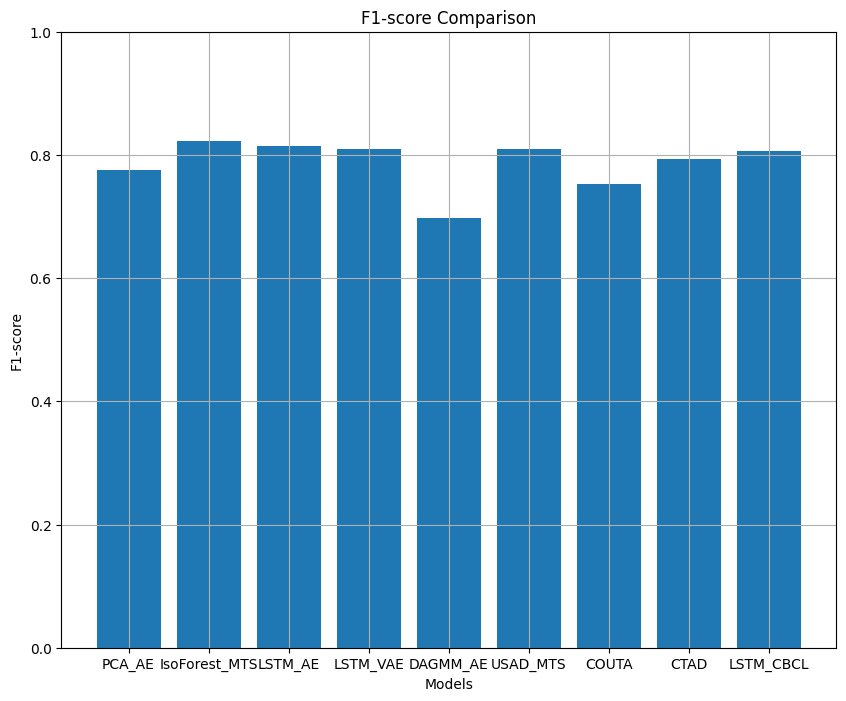

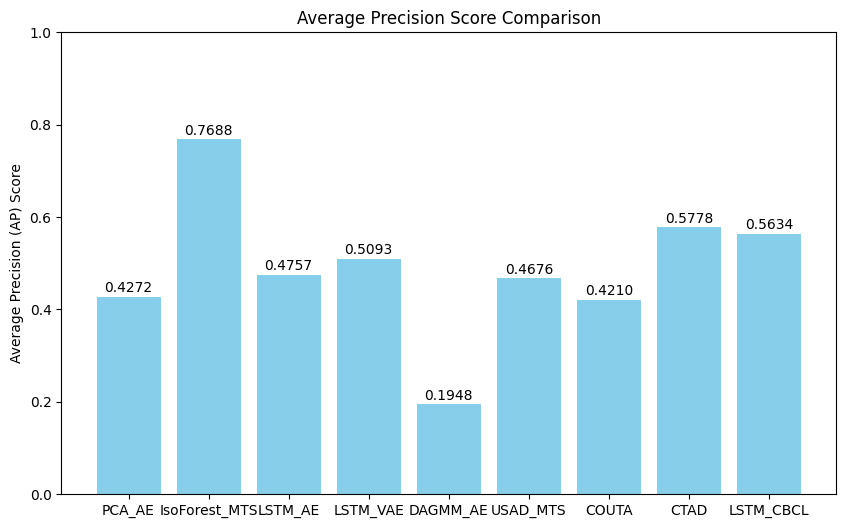

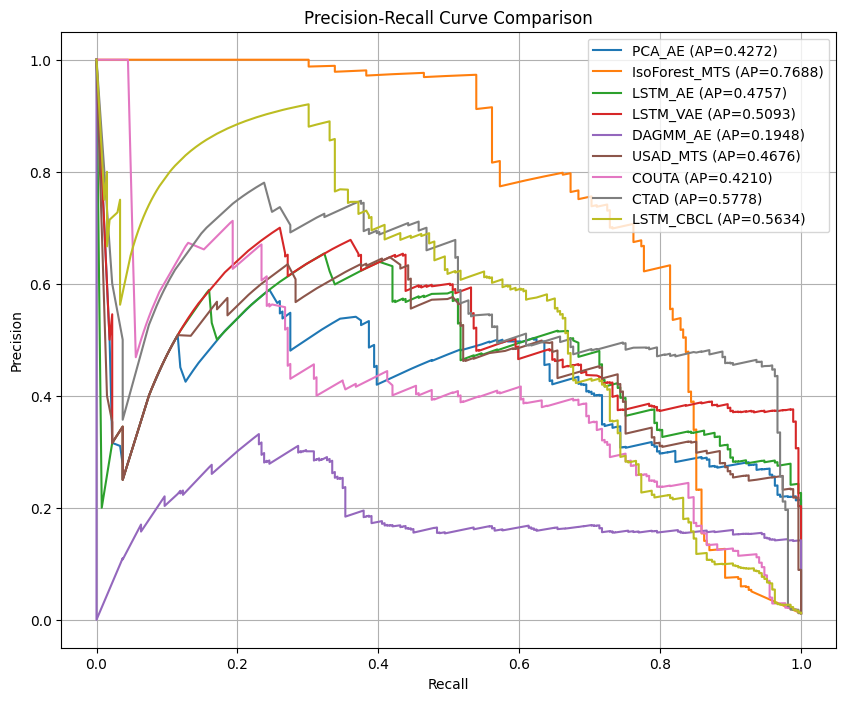

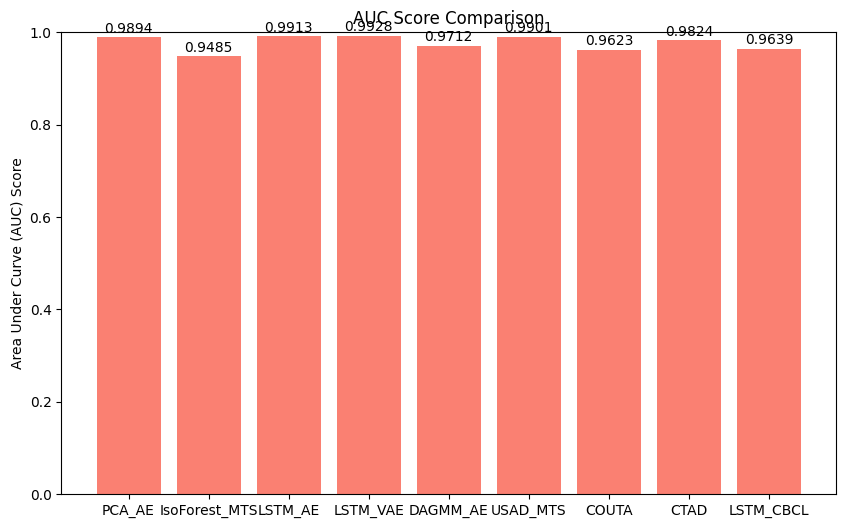

	 Server 2 - Machine 4
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.623496 | Val Loss: 0.439131
Epoch 2
	 Train Loss: 0.489898 | Val Loss: 0.405574
Epoch 3
	 Train Loss: 0.449251 | Val Loss: 0.386647
Epoch 4
	 Train Loss: 0.428012 | Val Loss: 0.374144
Epoch 5
	 Train Loss: 0.414987 | Val Loss: 0.367187
Epoch 6
	 Train Loss: 0.405708 | Val Loss: 0.360822
Epoch 7
	 Train Loss: 0.398476 | Val Loss: 0.353167
Epoch 8
	 Train Loss: 0.391986 | Val Loss: 0.343226
Epoch 9
	 Train Loss: 0.385359 | Val Loss: 0.331951
Epoch 10
	 Train Loss: 0.378885 | Val Loss: 0.321759
Epoch 11
	 Train Loss: 0.373124 | Val Loss: 0.313650
Epoch 12
	 Train Loss: 0.366886 | Val Loss: 0.305255
Epoch 13
	 Train Loss: 0.360069 | Val Loss: 0.295958
Epoch 14
	 Train Loss: 0.353410 | Val Loss: 0.290087
Epoch 15
	 Train Loss: 0.347357 | Val Loss: 0.285953
Epoch 16
	 Train Loss: 0.342965 | Val Loss: 0.283856
Epoch 17
	 Train Loss: 0.338134 | Val Loss: 0.280099
Epoch 18
	 Train Los

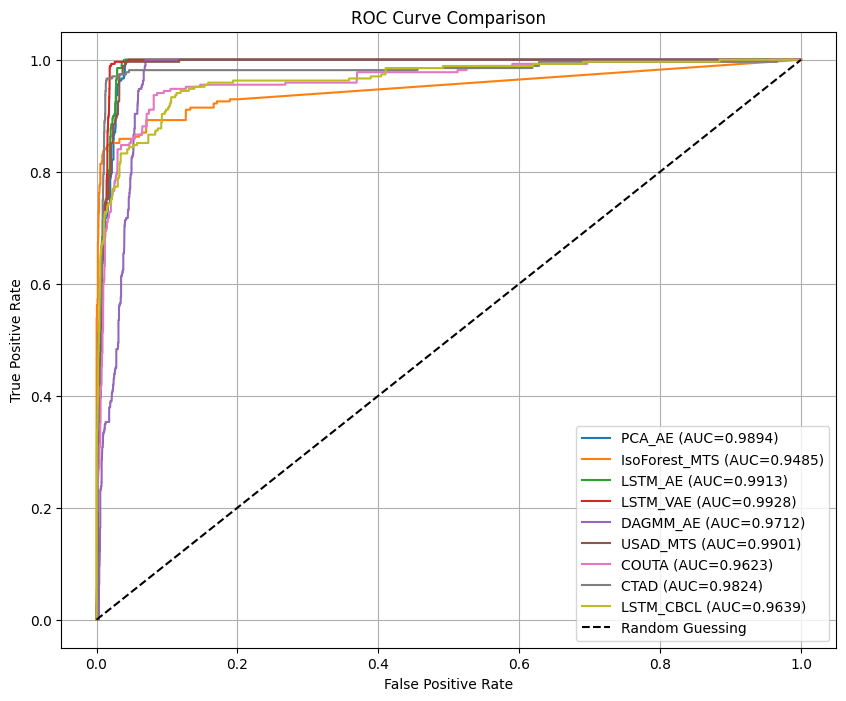

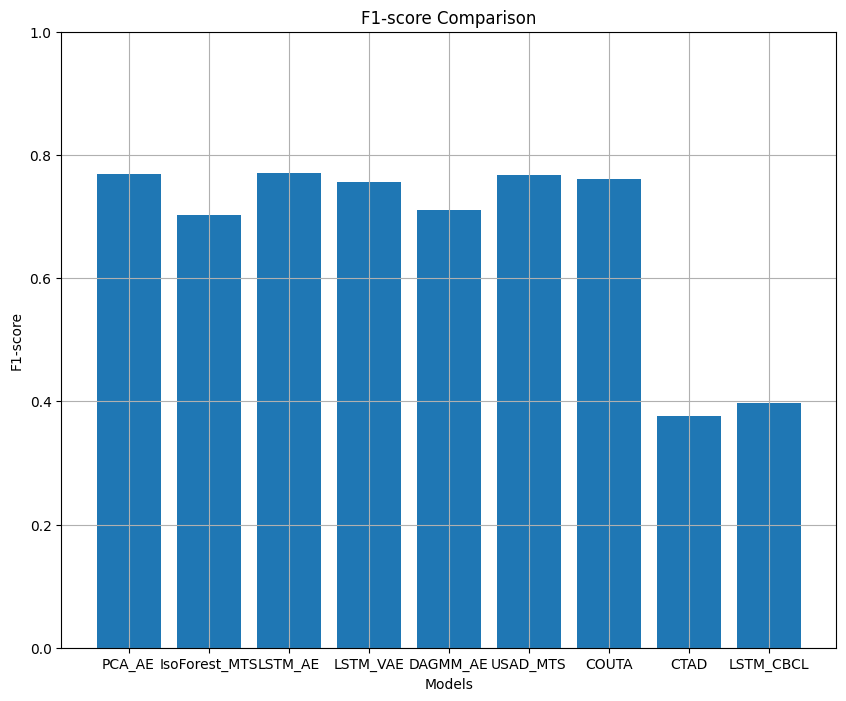

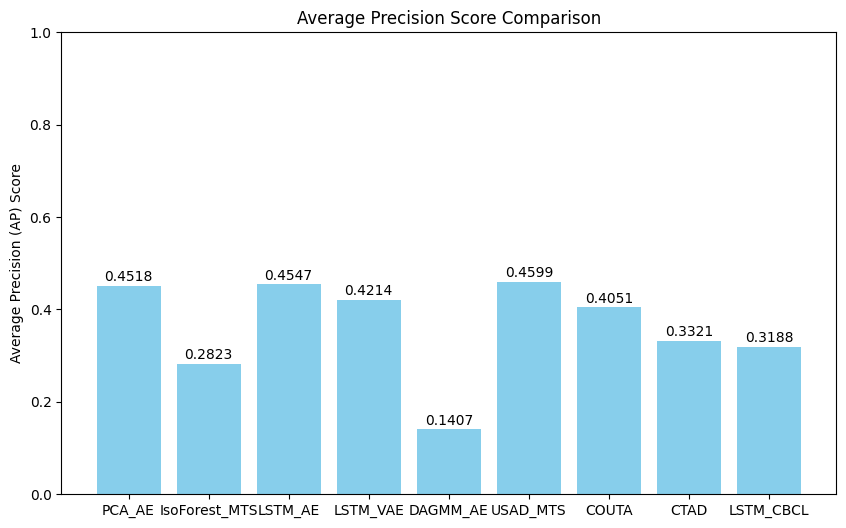

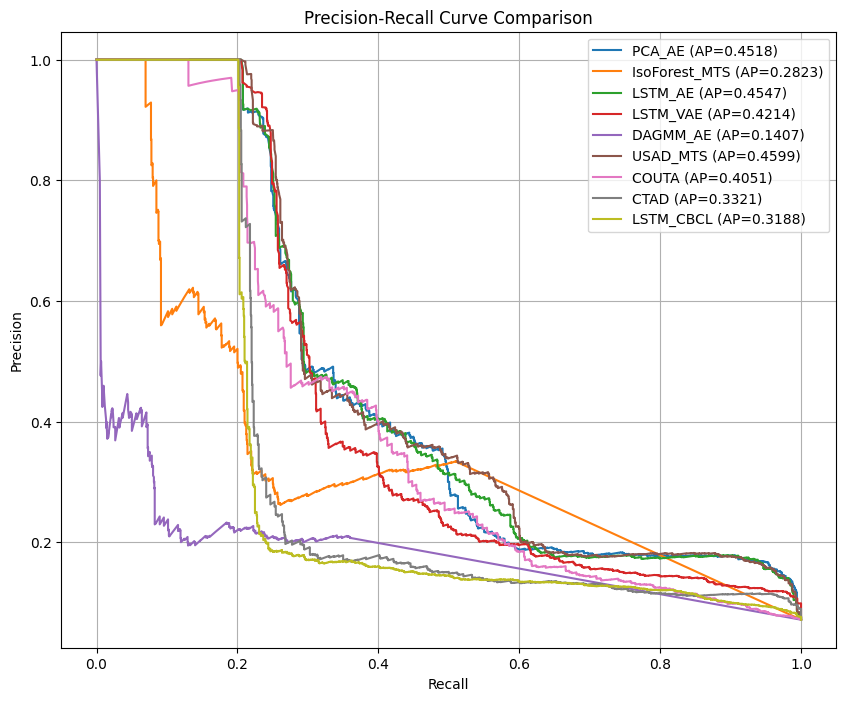

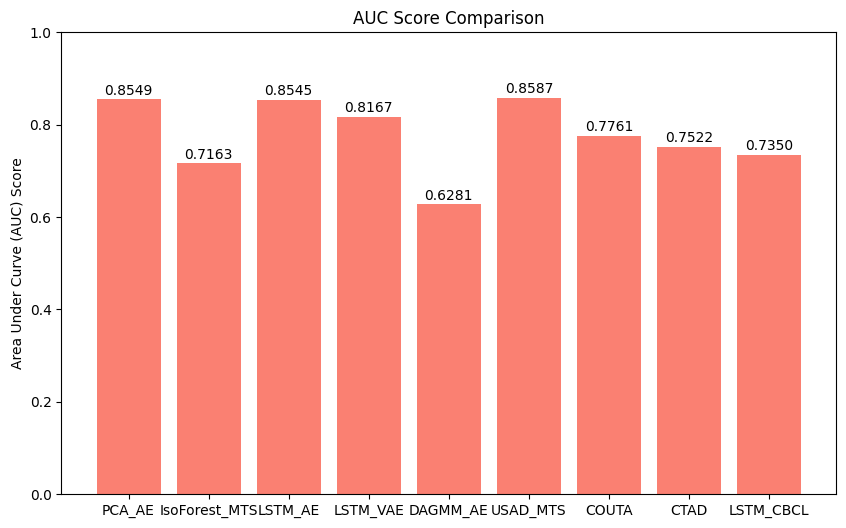

	 Server 3 - Machine 2
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.692113 | Val Loss: 0.996114
Epoch 2
	 Train Loss: 0.630762 | Val Loss: 0.947742
Epoch 3
	 Train Loss: 0.568421 | Val Loss: 0.904138
Epoch 4
	 Train Loss: 0.539752 | Val Loss: 0.882843
Epoch 5
	 Train Loss: 0.523289 | Val Loss: 0.863826
Epoch 6
	 Train Loss: 0.511538 | Val Loss: 0.854924
Epoch 7
	 Train Loss: 0.502346 | Val Loss: 0.846651
Epoch 8
	 Train Loss: 0.492477 | Val Loss: 0.837381
Epoch 9
	 Train Loss: 0.483983 | Val Loss: 0.828718
Epoch 10
	 Train Loss: 0.477706 | Val Loss: 0.819688
Epoch 11
	 Train Loss: 0.469237 | Val Loss: 0.815594
Epoch 12
	 Train Loss: 0.461357 | Val Loss: 0.810938
Epoch 13
	 Train Loss: 0.456458 | Val Loss: 0.805940
Epoch 14
	 Train Loss: 0.452992 | Val Loss: 0.796654
Epoch 15
	 Train Loss: 0.444978 | Val Loss: 0.793411
Epoch 16
	 Train Loss: 0.441633 | Val Loss: 0.789358
Epoch 17
	 Train Loss: 0.436375 | Val Loss: 0.789890
Epoch 18
	 Train Los

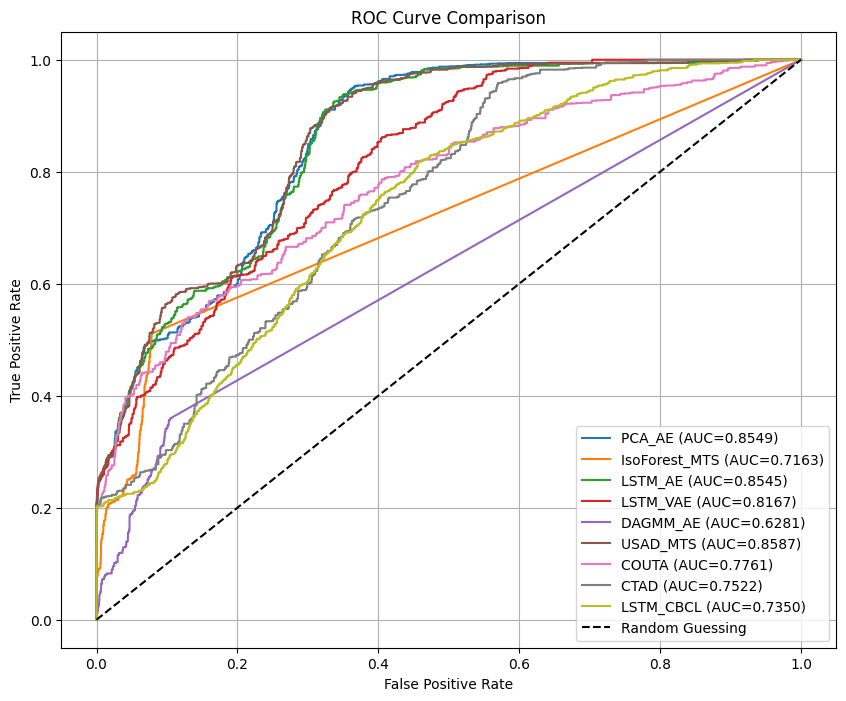

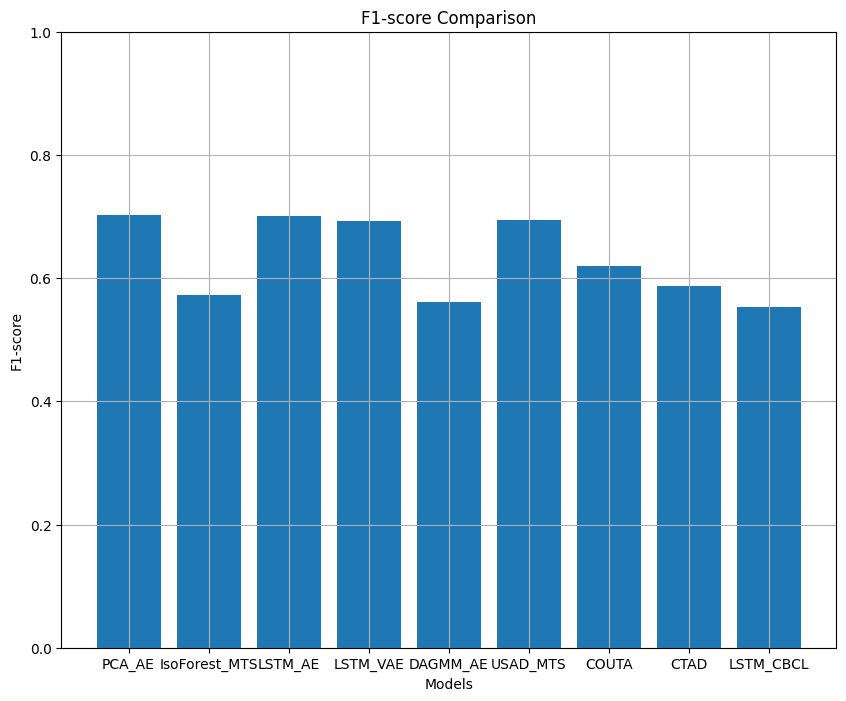

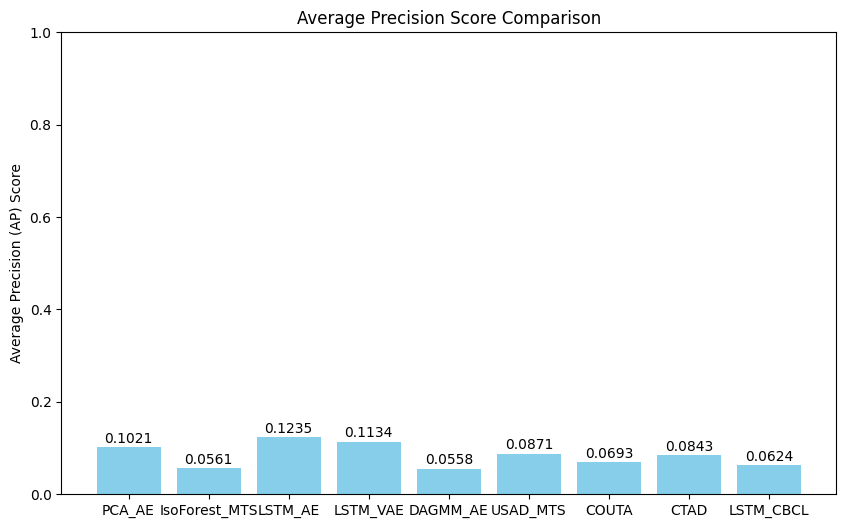

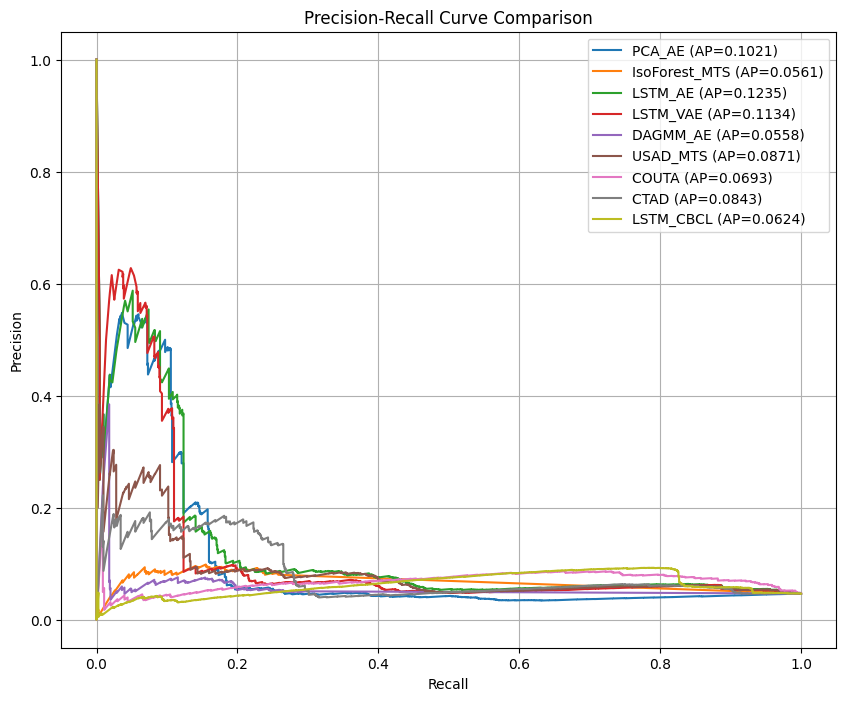

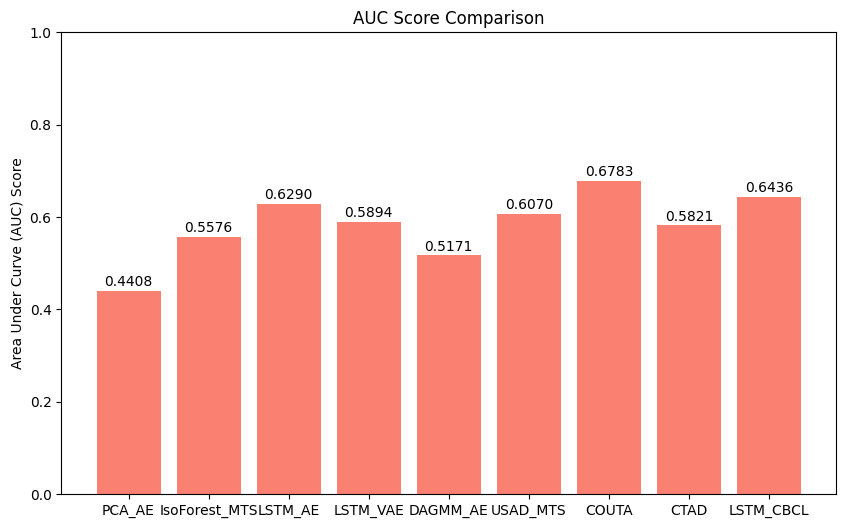

	 Server 3 - Machine 10
		Training: PCA_AE
		Training: IsoForest_MTS
		Training: LSTM_AE
Epoch 1
	 Train Loss: 0.727852 | Val Loss: 0.274976
Epoch 2
	 Train Loss: 0.579778 | Val Loss: 0.236323
Epoch 3
	 Train Loss: 0.513652 | Val Loss: 0.225606
Epoch 4
	 Train Loss: 0.460916 | Val Loss: 0.208577
Epoch 5
	 Train Loss: 0.425520 | Val Loss: 0.189693
Epoch 6
	 Train Loss: 0.398688 | Val Loss: 0.175307
Epoch 7
	 Train Loss: 0.376598 | Val Loss: 0.164483
Epoch 8
	 Train Loss: 0.358328 | Val Loss: 0.155957
Epoch 9
	 Train Loss: 0.345061 | Val Loss: 0.148825
Epoch 10
	 Train Loss: 0.336060 | Val Loss: 0.142614
Epoch 11
	 Train Loss: 0.328679 | Val Loss: 0.138335
Epoch 12
	 Train Loss: 0.321574 | Val Loss: 0.137309
Epoch 13
	 Train Loss: 0.315939 | Val Loss: 0.133452
Epoch 14
	 Train Loss: 0.309293 | Val Loss: 0.128727
Epoch 15
	 Train Loss: 0.303987 | Val Loss: 0.129154
Epoch 16
	 Train Loss: 0.297358 | Val Loss: 0.124661
Epoch 17
	 Train Loss: 0.292017 | Val Loss: 0.124019
Epoch 18
	 Train Lo

In [ ]:
tf.keras.backend.clear_session() 
""" run_results(use_timestamp_level=False, use_point_adjust=False, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Window_score', dirs_exist_ok=True)
tf.keras.backend.clear_session()

run_results(use_timestamp_level=True, use_point_adjust=False, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Timestamp Score', dirs_exist_ok=True)
tf.keras.backend.clear_session() """

run_results(use_timestamp_level=True, use_point_adjust=True, verbose=1)
shutil.copytree('Model Comparisons', 'Model Comparisons - Point Adjusted', dirs_exist_ok=True)

Testing models on SMD dataset:
	 Server 1 - Machine 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.129038 - val_loss: 0.138116
	 Breakdown: 
	 MSE: 0.061838, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.092641 - val_loss: 0.083006
	 Breakdown: 
	 MSE: 0.024981, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.068557 - val_loss: 0.069848
	 Breakdown: 
	 MSE: 0.020278, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.058450 - val_loss: 0.059339
	 Breakdown: 
	 MSE: 0.016818, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.050257 - val_loss: 0.050723
	 Breakdown: 
	 MSE: 0.013939, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.043623 - val_loss: 0.043799
	 Breakdown: 
	 MSE: 0.012716, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.038350 - val_loss: 0.03838

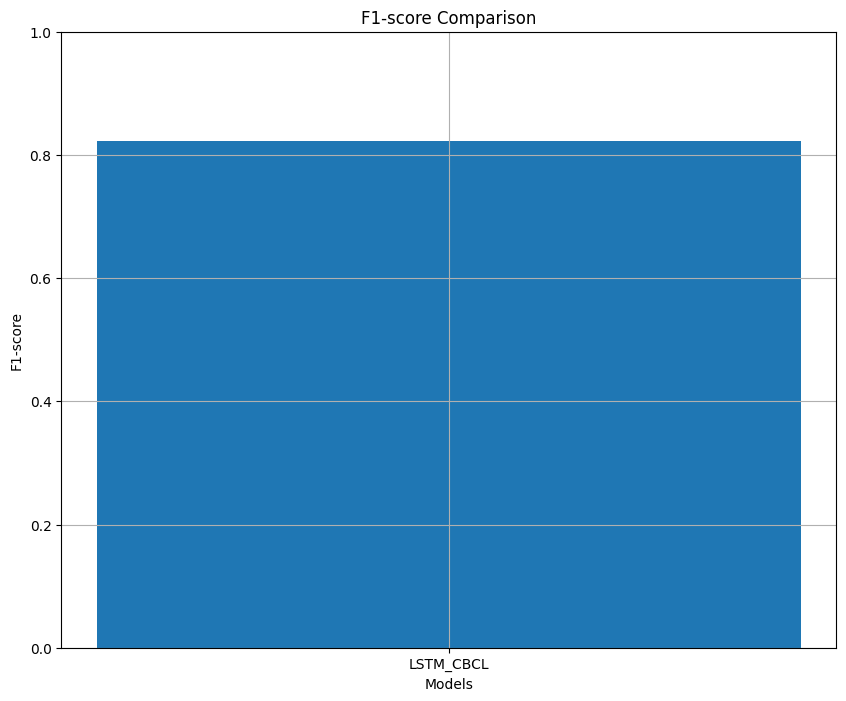

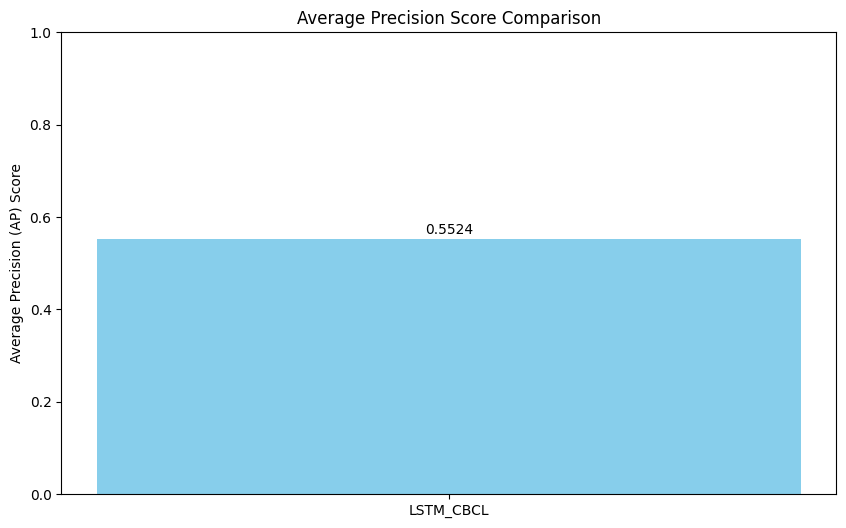

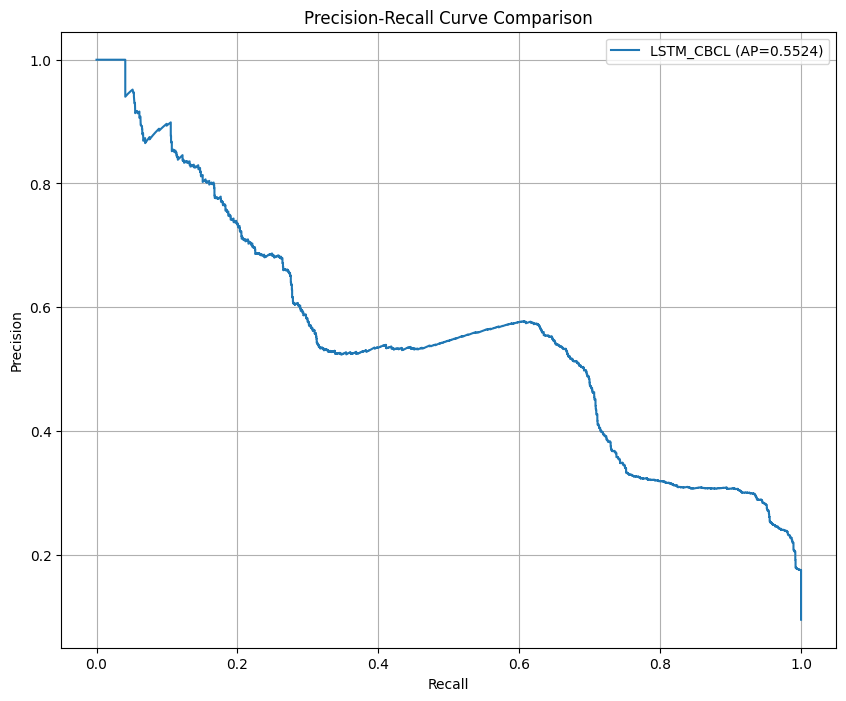

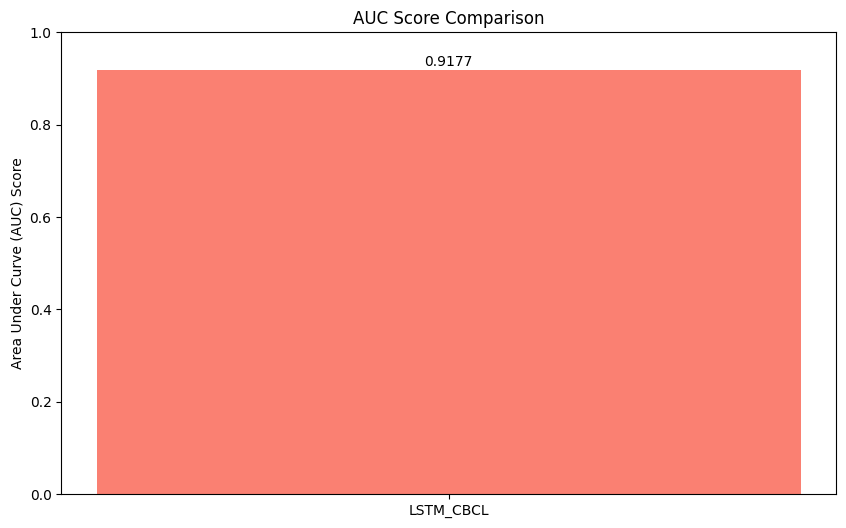

	 Server 1 - Machine 5
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.100604 - val_loss: 0.098654
	 Breakdown: 
	 MSE: 0.032014, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.084005 - val_loss: 0.076853
	 Breakdown: 
	 MSE: 0.019243, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.065528 - val_loss: 0.062761
	 Breakdown: 
	 MSE: 0.012831, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.056515 - val_loss: 0.055317
	 Breakdown: 
	 MSE: 0.012330, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.049910 - val_loss: 0.049074
	 Breakdown: 
	 MSE: 0.010555, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.044297 - val_loss: 0.043757
	 Breakdown: 
	 MSE: 0.009688, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.039502 - val_loss: 0.039239
	 Breakdown: 
	 MSE: 0.009619

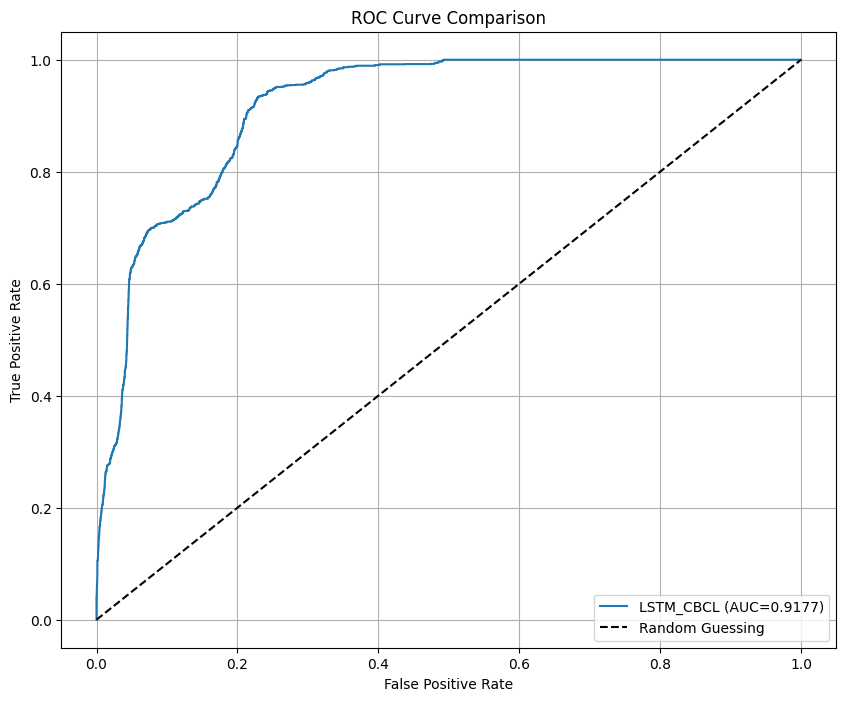

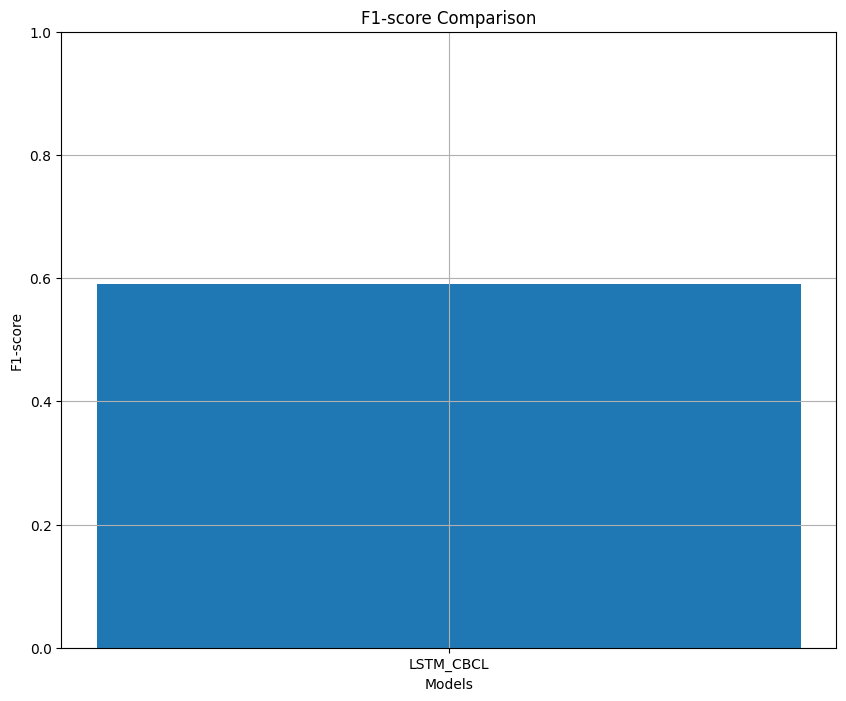

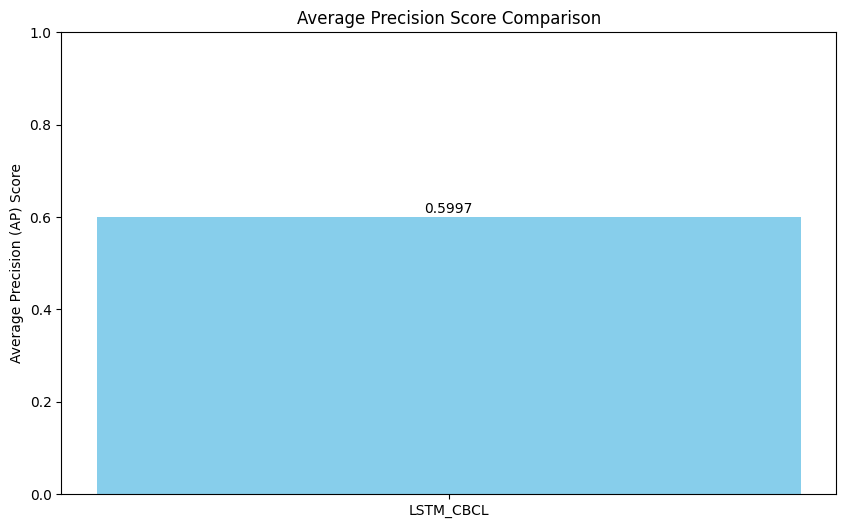

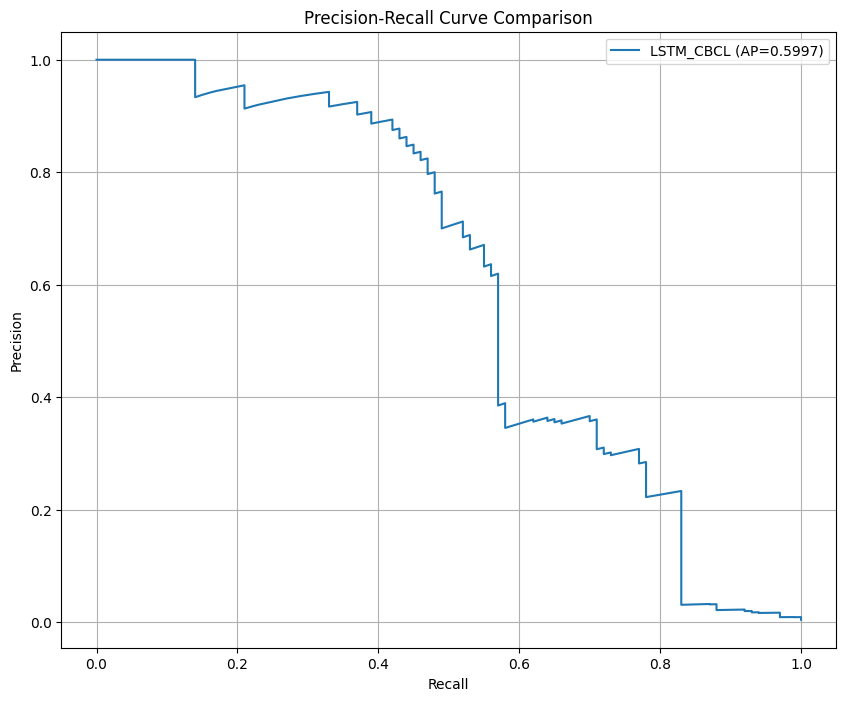

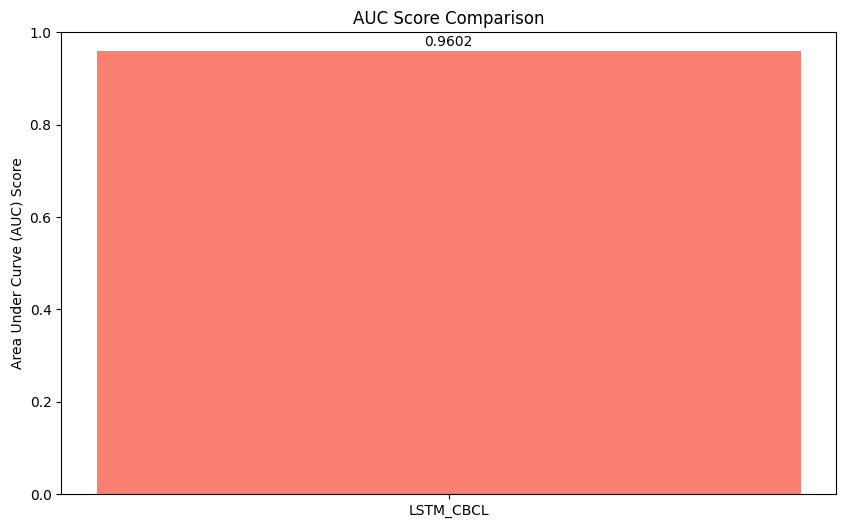

	 Server 2 - Machine 3
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.110231 - val_loss: 0.102947
	 Breakdown: 
	 MSE: 0.042394, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.093282 - val_loss: 0.082519
	 Breakdown: 
	 MSE: 0.029650, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.070320 - val_loss: 0.061287
	 Breakdown: 
	 MSE: 0.013311, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.056362 - val_loss: 0.051770
	 Breakdown: 
	 MSE: 0.010669, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.048713 - val_loss: 0.044804
	 Breakdown: 
	 MSE: 0.008514, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.042196 - val_loss: 0.038740
	 Breakdown: 
	 MSE: 0.006853, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.036652 - val_loss: 0.033590
	 Breakdown: 
	 MSE: 0.005384

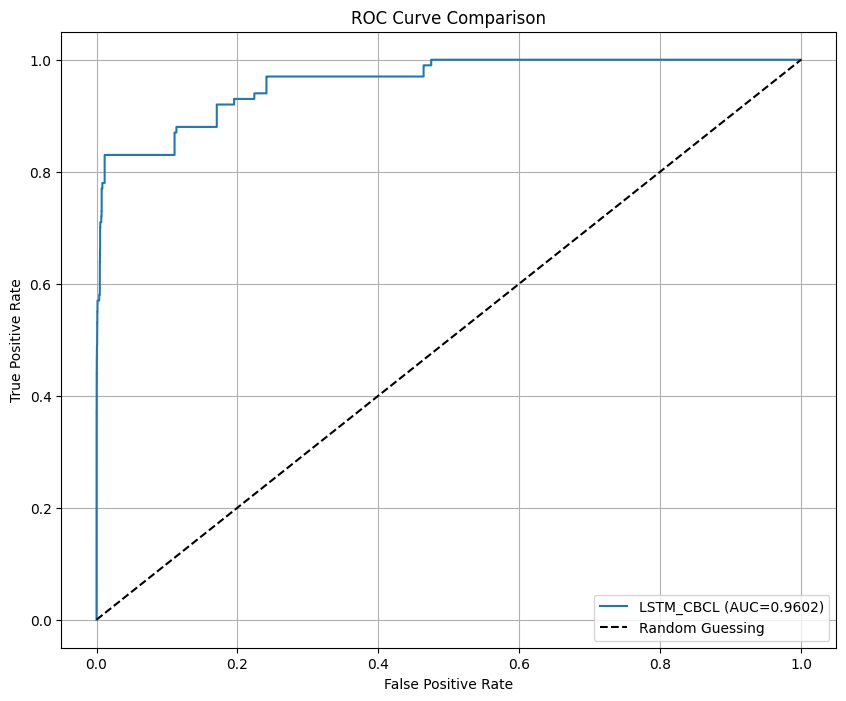

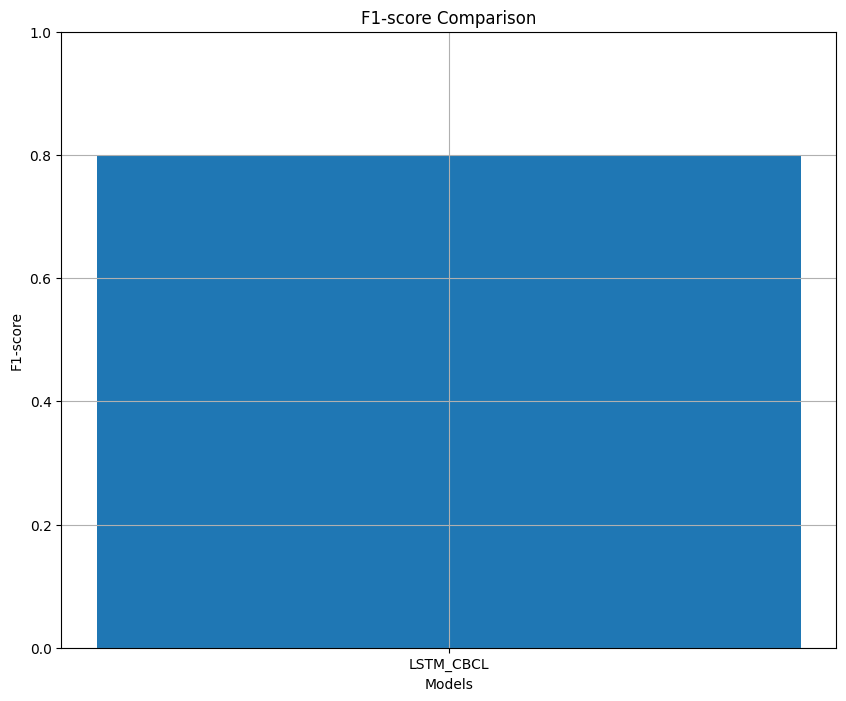

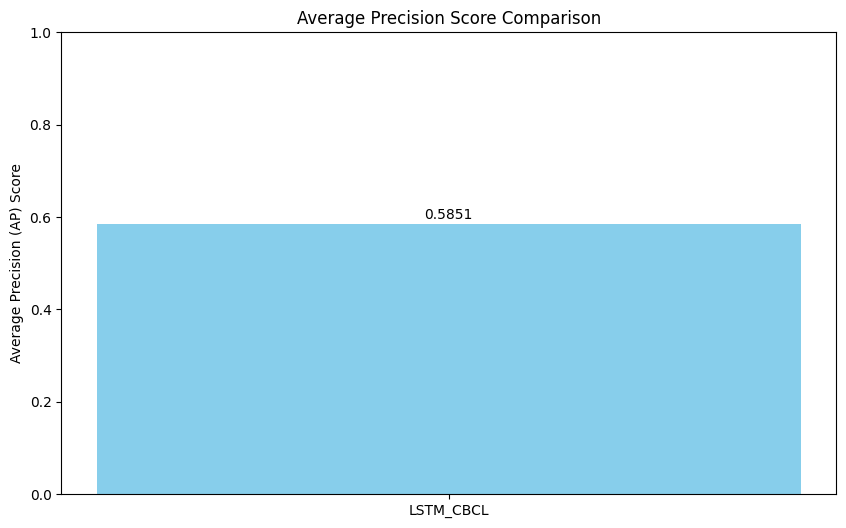

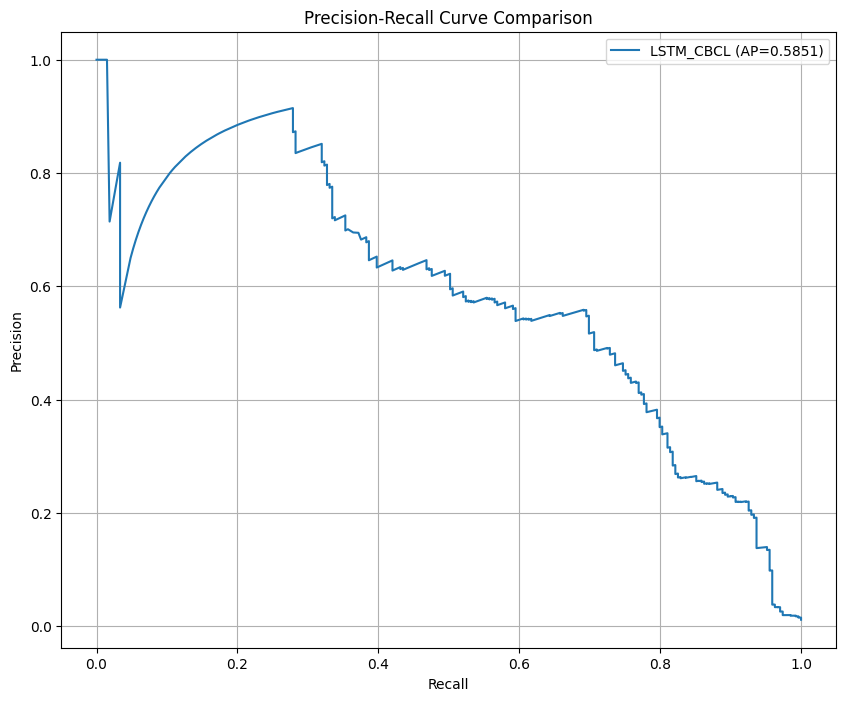

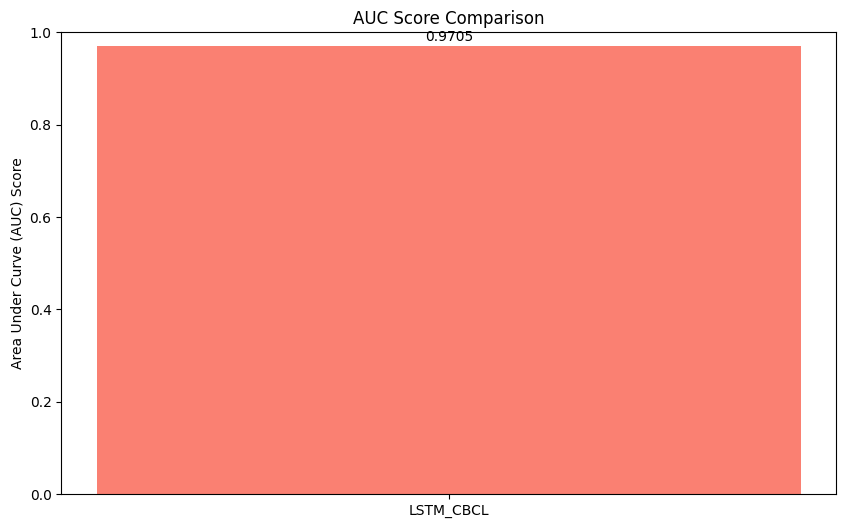

	 Server 2 - Machine 4
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.138694 - val_loss: 0.136858
	 Breakdown: 
	 MSE: 0.064648, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.113040 - val_loss: 0.098264
	 Breakdown: 
	 MSE: 0.039321, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.079036 - val_loss: 0.073387
	 Breakdown: 
	 MSE: 0.022142, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.066538 - val_loss: 0.064065
	 Breakdown: 
	 MSE: 0.019678, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.058170 - val_loss: 0.055901
	 Breakdown: 
	 MSE: 0.015833, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.051077 - val_loss: 0.048971
	 Breakdown: 
	 MSE: 0.014015, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.045115 - val_loss: 0.043185
	 Breakdown: 
	 MSE: 0.011708

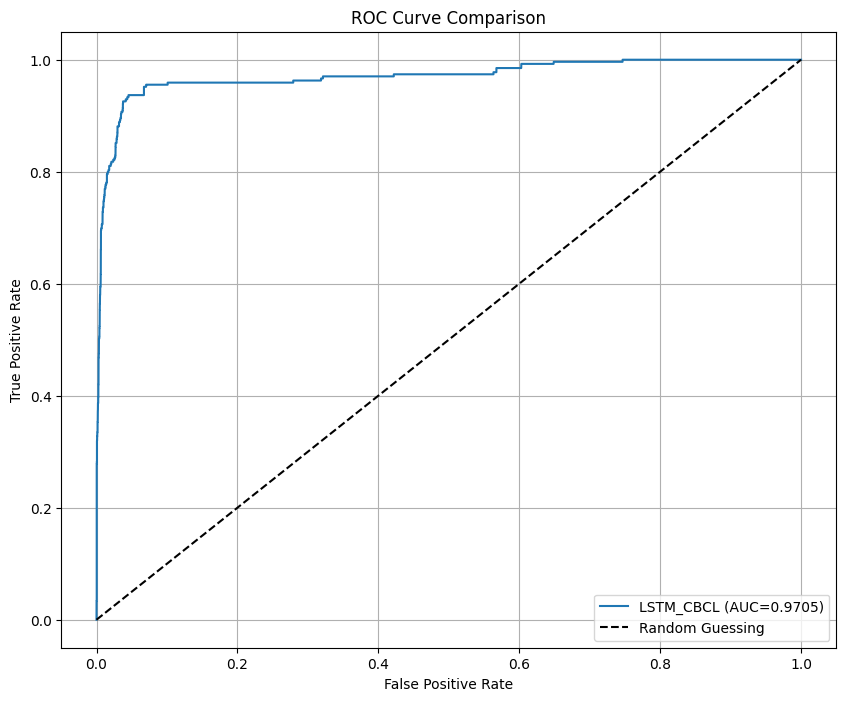

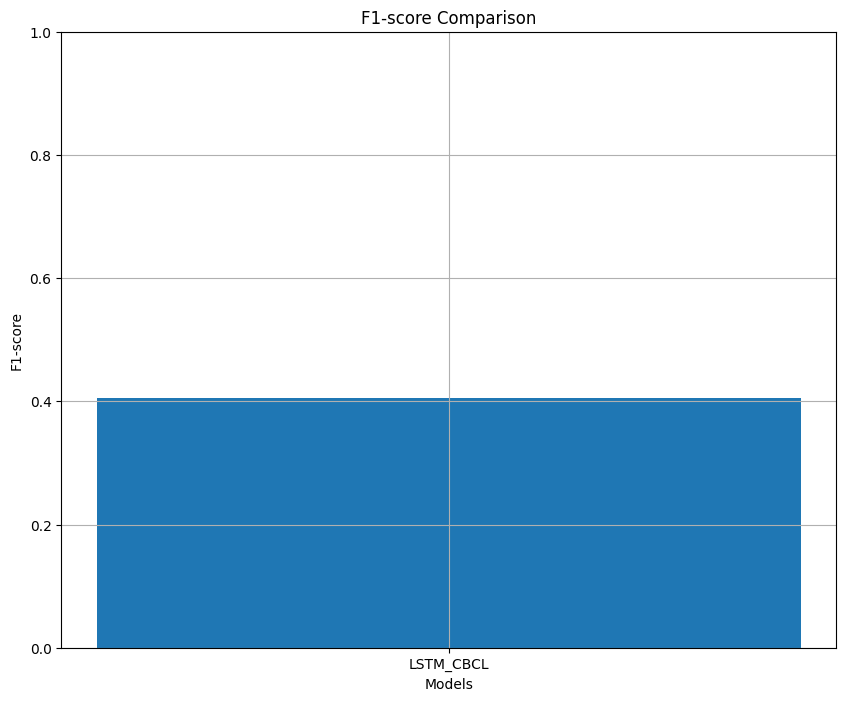

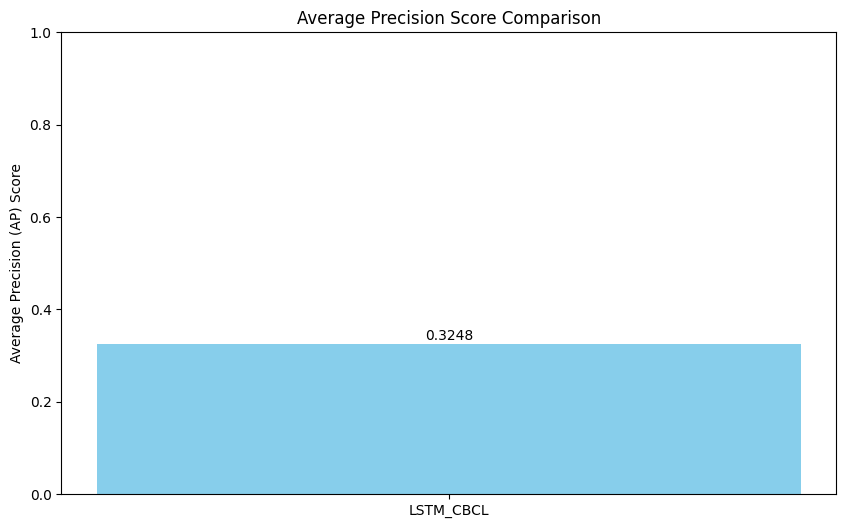

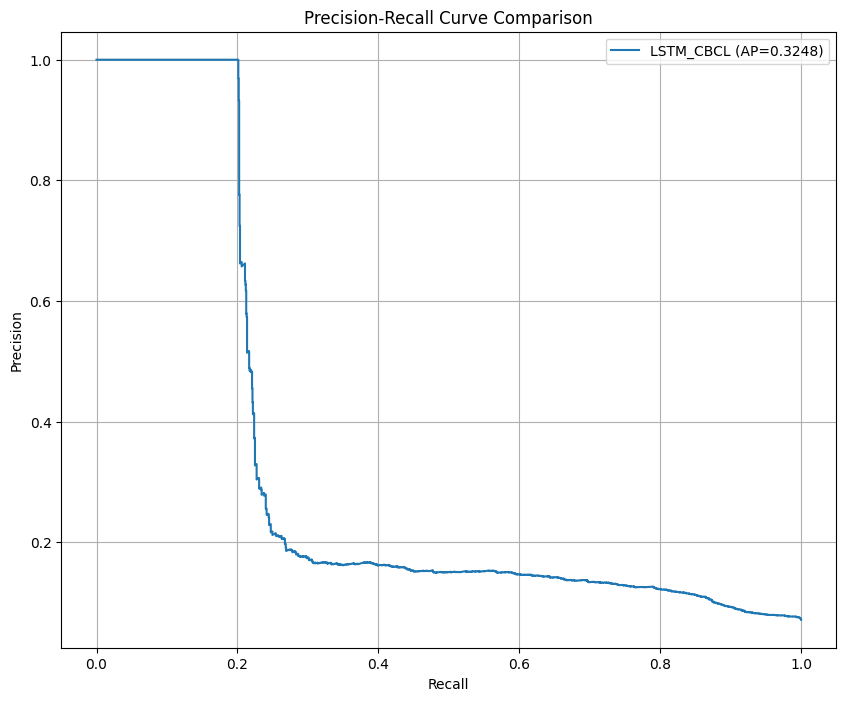

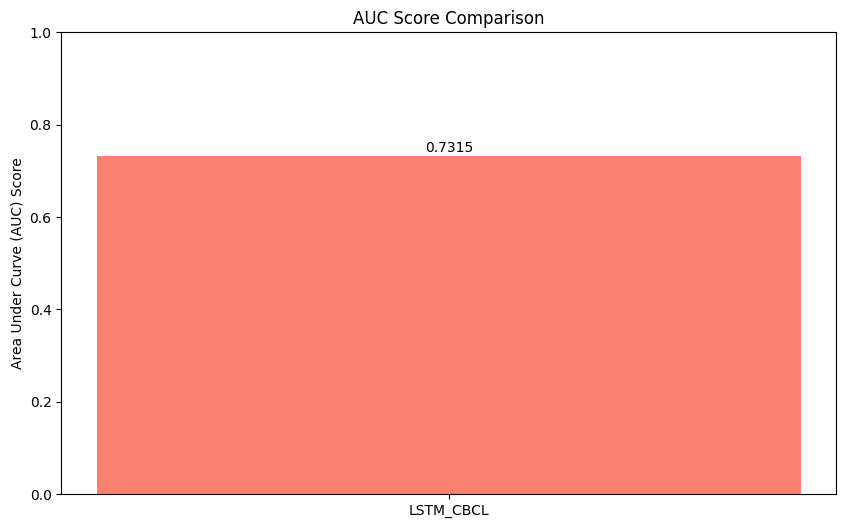

	 Server 3 - Machine 2
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.160221 - val_loss: 0.130617
	 Breakdown: 
	 MSE: 0.091233, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.128329 - val_loss: 0.090816
	 Breakdown: 
	 MSE: 0.050553, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.084501 - val_loss: 0.069613
	 Breakdown: 
	 MSE: 0.026704, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.069986 - val_loss: 0.060672
	 Breakdown: 
	 MSE: 0.021854, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.060937 - val_loss: 0.053110
	 Breakdown: 
	 MSE: 0.019081, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.053280 - val_loss: 0.046764
	 Breakdown: 
	 MSE: 0.015233, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.046897 - val_loss: 0.041474
	 Breakdown: 
	 MSE: 0.012163

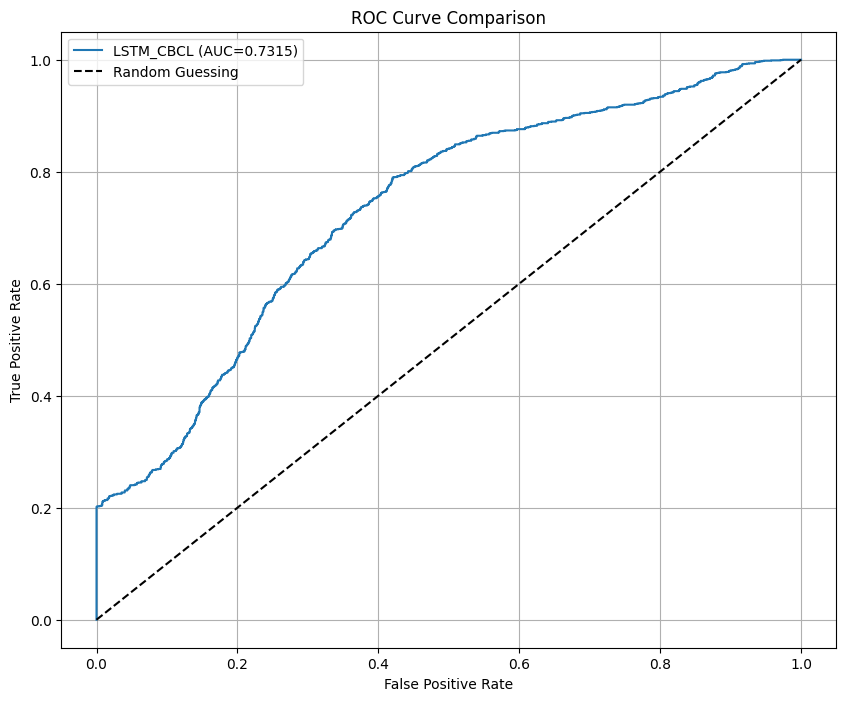

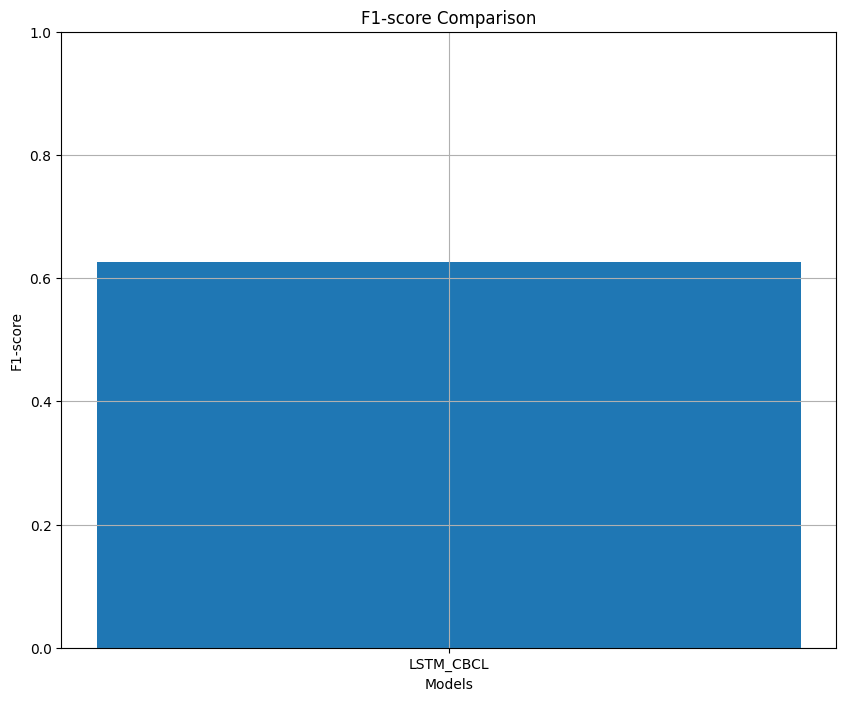

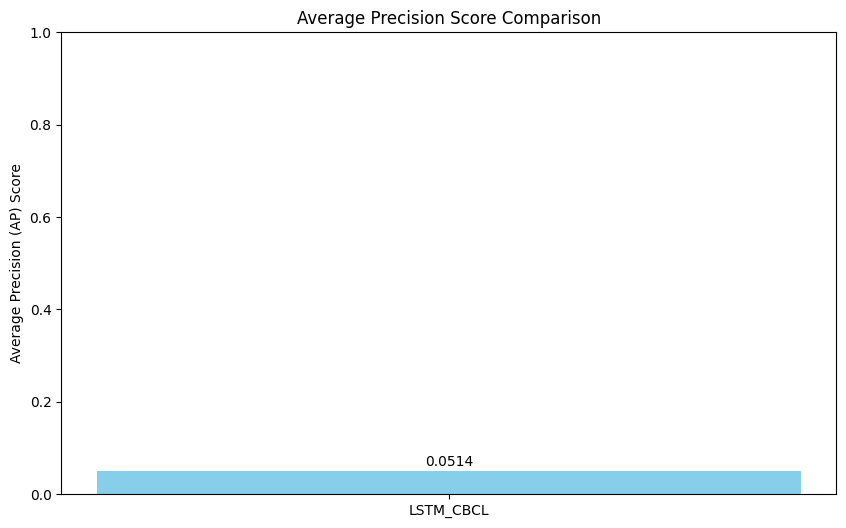

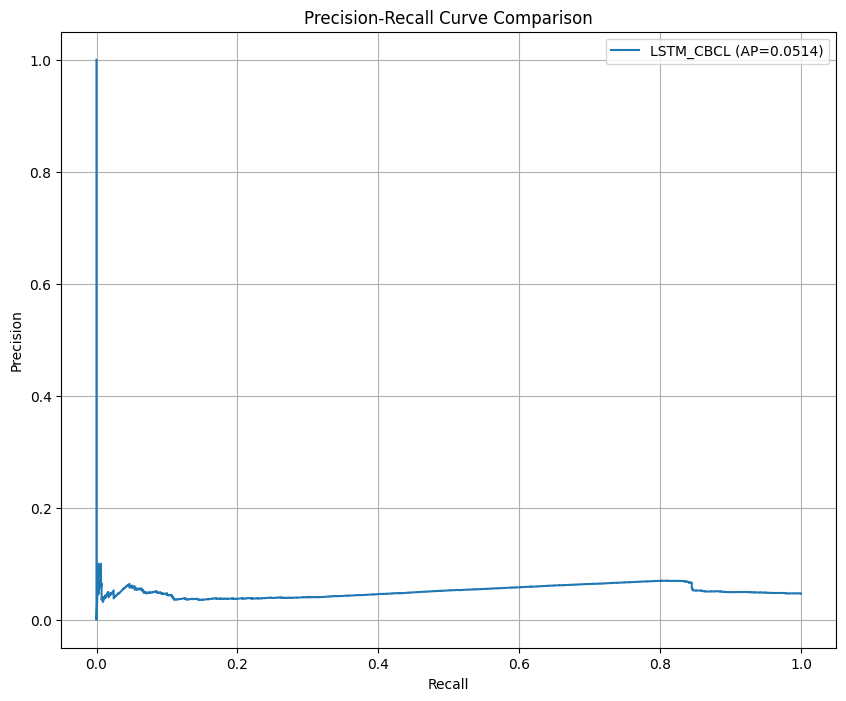

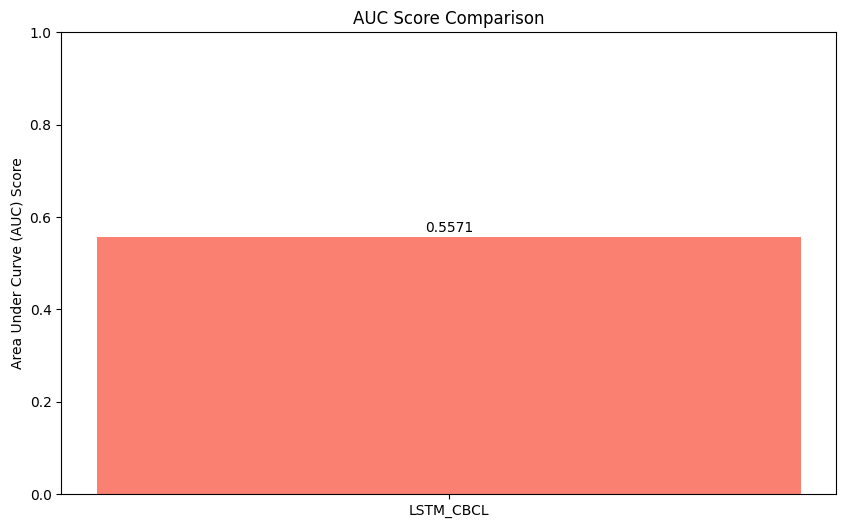

	 Server 3 - Machine 10
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.142372 - val_loss: 0.122041
	 Breakdown: 
	 MSE: 0.072845, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.118224 - val_loss: 0.091195
	 Breakdown: 
	 MSE: 0.047893, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.082603 - val_loss: 0.072040
	 Breakdown: 
	 MSE: 0.024288, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.067401 - val_loss: 0.064422
	 Breakdown: 
	 MSE: 0.019736, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.058542 - val_loss: 0.057309
	 Breakdown: 
	 MSE: 0.015753, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.051123 - val_loss: 0.051338
	 Breakdown: 
	 MSE: 0.012631, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.045092 - val_loss: 0.046368
	 Breakdown: 
	 MSE: 0.01078

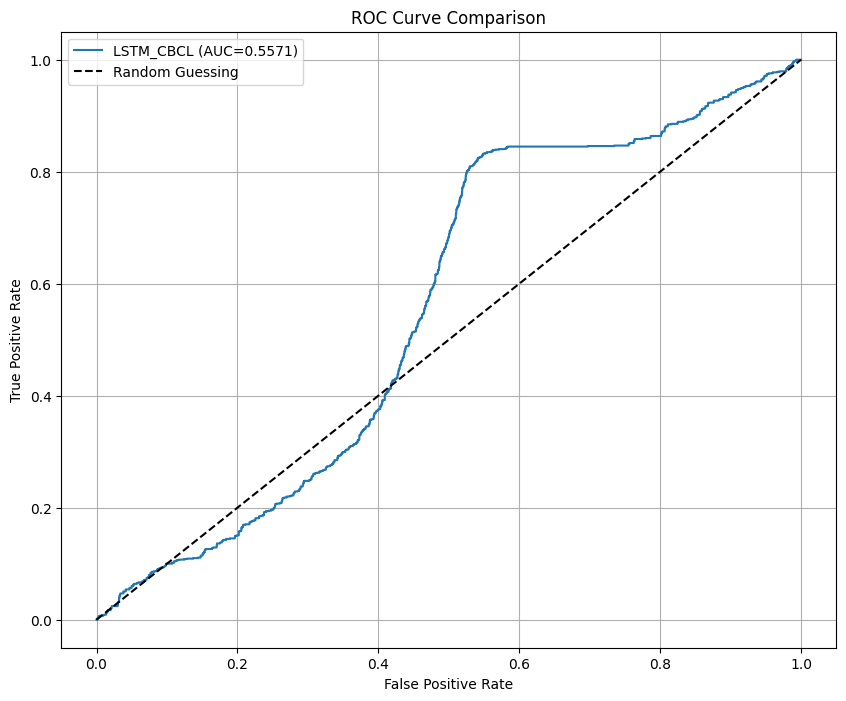

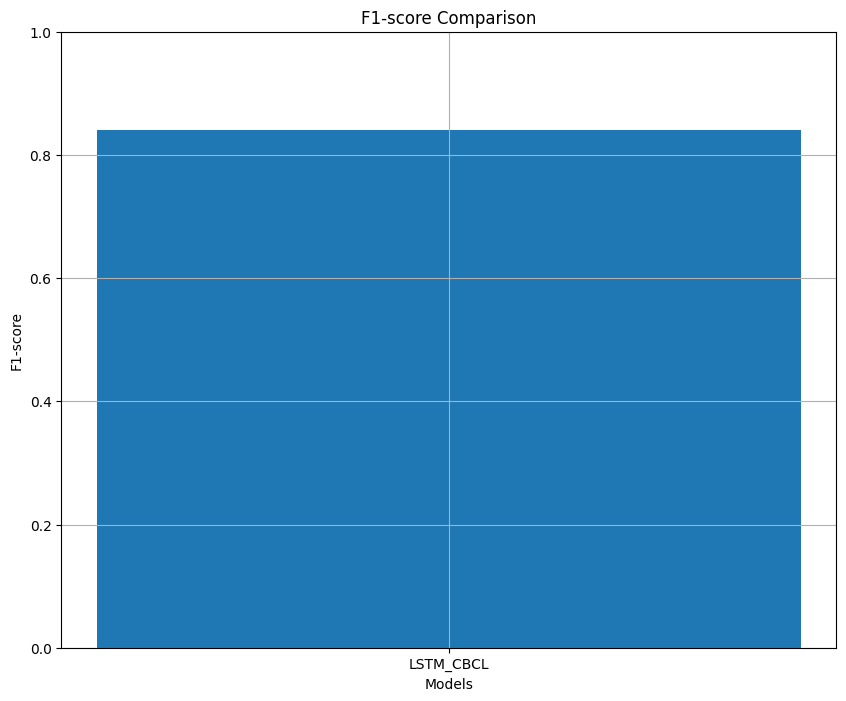

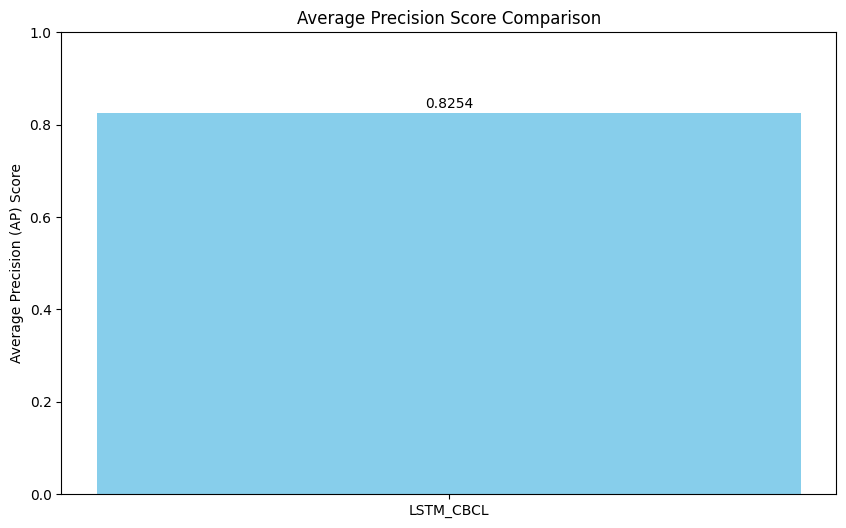

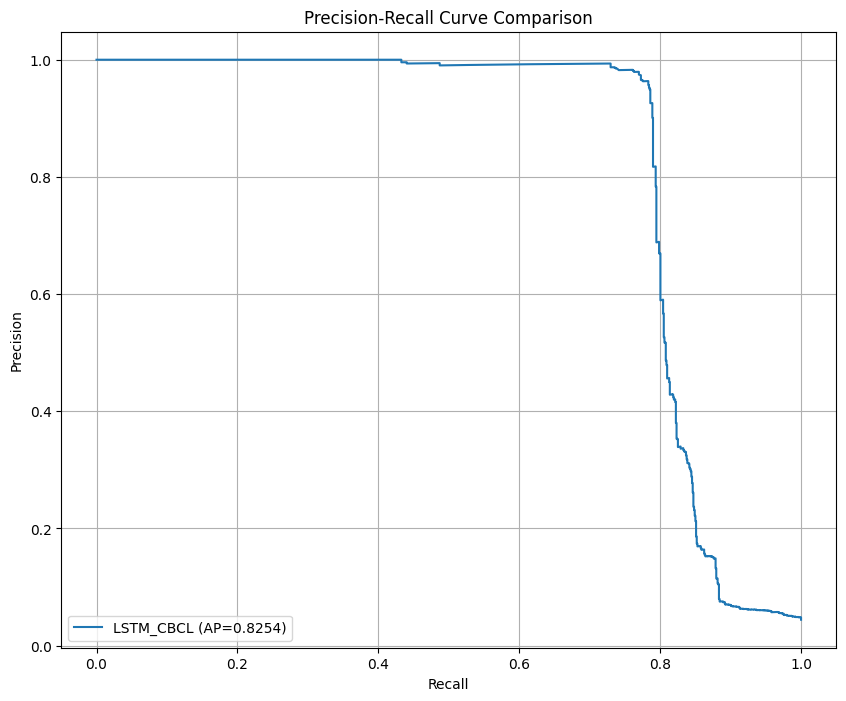

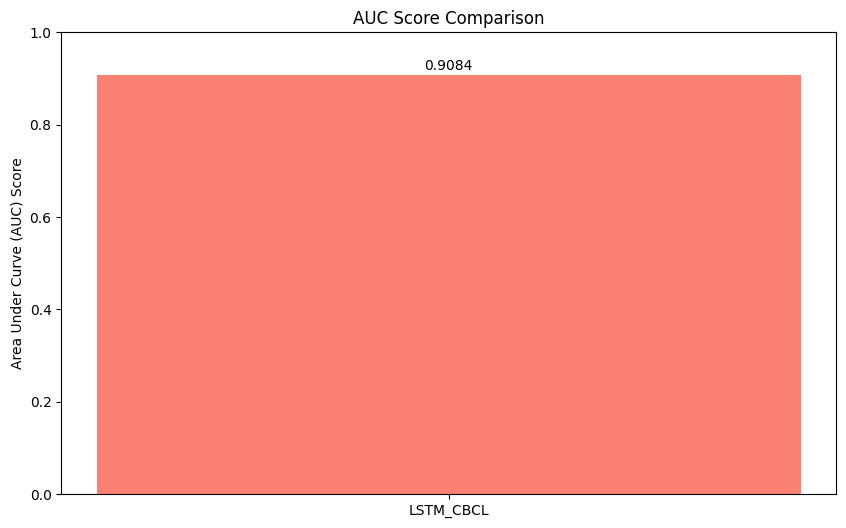

Testing models on PSM dataset:
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.172489 - val_loss: 0.122344
	 Breakdown: 
	 MSE: 0.051737, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.073734 - val_loss: 0.067056
	 Breakdown: 
	 MSE: 0.015980, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.046299 - val_loss: 0.050027
	 Breakdown: 
	 MSE: 0.010688, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.035319 - val_loss: 0.041185
	 Breakdown: 
	 MSE: 0.009443, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.028532 - val_loss: 0.035627
	 Breakdown: 
	 MSE: 0.008911, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.023995 - val_loss: 0.031921
	 Breakdown: 
	 MSE: 0.008644, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.020814 - val_loss: 0.029178
	 Breakdown: 
	 MSE: 

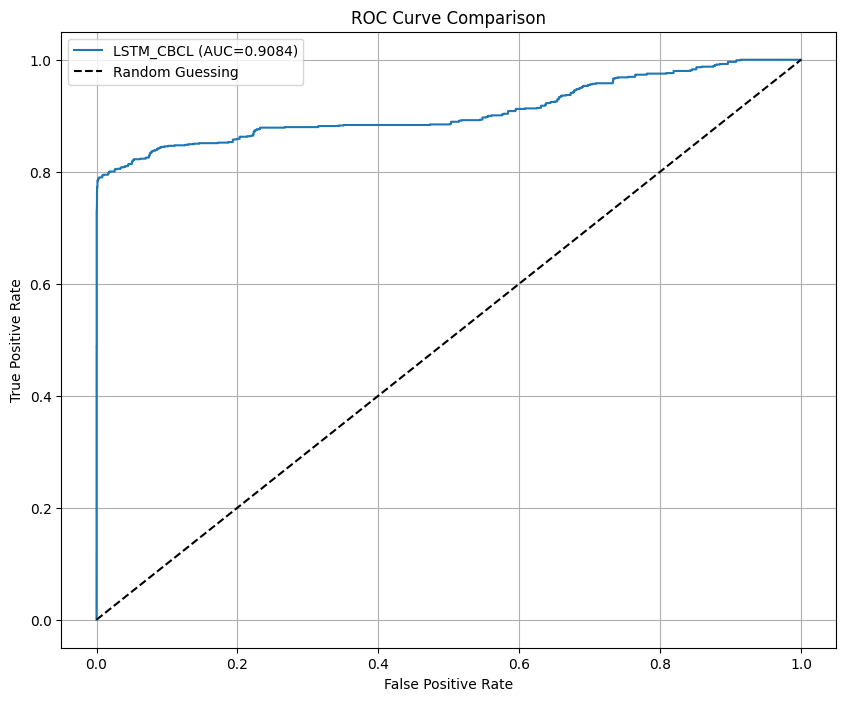

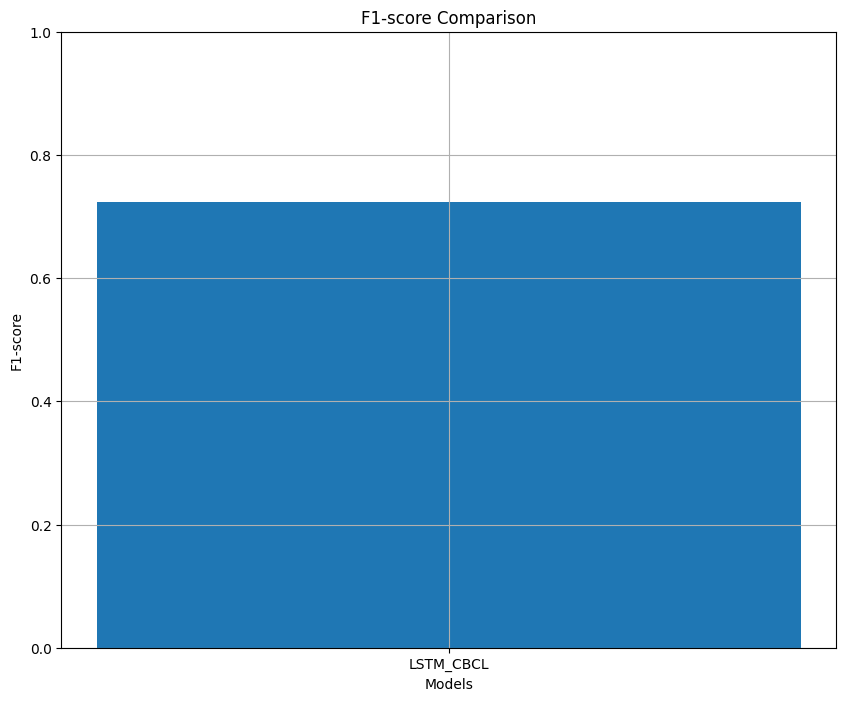

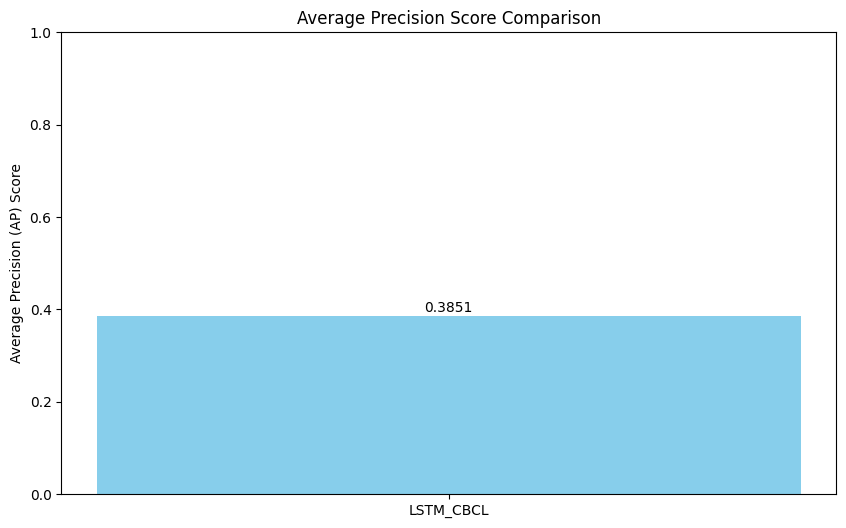

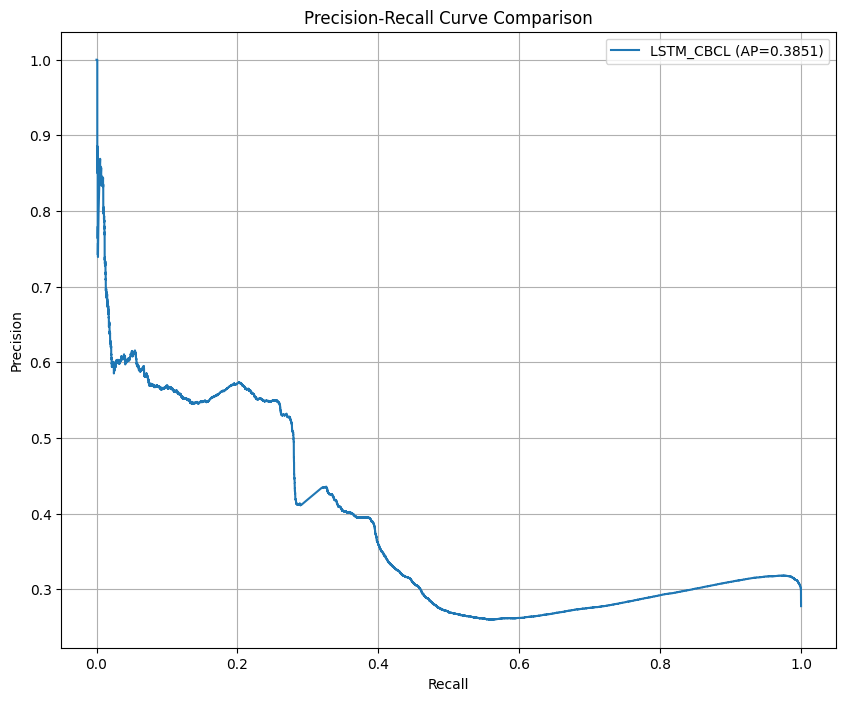

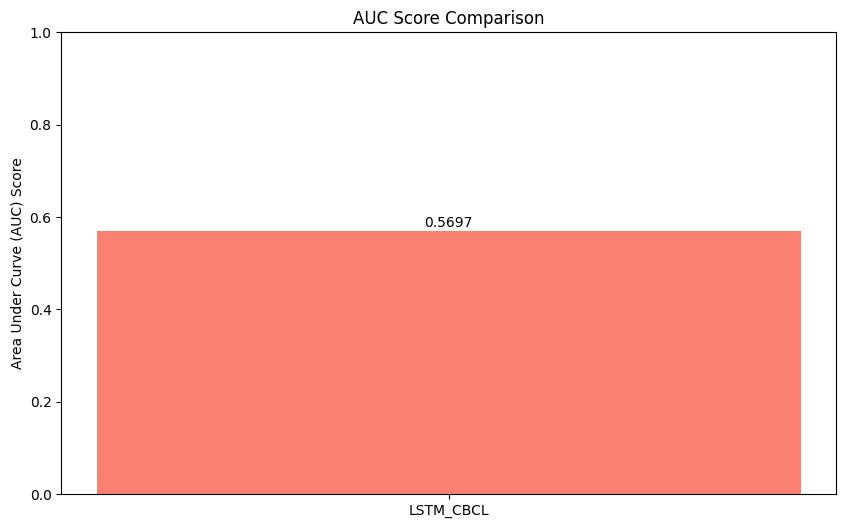

Testing models on SMAP_MSL dataset:
Using window size of 10...
	 Rover A - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.067243 - val_loss: 0.064158
	 Breakdown: 
	 MSE: 0.024721, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.066553 - val_loss: 0.063794
	 Breakdown: 
	 MSE: 0.020601, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.066474 - val_loss: 0.063427
	 Breakdown: 
	 MSE: 0.022554, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.066485 - val_loss: 0.063060
	 Breakdown: 
	 MSE: 0.021540, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.065738 - val_loss: 0.062694
	 Breakdown: 
	 MSE: 0.020388, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.065101 - val_loss: 0.062329
	 Breakdown: 
	 MSE: 0.023049, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss

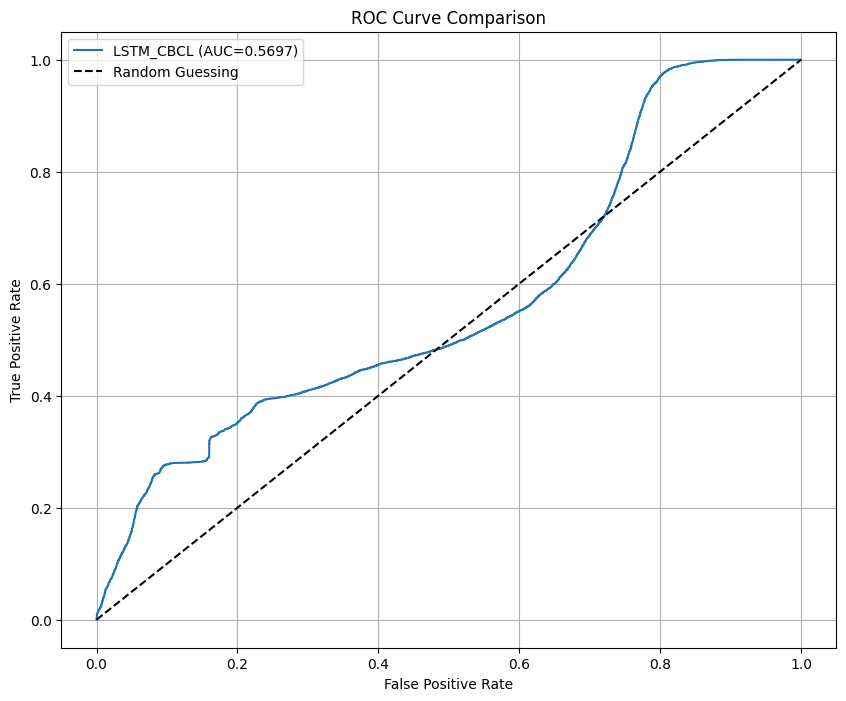

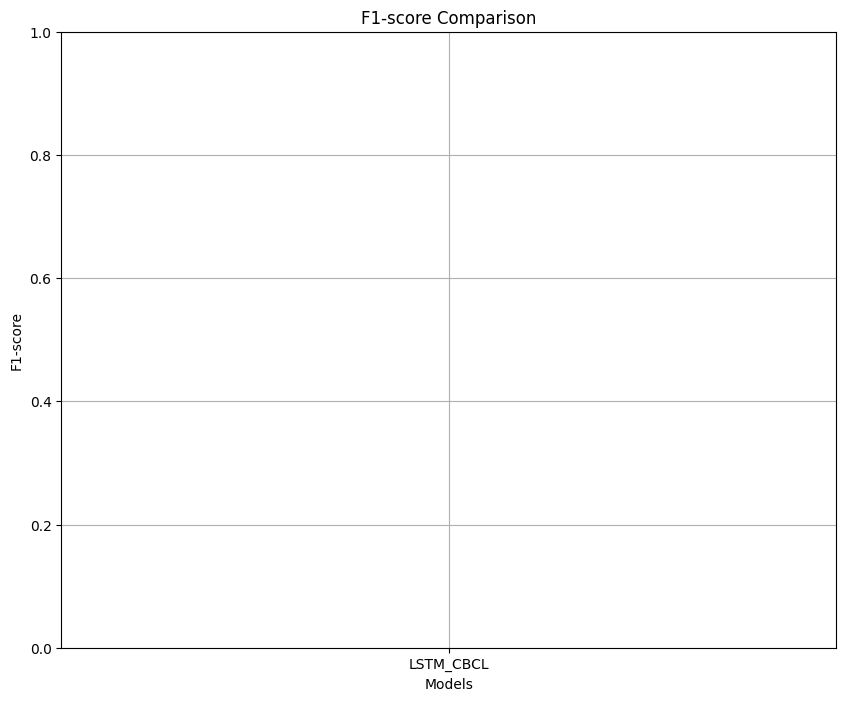

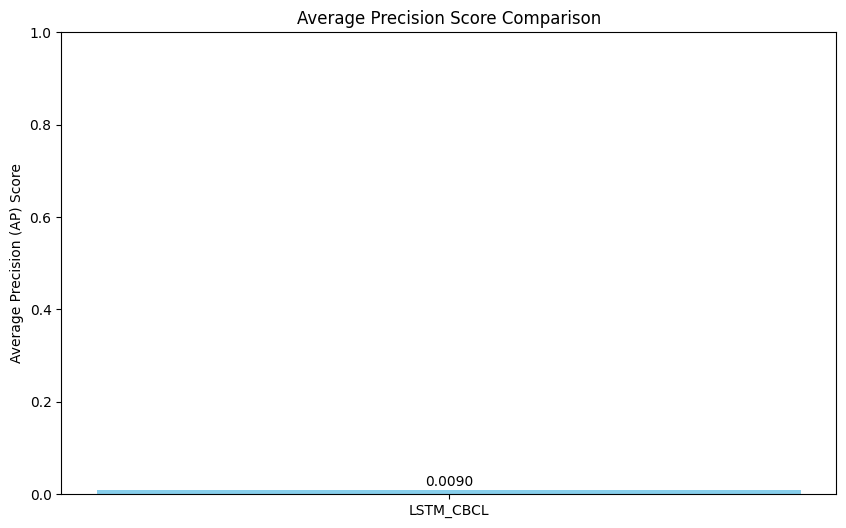

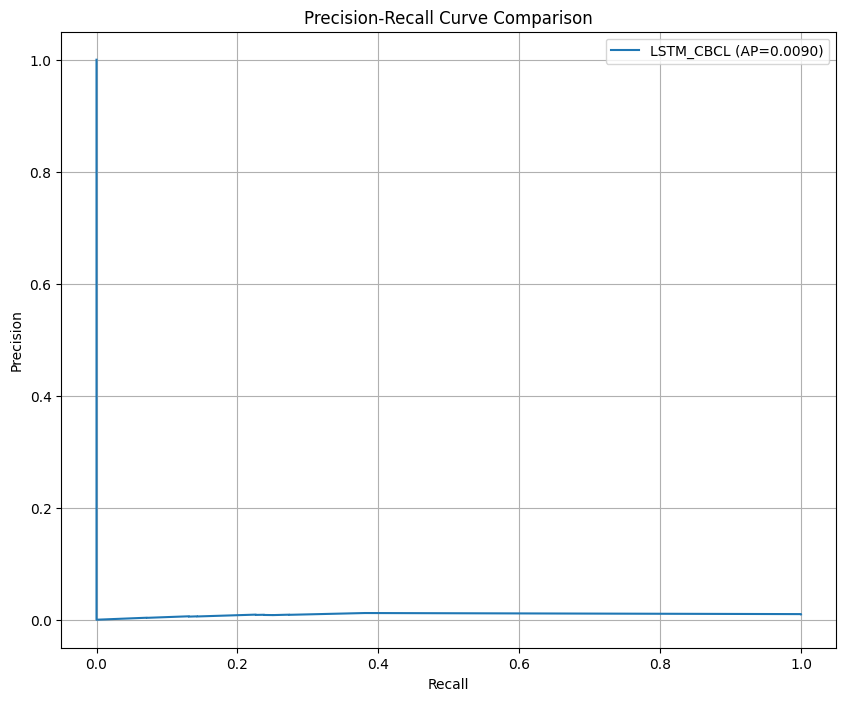

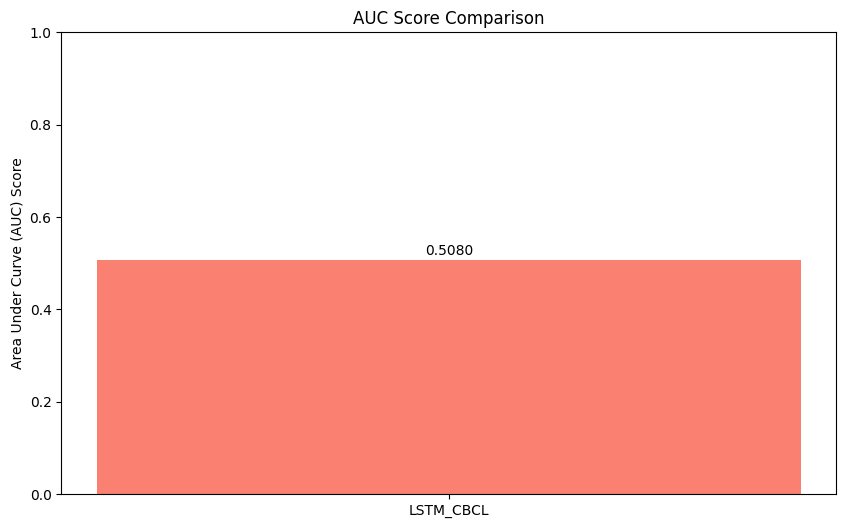

	 Rover B - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.049405 - val_loss: 0.044171
	 Breakdown: 
	 MSE: 0.004623, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.049267 - val_loss: 0.043934
	 Breakdown: 
	 MSE: 0.005860, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.049336 - val_loss: 0.043694
	 Breakdown: 
	 MSE: 0.005655, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.049058 - val_loss: 0.043453
	 Breakdown: 
	 MSE: 0.005508, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.048755 - val_loss: 0.043212
	 Breakdown: 
	 MSE: 0.005249, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.048594 - val_loss: 0.042971
	 Breakdown: 
	 MSE: 0.005200, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.048026 - val_loss: 0.042731
	 Breakdown: 
	 MSE: 0.005809, 

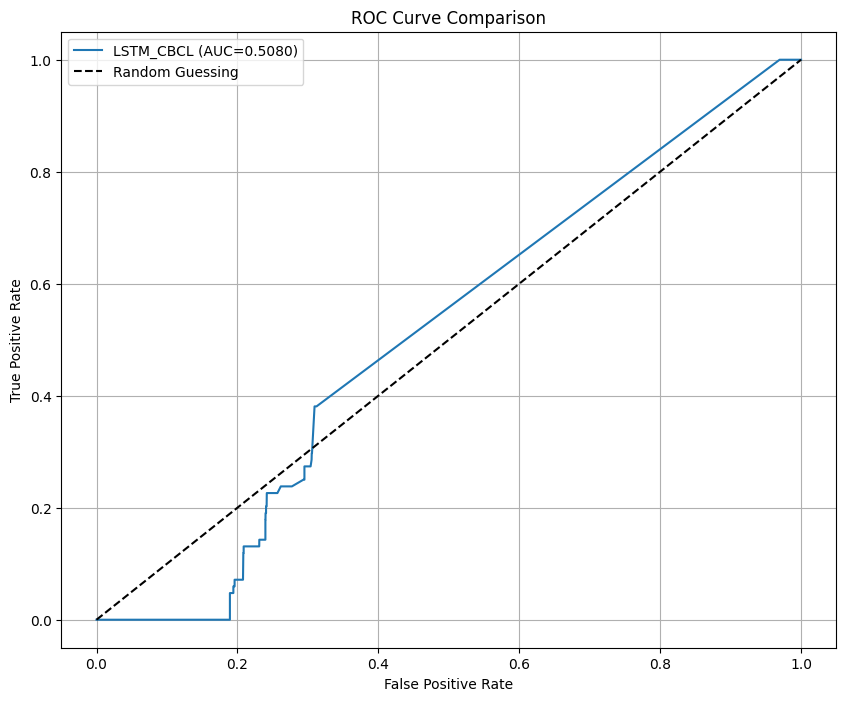

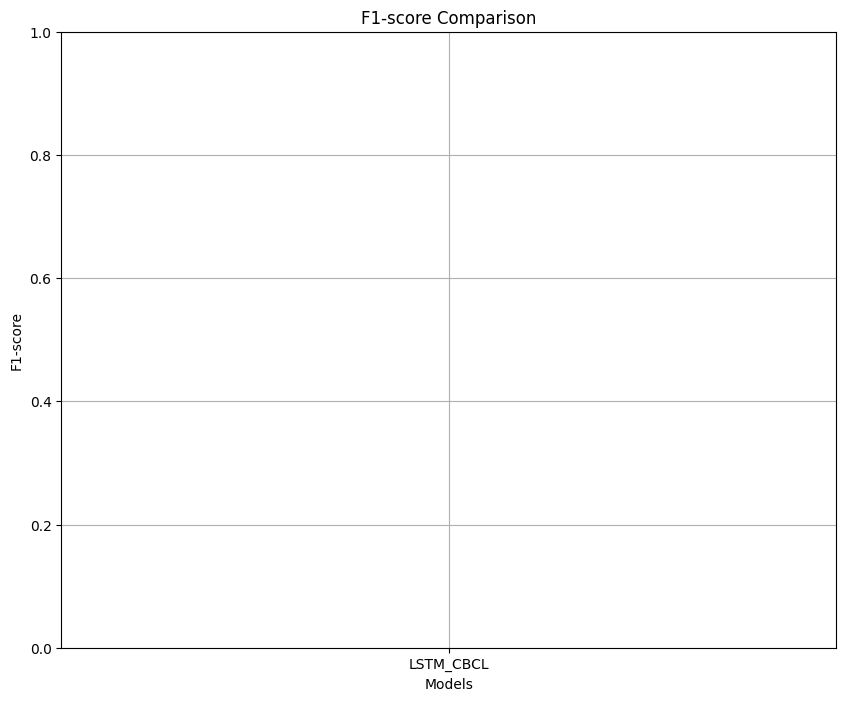

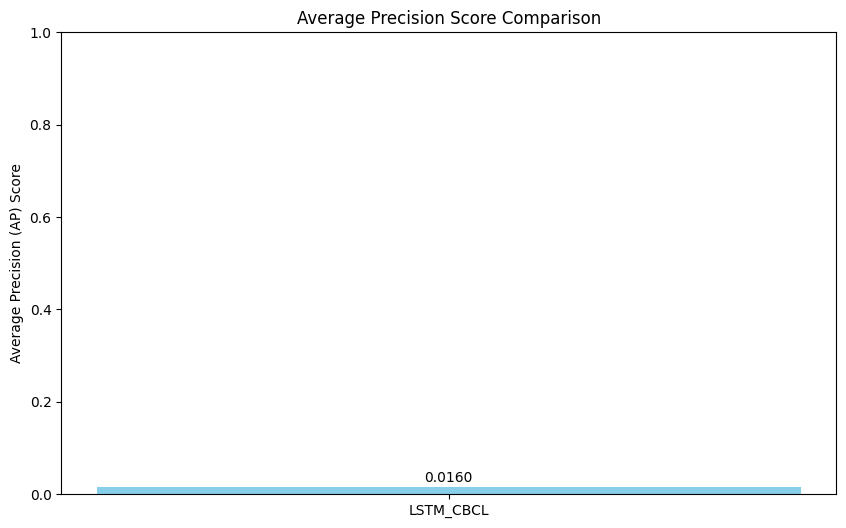

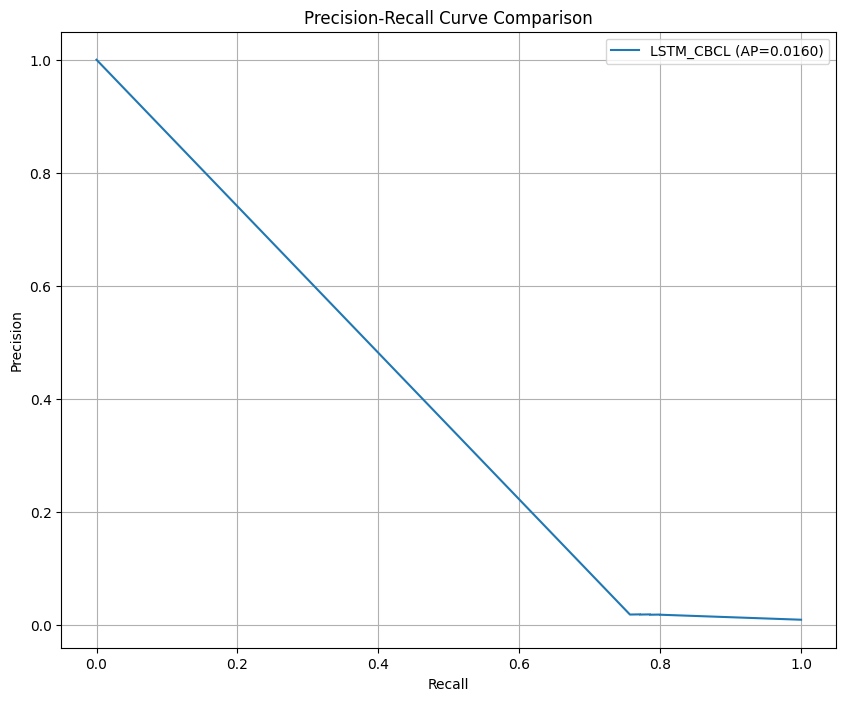

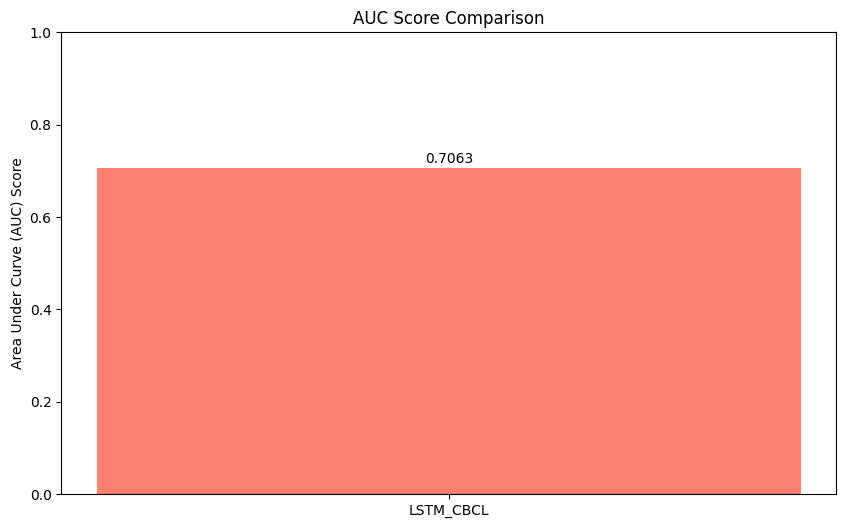

	 Rover C - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.054533 - val_loss: 0.052439
	 Breakdown: 
	 MSE: 0.006044, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.054276 - val_loss: 0.052165
	 Breakdown: 
	 MSE: 0.005688, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.053945 - val_loss: 0.051887
	 Breakdown: 
	 MSE: 0.005796, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.053737 - val_loss: 0.051608
	 Breakdown: 
	 MSE: 0.005492, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.053415 - val_loss: 0.051329
	 Breakdown: 
	 MSE: 0.005776, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.053186 - val_loss: 0.051050
	 Breakdown: 
	 MSE: 0.005413, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.052859 - val_loss: 0.050771
	 Breakdown: 
	 MSE: 0.005188, 

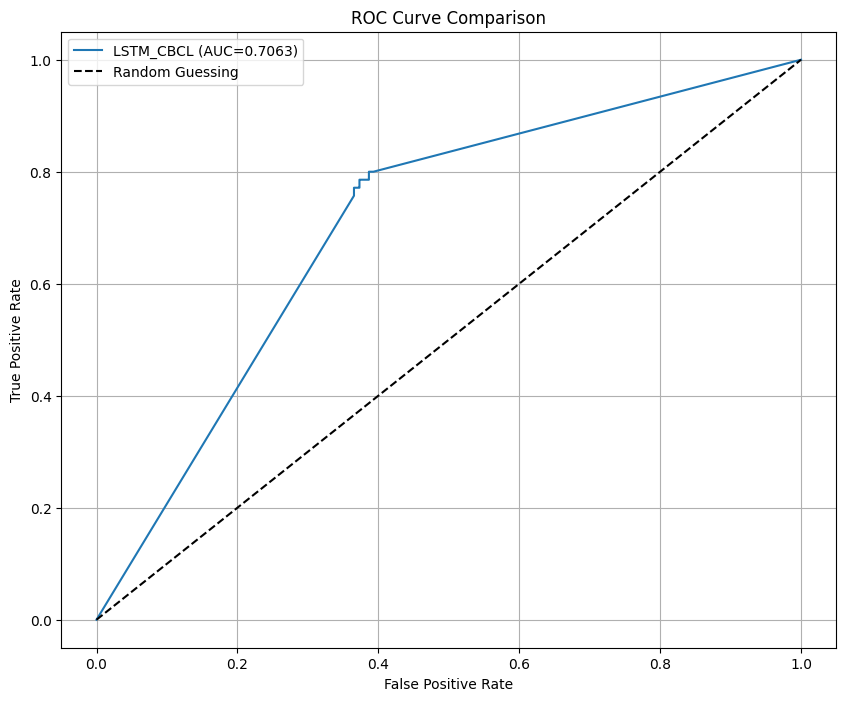

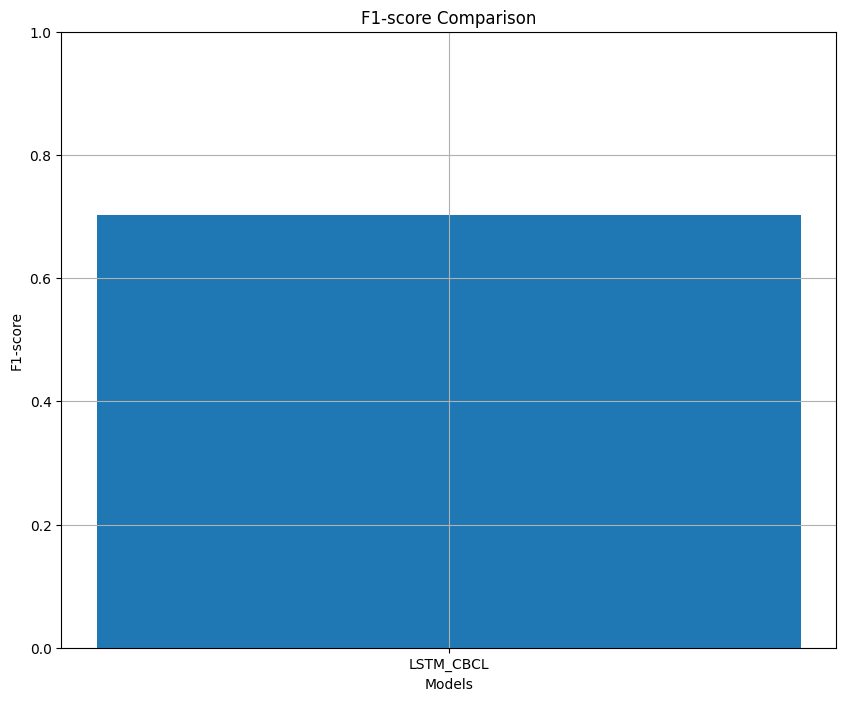

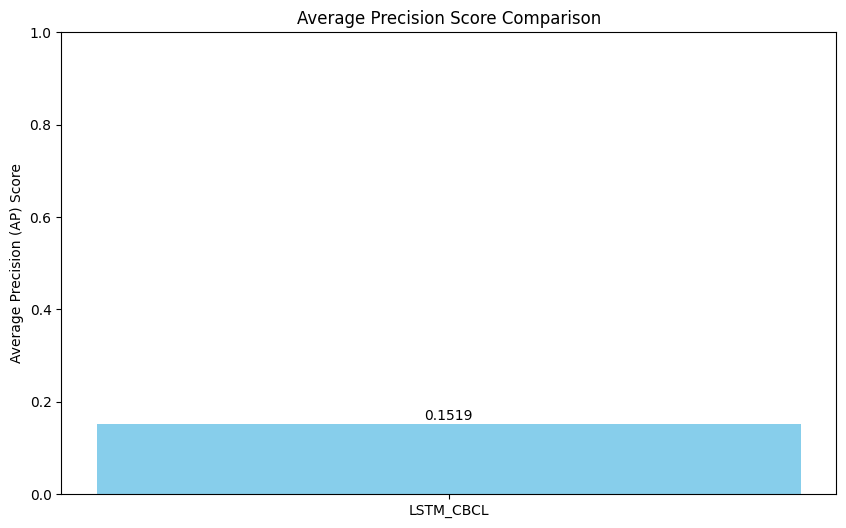

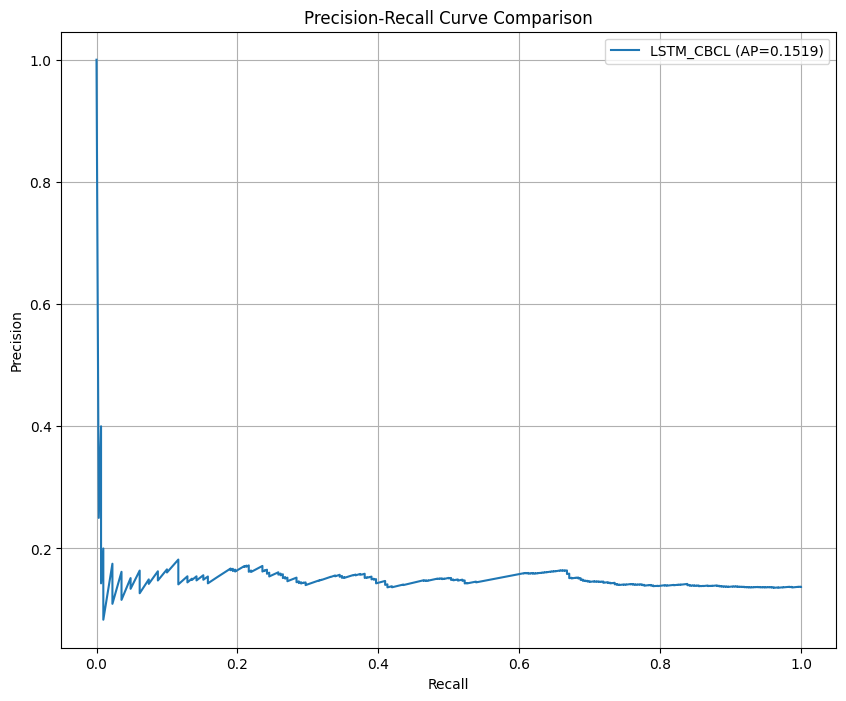

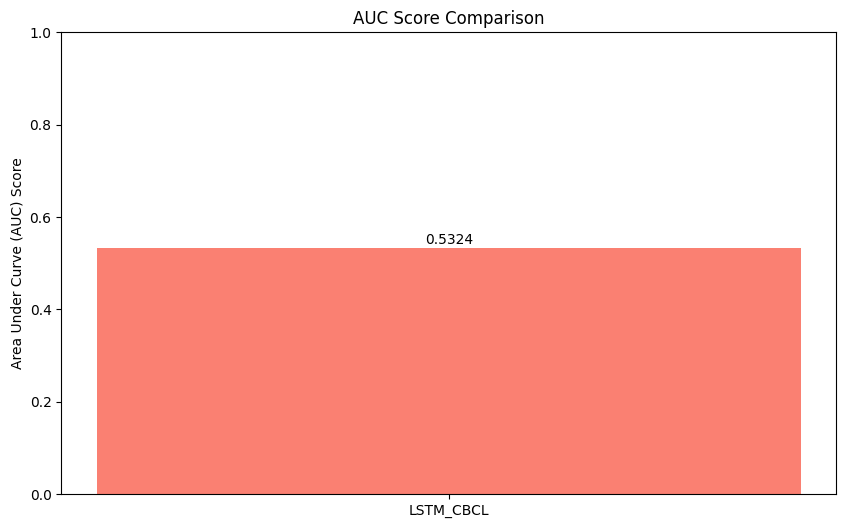

	 Rover D - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.079537 - val_loss: 0.068982
	 Breakdown: 
	 MSE: 0.035565, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.078956 - val_loss: 0.068559
	 Breakdown: 
	 MSE: 0.030793, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.078094 - val_loss: 0.068134
	 Breakdown: 
	 MSE: 0.035559, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.078142 - val_loss: 0.067707
	 Breakdown: 
	 MSE: 0.033327, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.077511 - val_loss: 0.067281
	 Breakdown: 
	 MSE: 0.035434, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.076979 - val_loss: 0.066855
	 Breakdown: 
	 MSE: 0.033039, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.076850 - val_loss: 0.066429
	 Breakdown: 
	 MSE: 0.033579, 

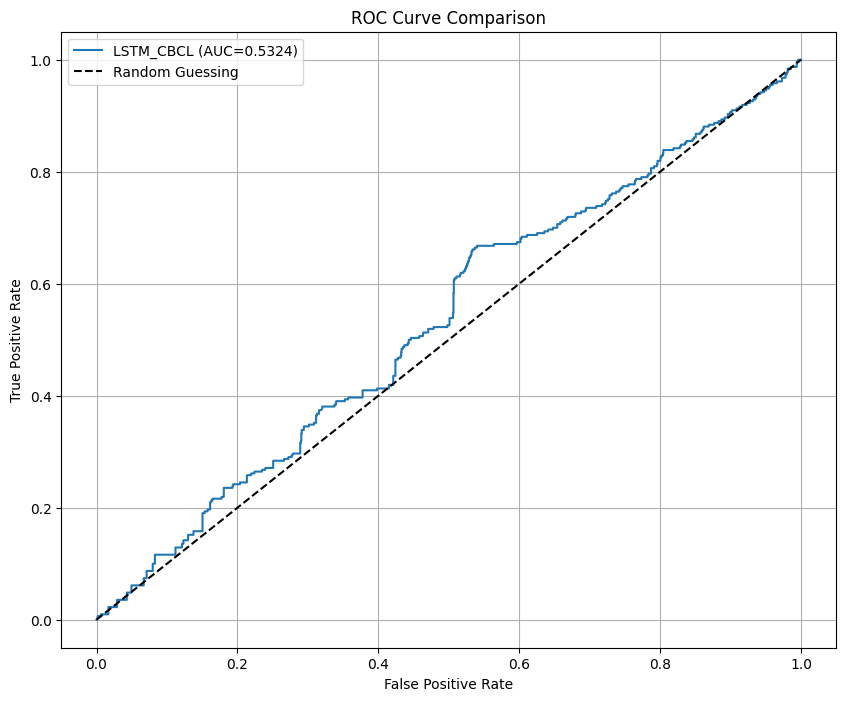

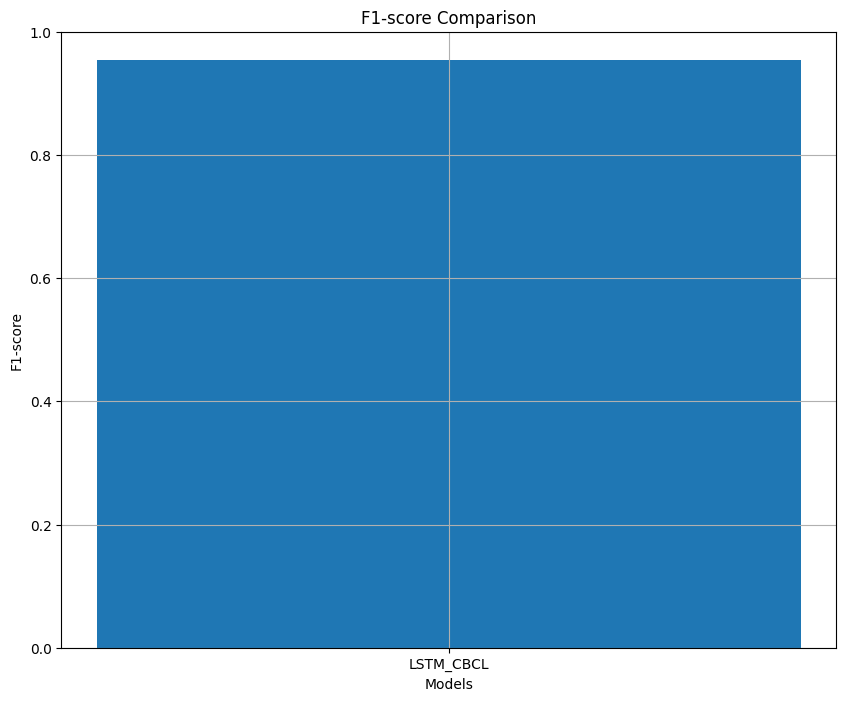

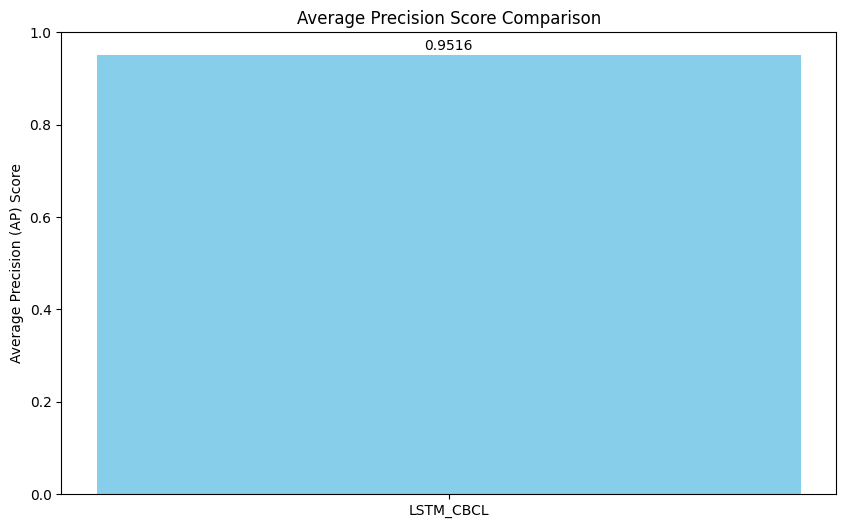

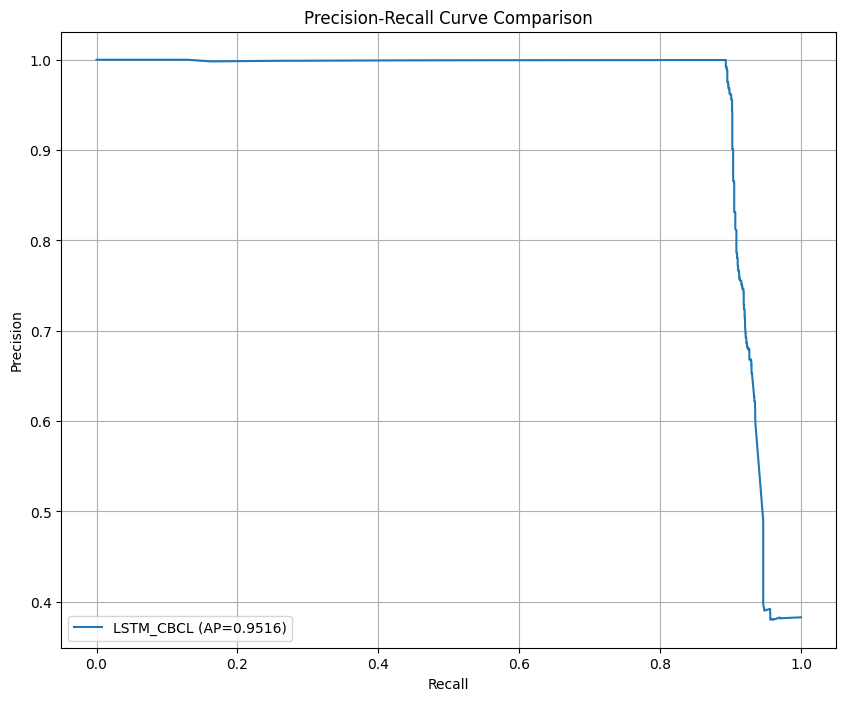

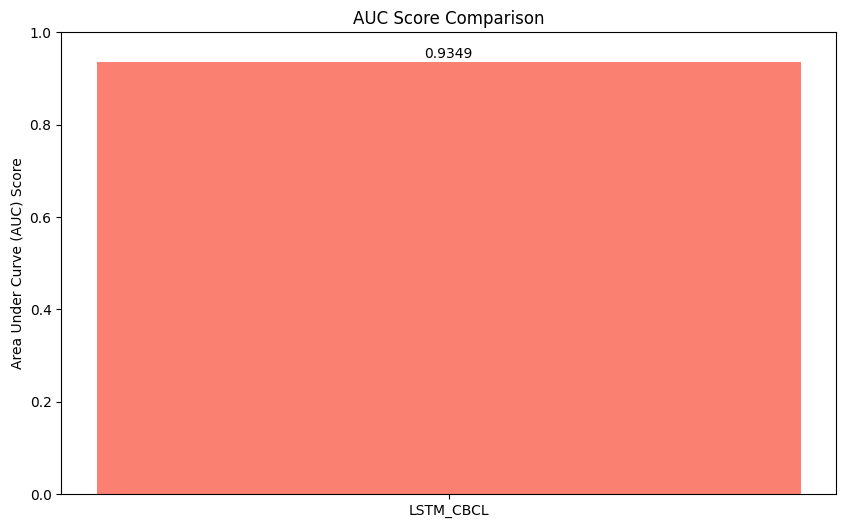

	 Rover D - Number 2
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.065811 - val_loss: 0.063507
	 Breakdown: 
	 MSE: 0.023746, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.065694 - val_loss: 0.063138
	 Breakdown: 
	 MSE: 0.020089, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.065210 - val_loss: 0.062767
	 Breakdown: 
	 MSE: 0.019107, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.064727 - val_loss: 0.062395
	 Breakdown: 
	 MSE: 0.023108, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.064908 - val_loss: 0.062024
	 Breakdown: 
	 MSE: 0.022116, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.064114 - val_loss: 0.061654
	 Breakdown: 
	 MSE: 0.019873, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.063680 - val_loss: 0.061286
	 Breakdown: 
	 MSE: 0.020174, 

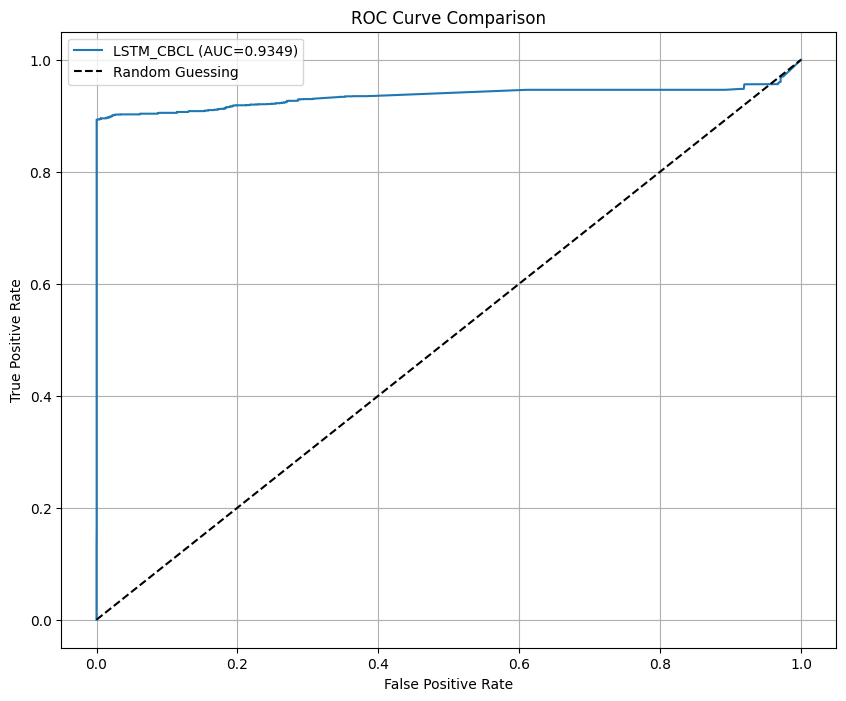

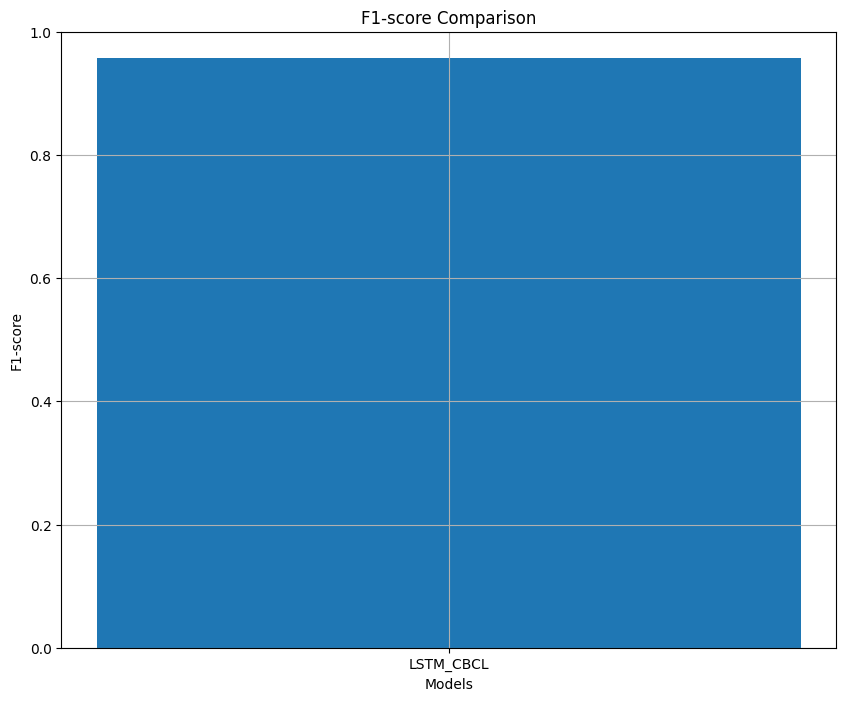

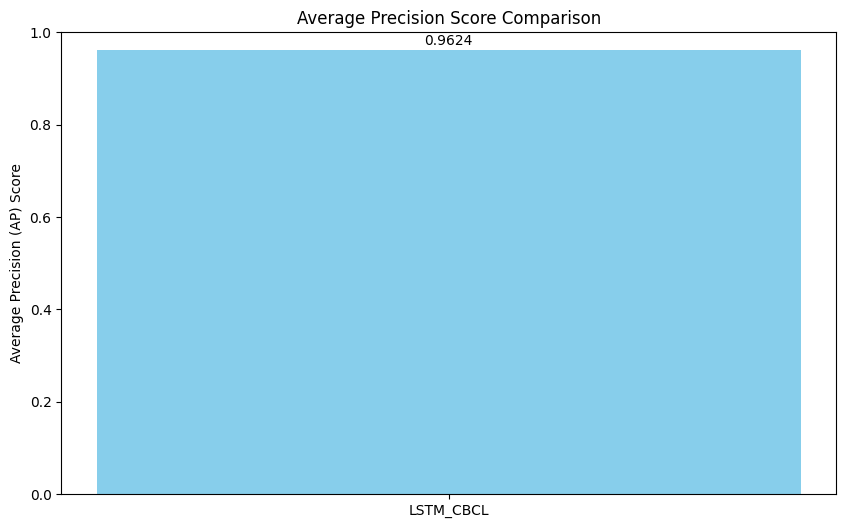

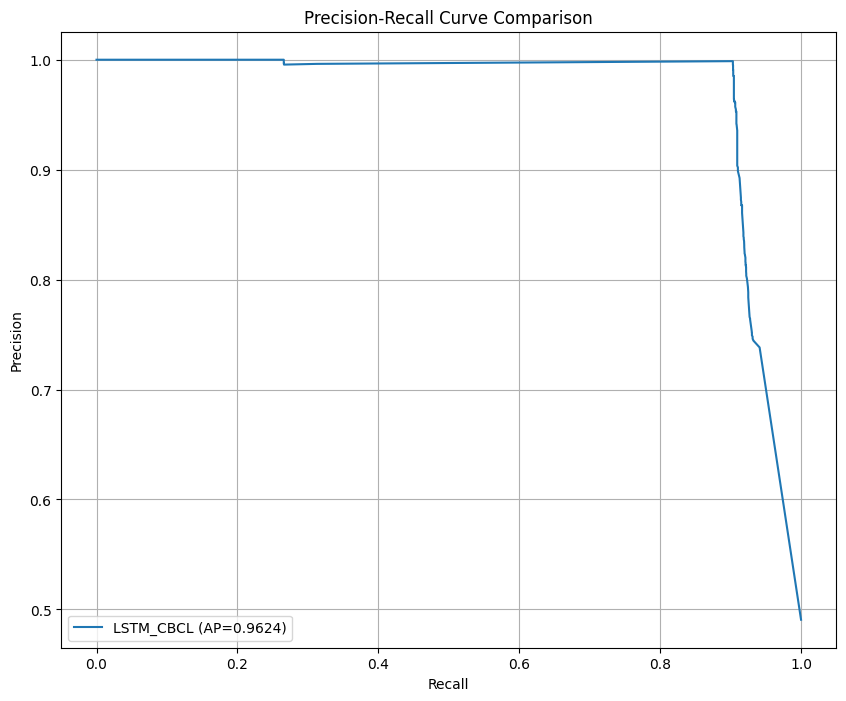

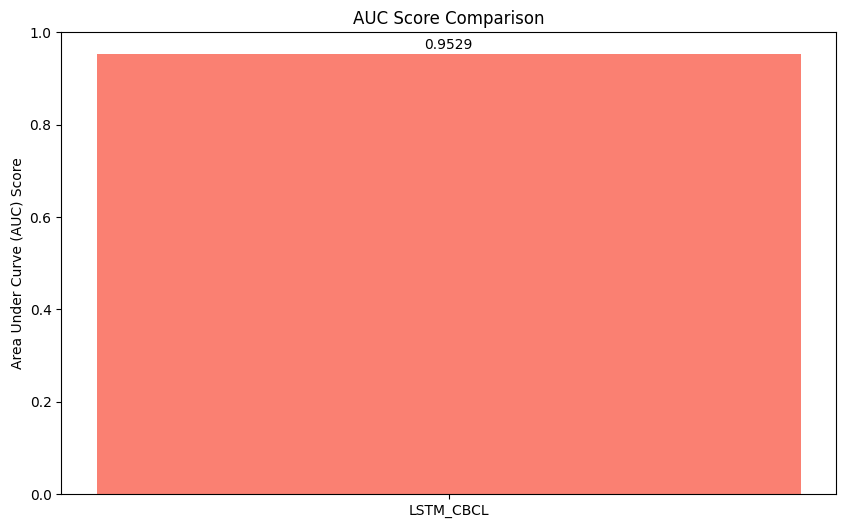

	 Rover E - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.074937 - val_loss: 0.064494
	 Breakdown: 
	 MSE: 0.031941, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.075173 - val_loss: 0.064129
	 Breakdown: 
	 MSE: 0.030193, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.074512 - val_loss: 0.063760
	 Breakdown: 
	 MSE: 0.030857, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.074078 - val_loss: 0.063392
	 Breakdown: 
	 MSE: 0.034054, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.073463 - val_loss: 0.063024
	 Breakdown: 
	 MSE: 0.028064, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.073522 - val_loss: 0.062657
	 Breakdown: 
	 MSE: 0.033363, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.073000 - val_loss: 0.062292
	 Breakdown: 
	 MSE: 0.028964, 

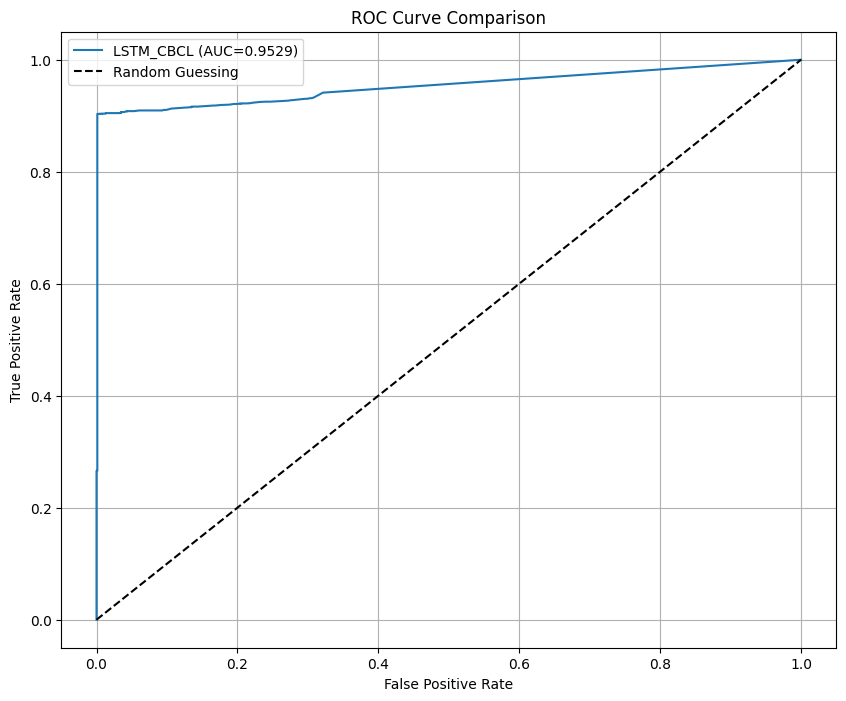

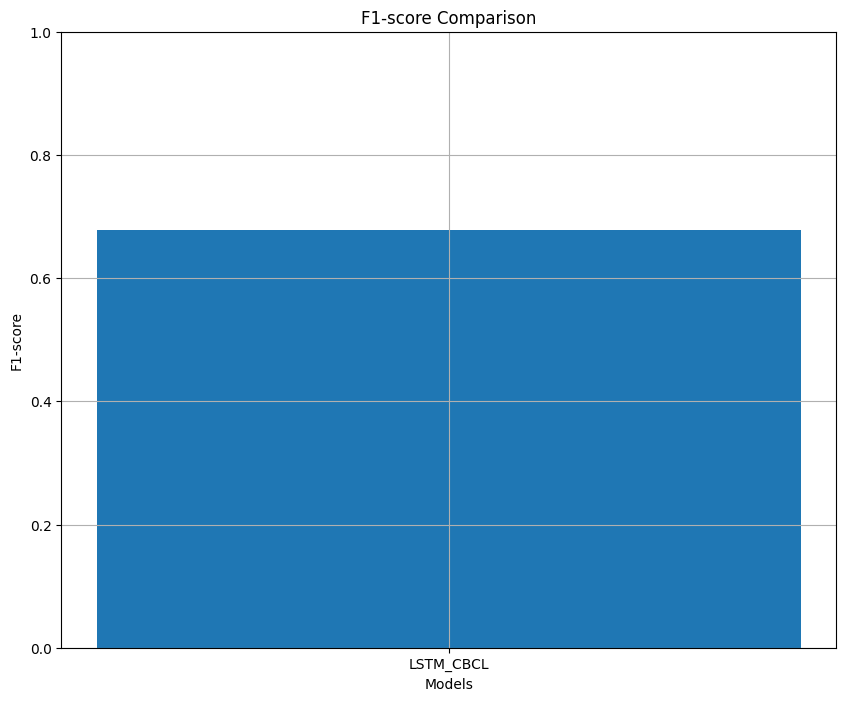

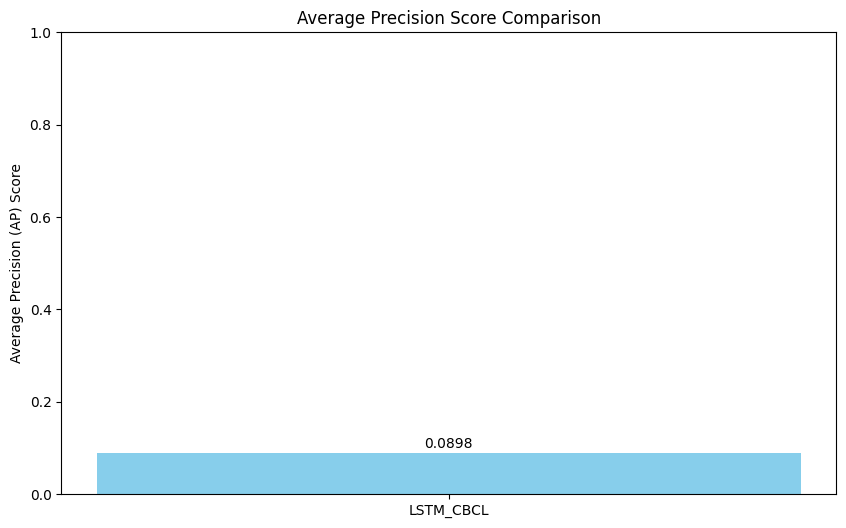

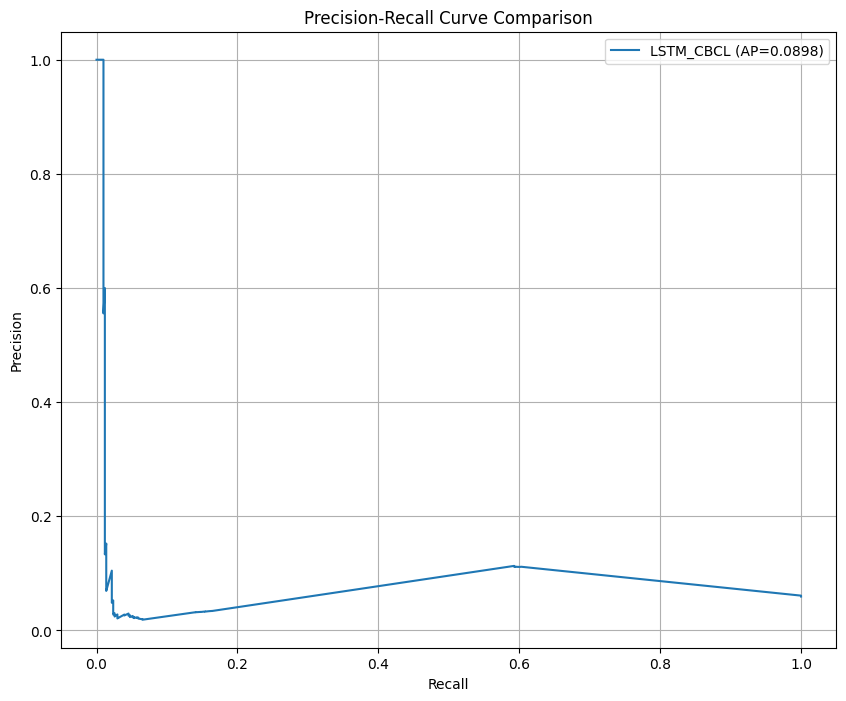

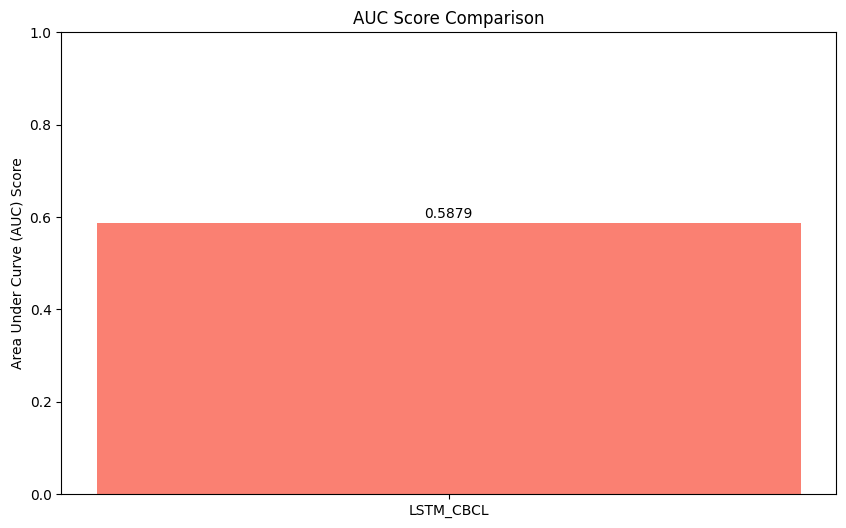

	 Rover F - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.066871 - val_loss: 0.066054
	 Breakdown: 
	 MSE: 0.021619, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.066254 - val_loss: 0.065681
	 Breakdown: 
	 MSE: 0.025415, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.065904 - val_loss: 0.065306
	 Breakdown: 
	 MSE: 0.023742, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.065412 - val_loss: 0.064930
	 Breakdown: 
	 MSE: 0.018974, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.065129 - val_loss: 0.064555
	 Breakdown: 
	 MSE: 0.023331, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.064649 - val_loss: 0.064182
	 Breakdown: 
	 MSE: 0.020072, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.064011 - val_loss: 0.063810
	 Breakdown: 
	 MSE: 0.019625, 

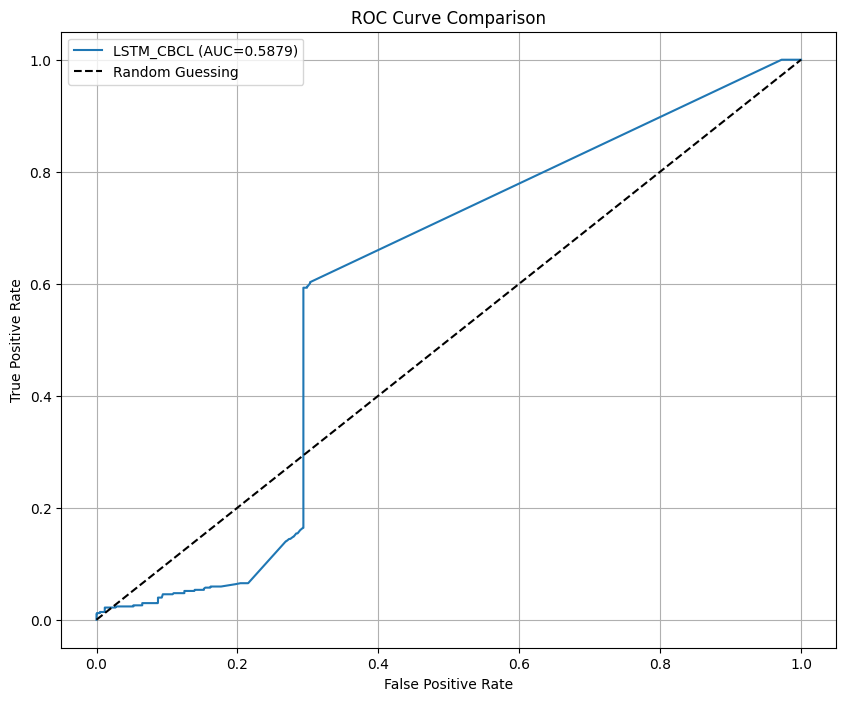

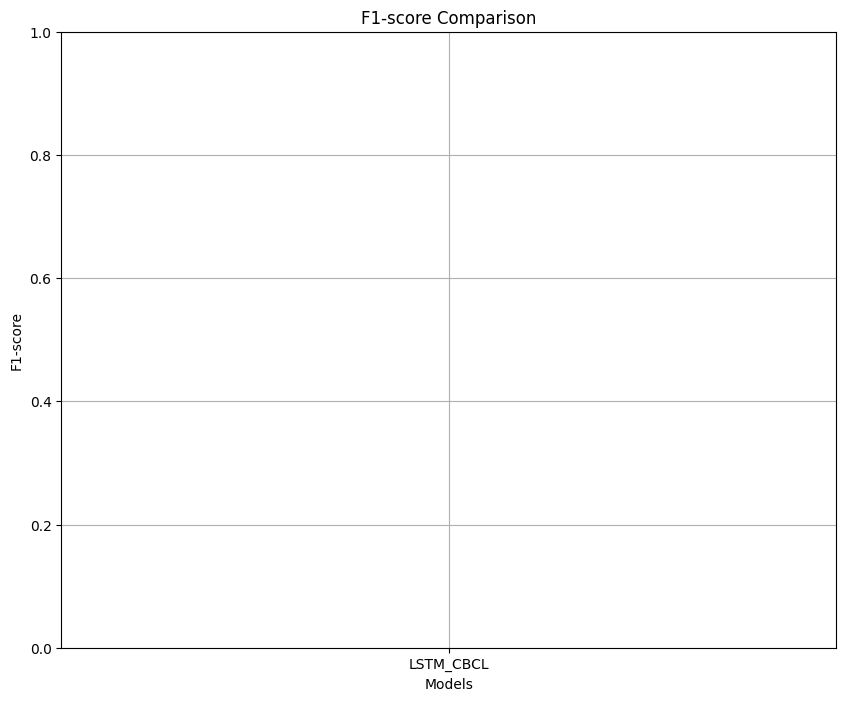

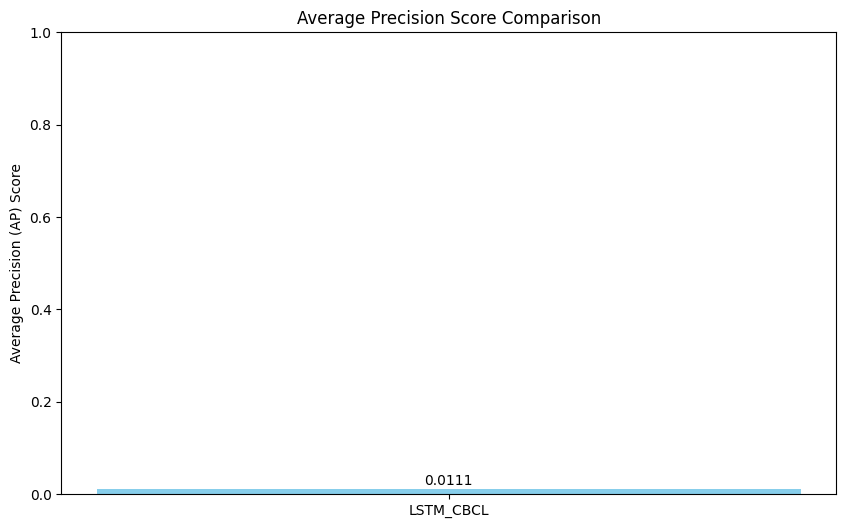

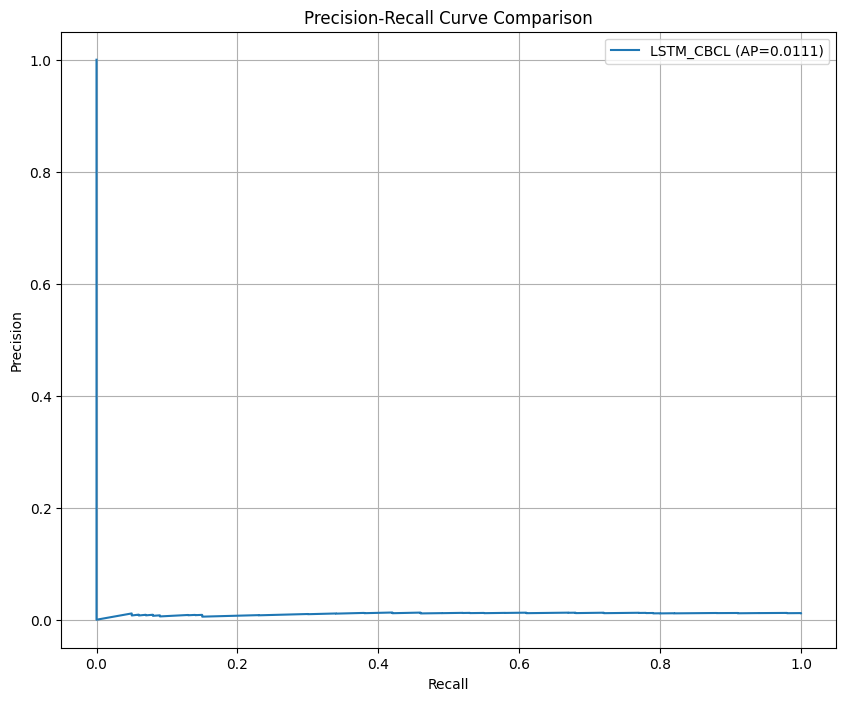

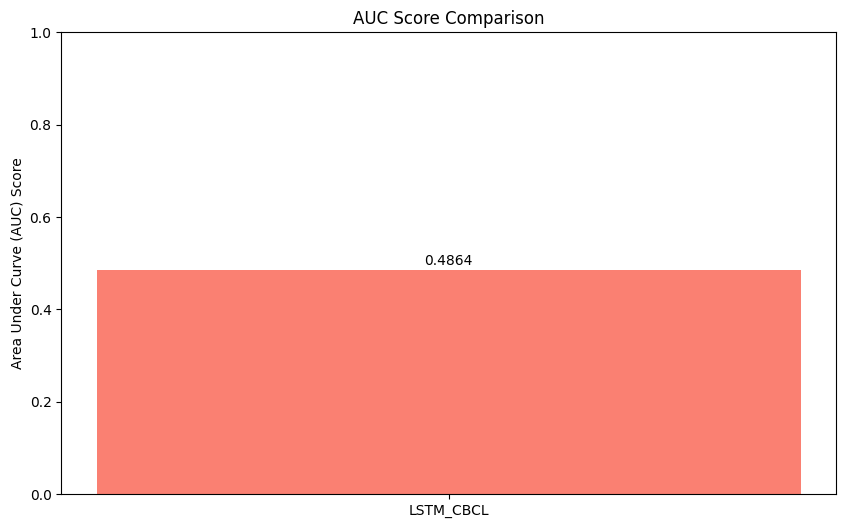

	 Rover G - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.081389 - val_loss: 0.072069
	 Breakdown: 
	 MSE: 0.034821, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.081117 - val_loss: 0.071668
	 Breakdown: 
	 MSE: 0.037913, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.080688 - val_loss: 0.071263
	 Breakdown: 
	 MSE: 0.033883, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.080214 - val_loss: 0.070857
	 Breakdown: 
	 MSE: 0.036178, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.079780 - val_loss: 0.070451
	 Breakdown: 
	 MSE: 0.037115, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.079320 - val_loss: 0.070046
	 Breakdown: 
	 MSE: 0.035641, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.078695 - val_loss: 0.069642
	 Breakdown: 
	 MSE: 0.039053, 

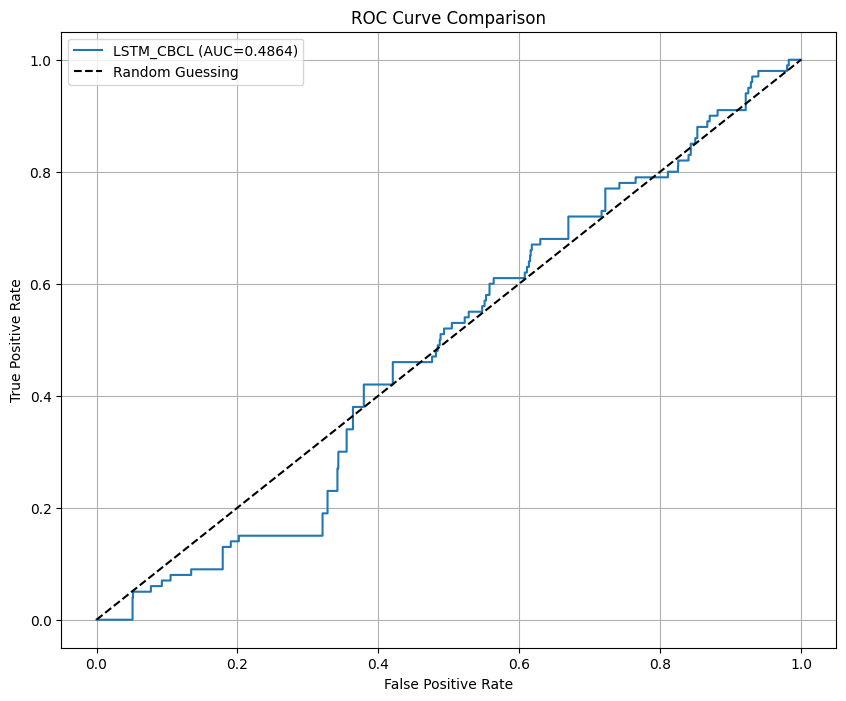

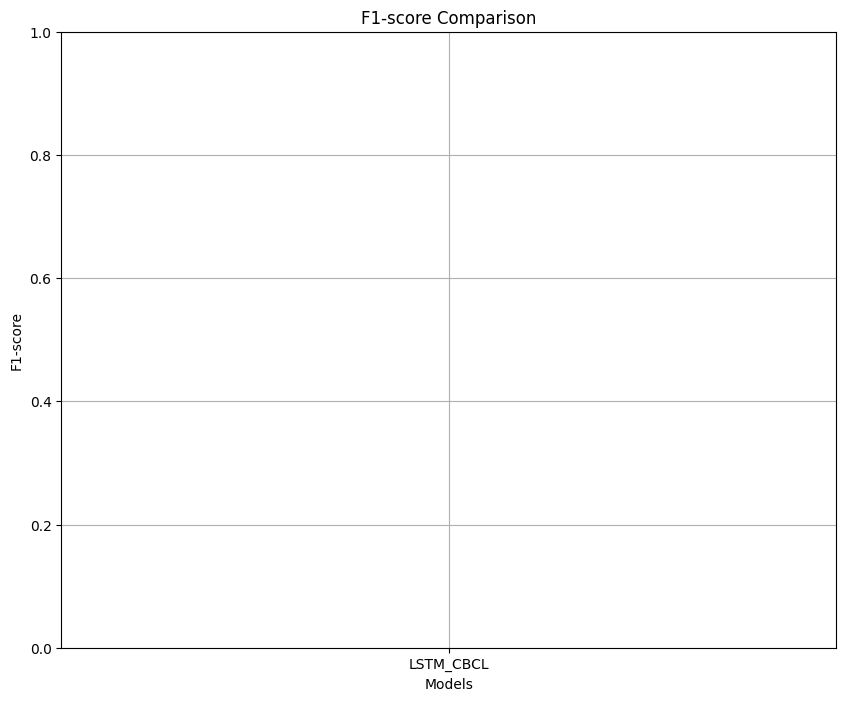

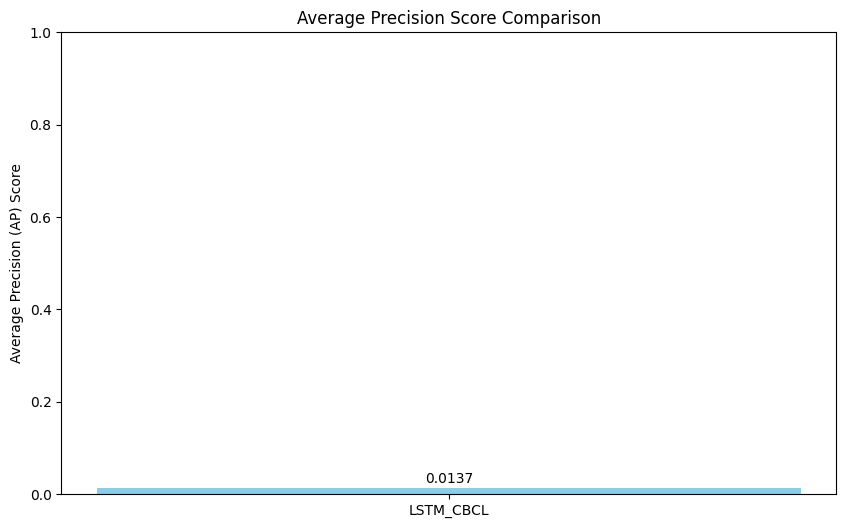

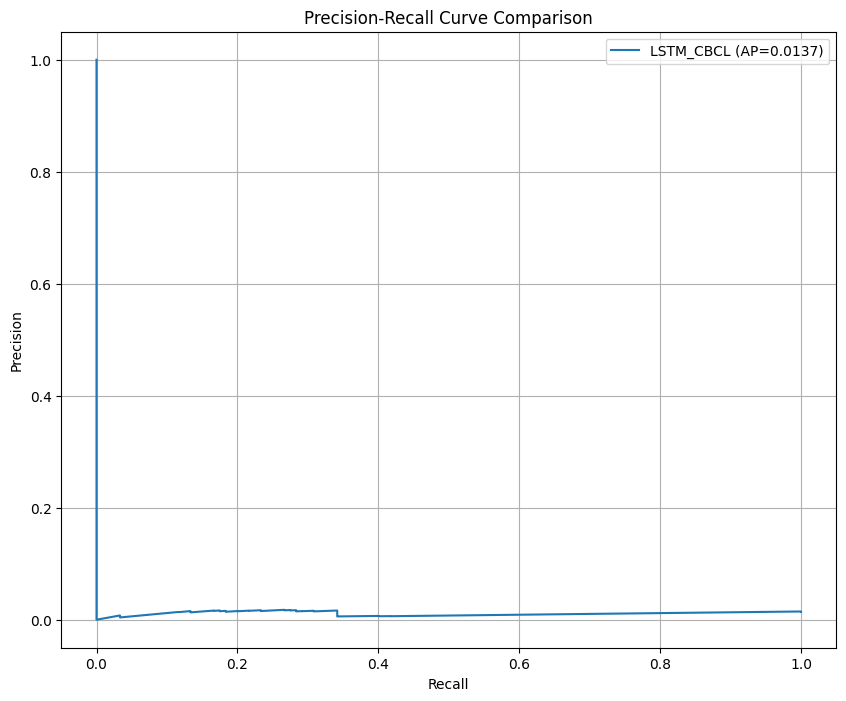

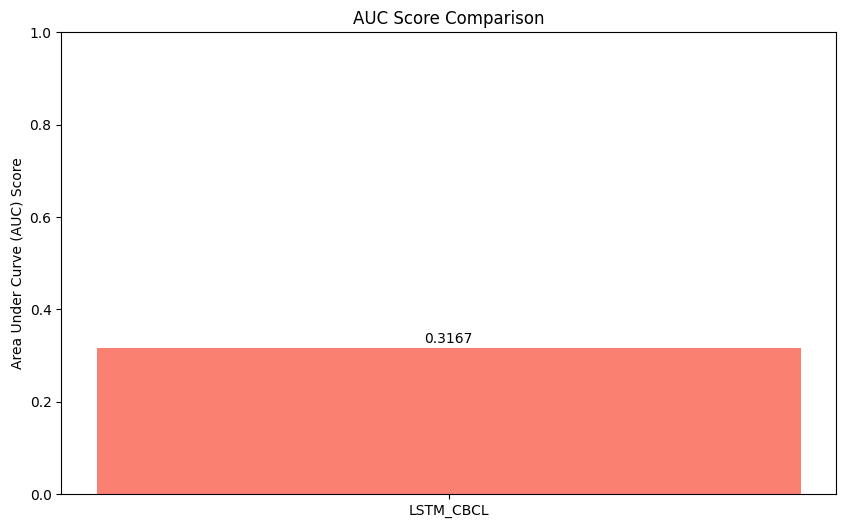

	 Rover M - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.057816 - val_loss: 0.056131
	 Breakdown: 
	 MSE: 0.009165, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.057568 - val_loss: 0.055846
	 Breakdown: 
	 MSE: 0.008845, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.057265 - val_loss: 0.055557
	 Breakdown: 
	 MSE: 0.009317, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.056969 - val_loss: 0.055267
	 Breakdown: 
	 MSE: 0.008729, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.056685 - val_loss: 0.054977
	 Breakdown: 
	 MSE: 0.009066, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.056383 - val_loss: 0.054686
	 Breakdown: 
	 MSE: 0.008625, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.056090 - val_loss: 0.054396
	 Breakdown: 
	 MSE: 0.008832, 

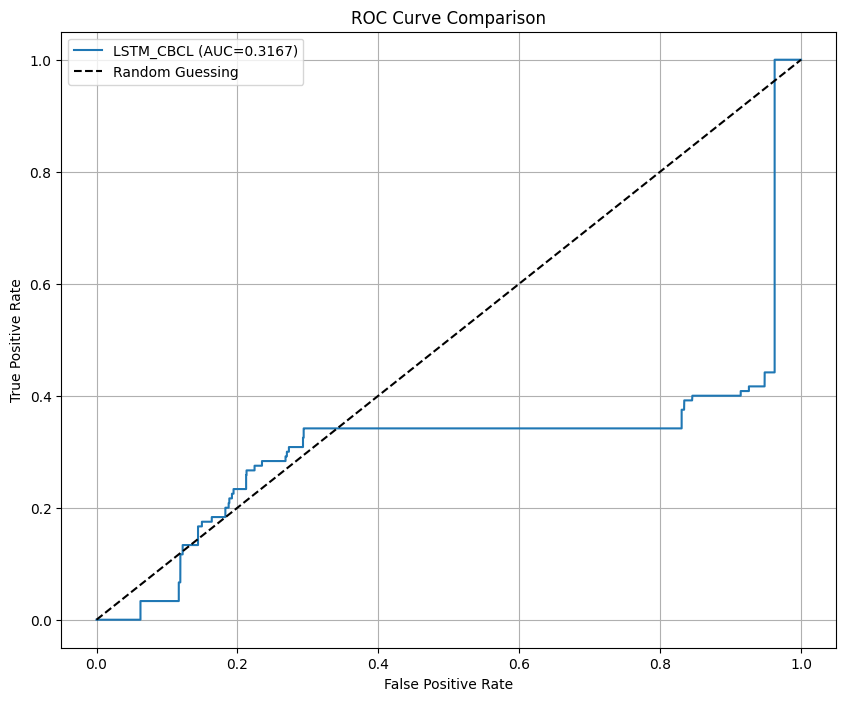

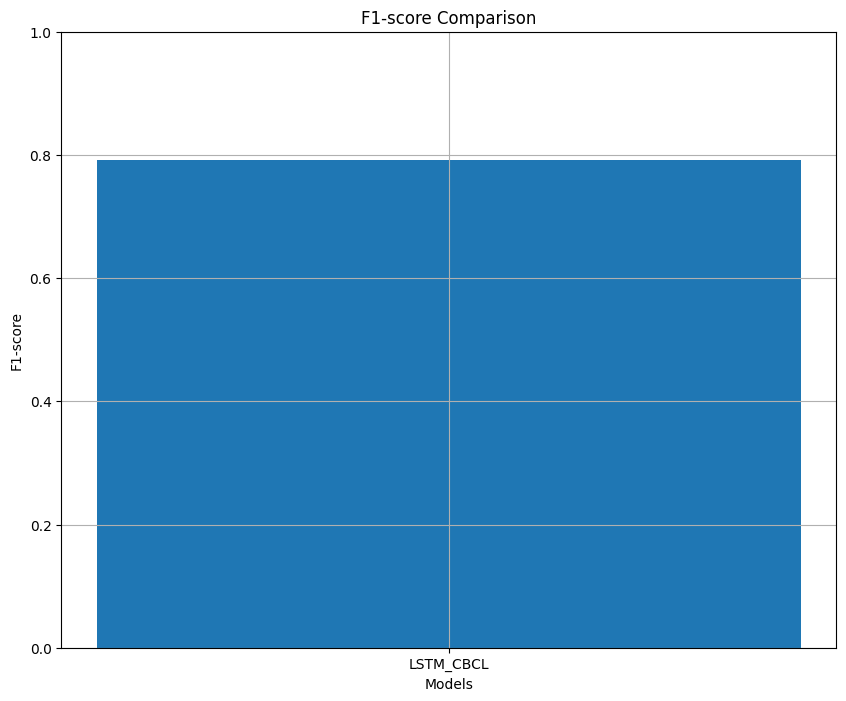

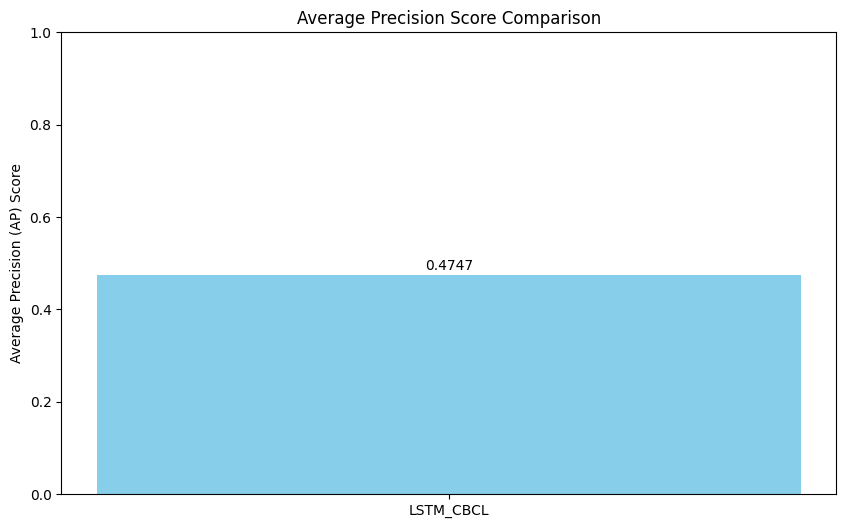

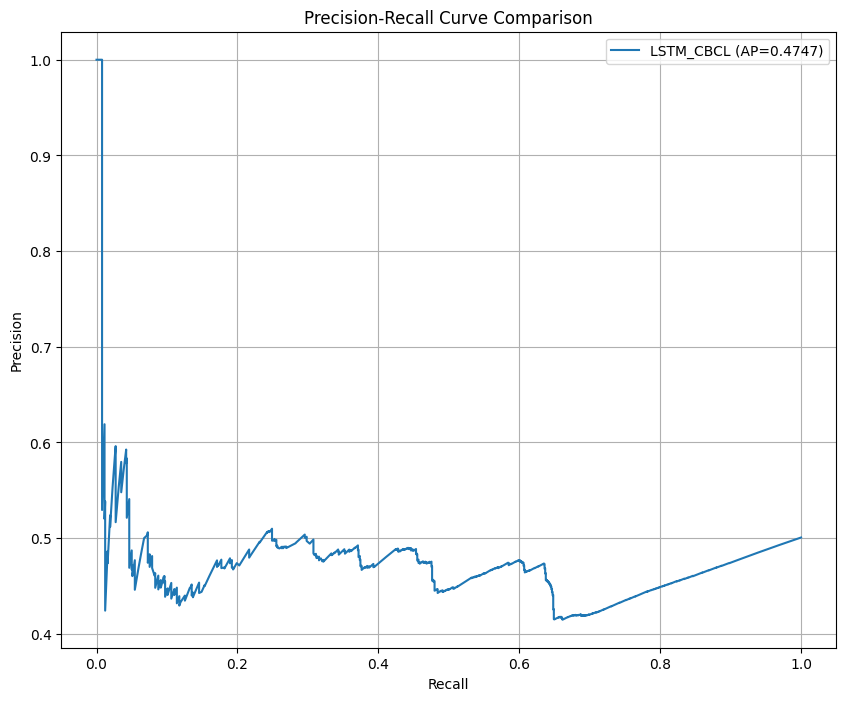

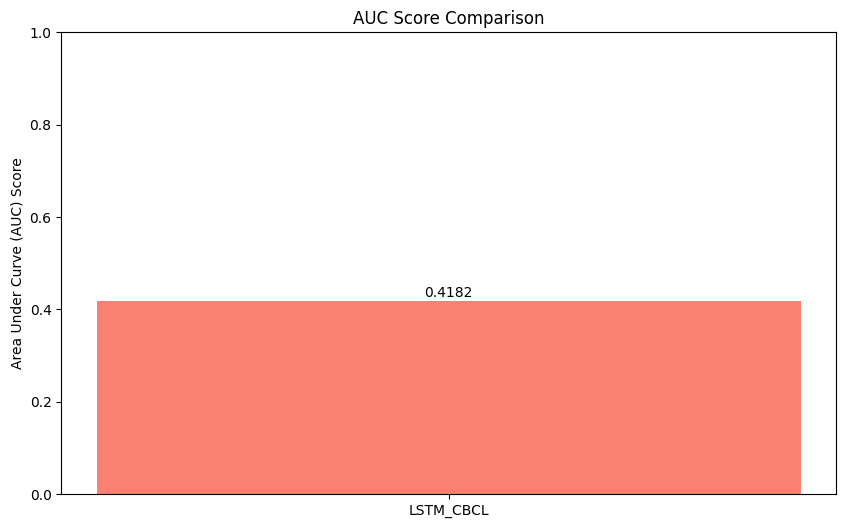

	 Rover M - Number 2
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.054965 - val_loss: 0.055116
	 Breakdown: 
	 MSE: 0.005528, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.054644 - val_loss: 0.054835
	 Breakdown: 
	 MSE: 0.005859, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.054454 - val_loss: 0.054551
	 Breakdown: 
	 MSE: 0.005844, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.054122 - val_loss: 0.054265
	 Breakdown: 
	 MSE: 0.005904, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.053795 - val_loss: 0.053978
	 Breakdown: 
	 MSE: 0.005935, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.053593 - val_loss: 0.053692
	 Breakdown: 
	 MSE: 0.005877, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.053357 - val_loss: 0.053405
	 Breakdown: 
	 MSE: 0.005911, 

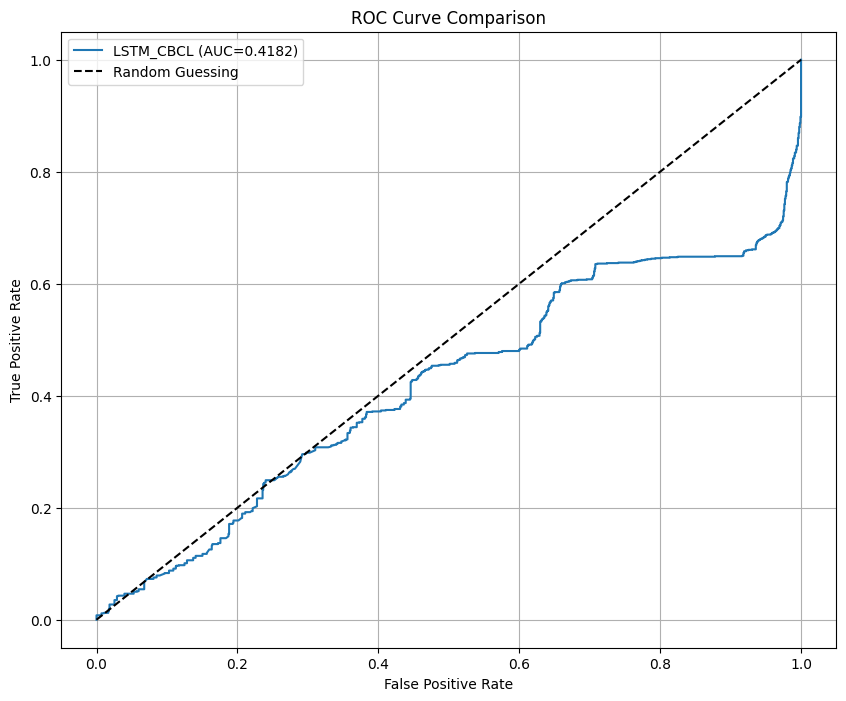

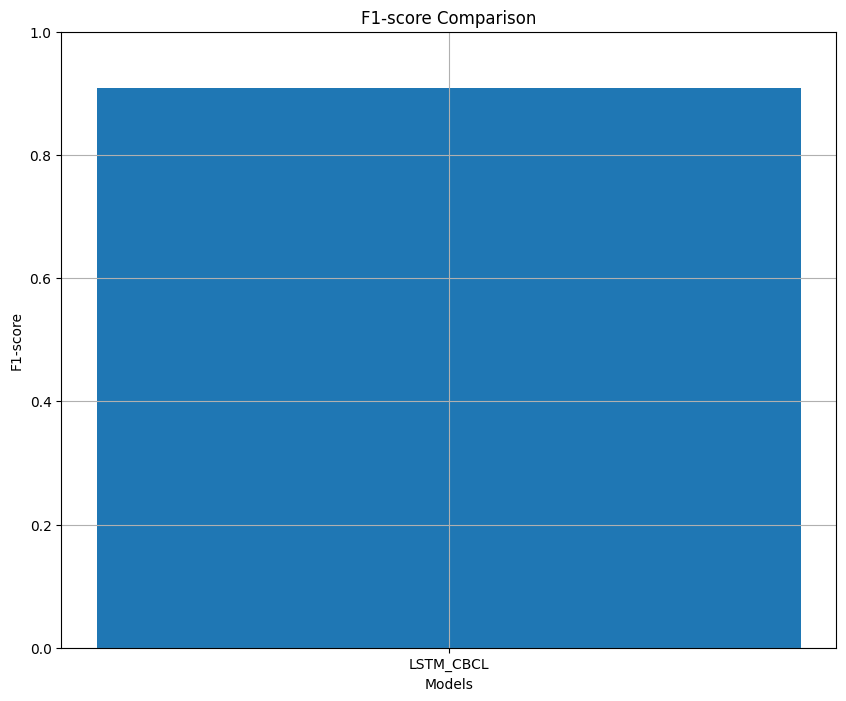

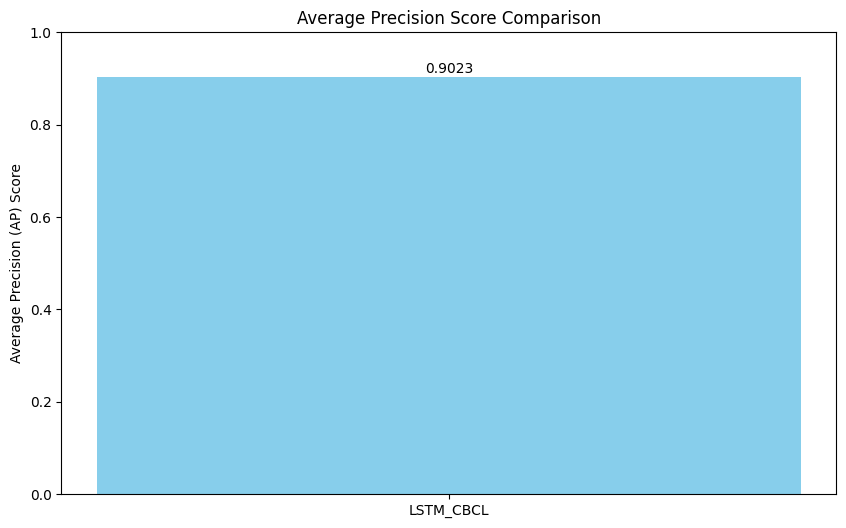

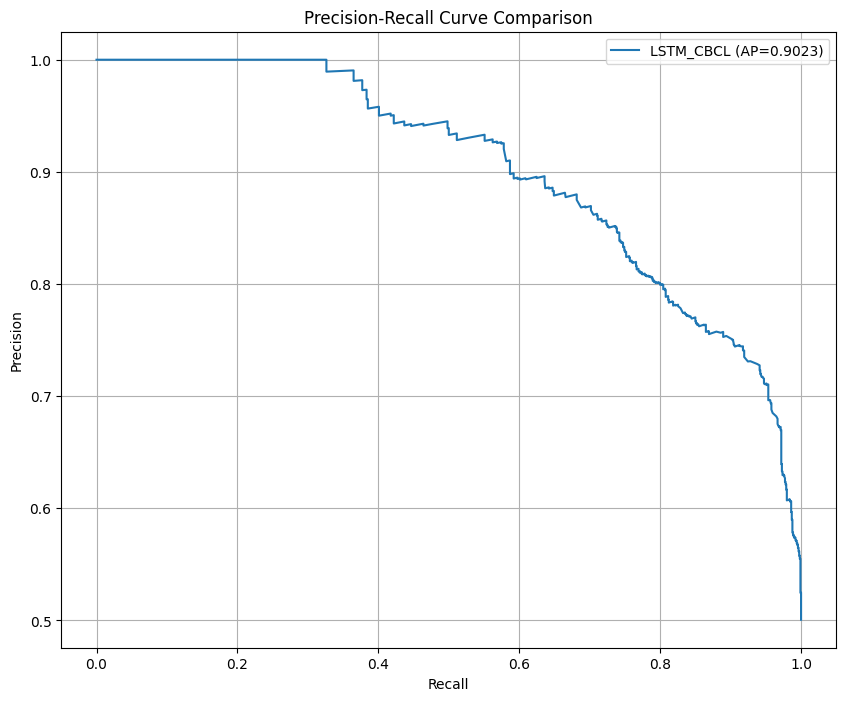

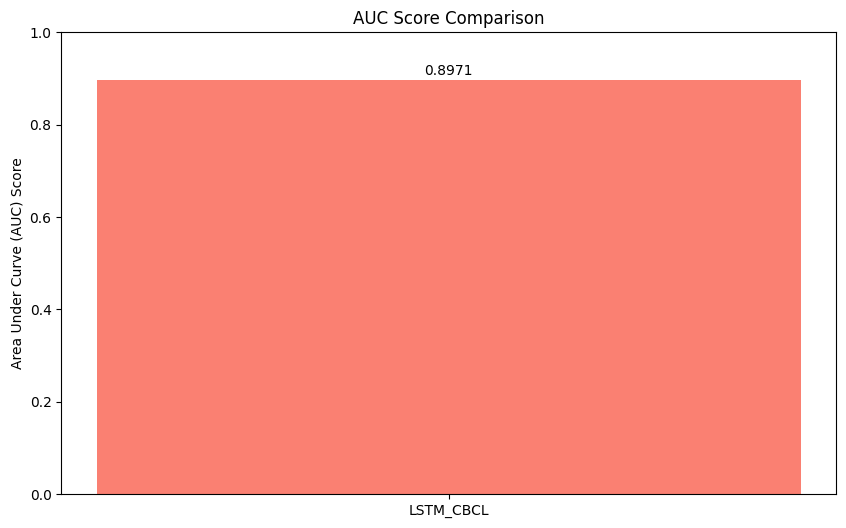

	 Rover P - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.069398 - val_loss: 0.068177
	 Breakdown: 
	 MSE: 0.024312, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.068655 - val_loss: 0.067777
	 Breakdown: 
	 MSE: 0.025161, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.068212 - val_loss: 0.067374
	 Breakdown: 
	 MSE: 0.025655, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.067821 - val_loss: 0.066970
	 Breakdown: 
	 MSE: 0.026582, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.067505 - val_loss: 0.066567
	 Breakdown: 
	 MSE: 0.023601, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.067251 - val_loss: 0.066165
	 Breakdown: 
	 MSE: 0.024280, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.066983 - val_loss: 0.065764
	 Breakdown: 
	 MSE: 0.024517, 

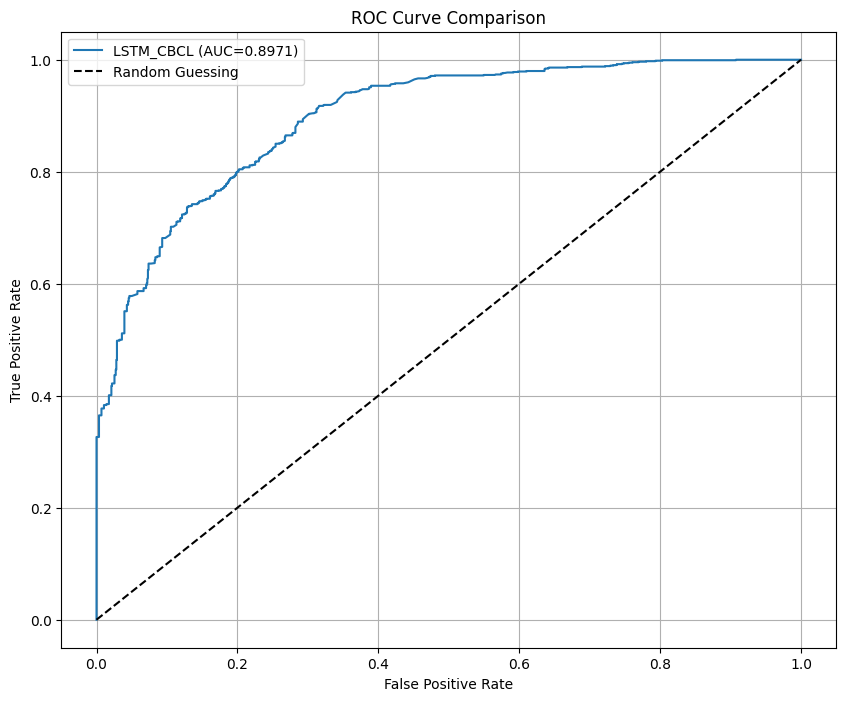

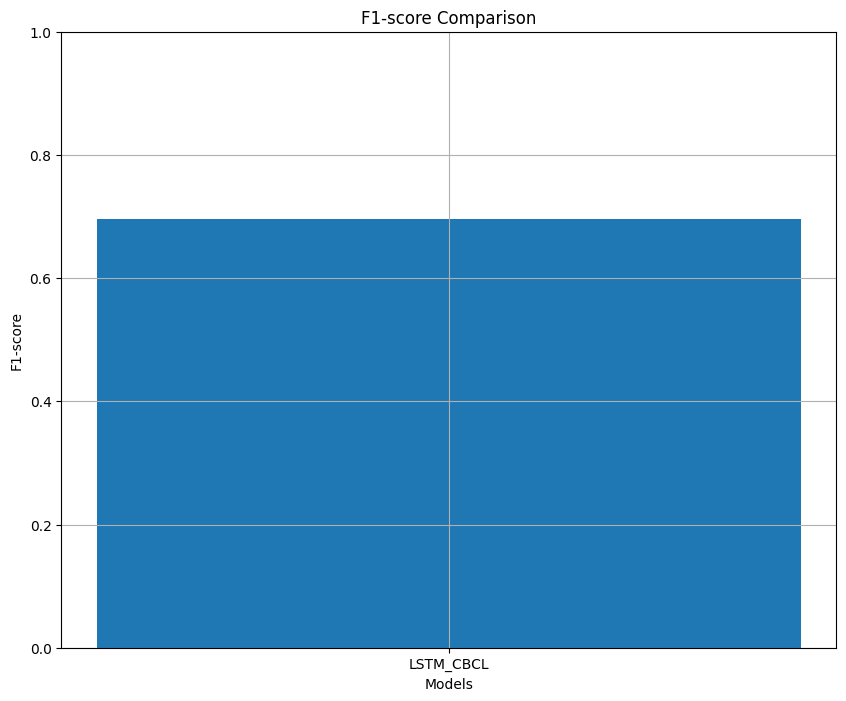

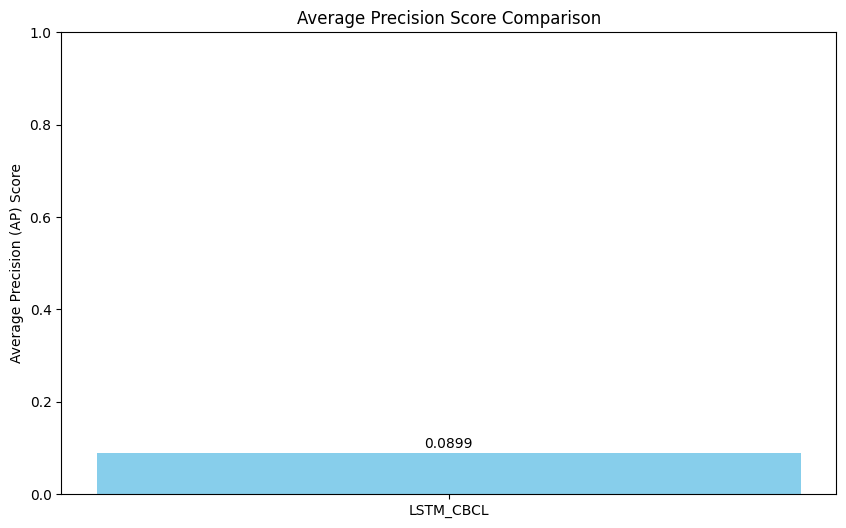

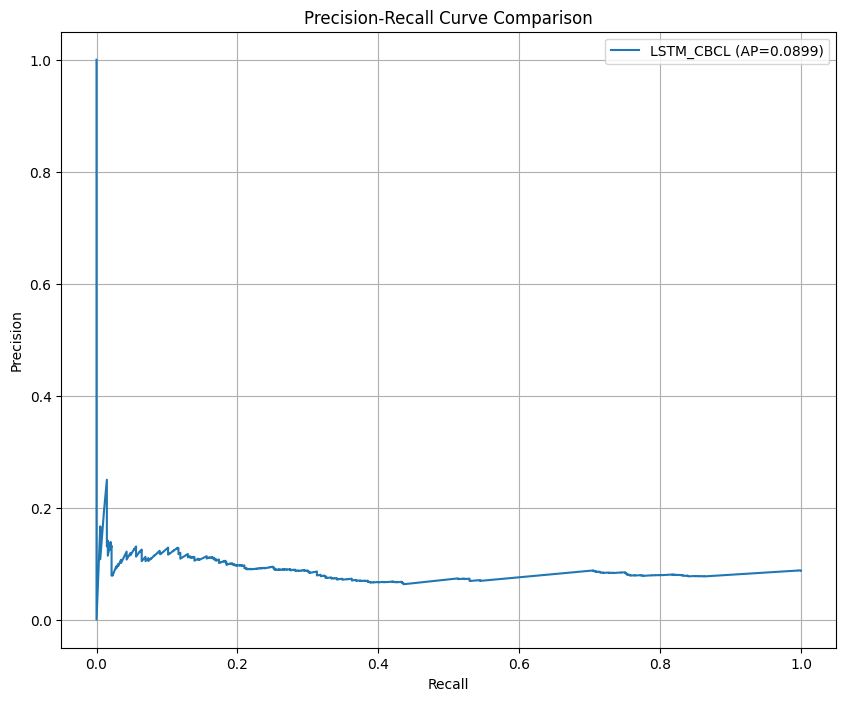

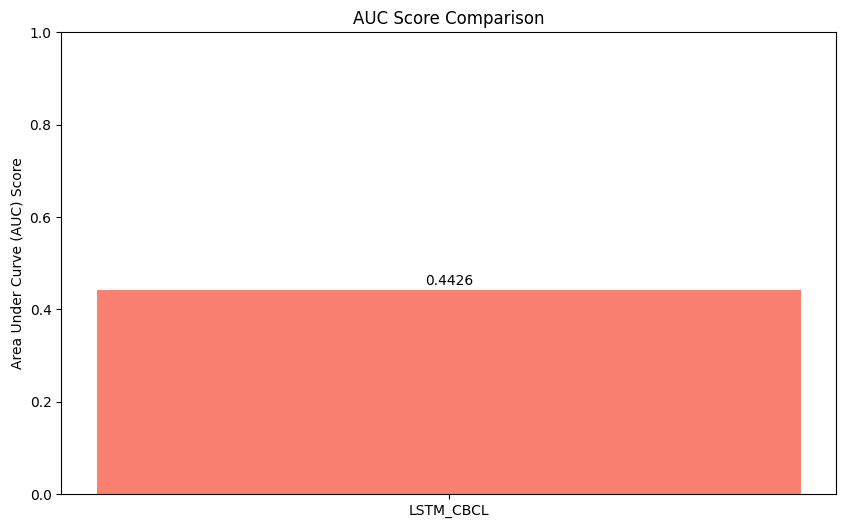

	 Rover R - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.048703 - val_loss: 0.043980
	 Breakdown: 
	 MSE: 0.004097, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.048477 - val_loss: 0.043662
	 Breakdown: 
	 MSE: 0.004669, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.048092 - val_loss: 0.043341
	 Breakdown: 
	 MSE: 0.004639, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.047573 - val_loss: 0.043020
	 Breakdown: 
	 MSE: 0.005151, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.047313 - val_loss: 0.042699
	 Breakdown: 
	 MSE: 0.004829, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.046860 - val_loss: 0.042379
	 Breakdown: 
	 MSE: 0.005013, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.046612 - val_loss: 0.042061
	 Breakdown: 
	 MSE: 0.004290, 

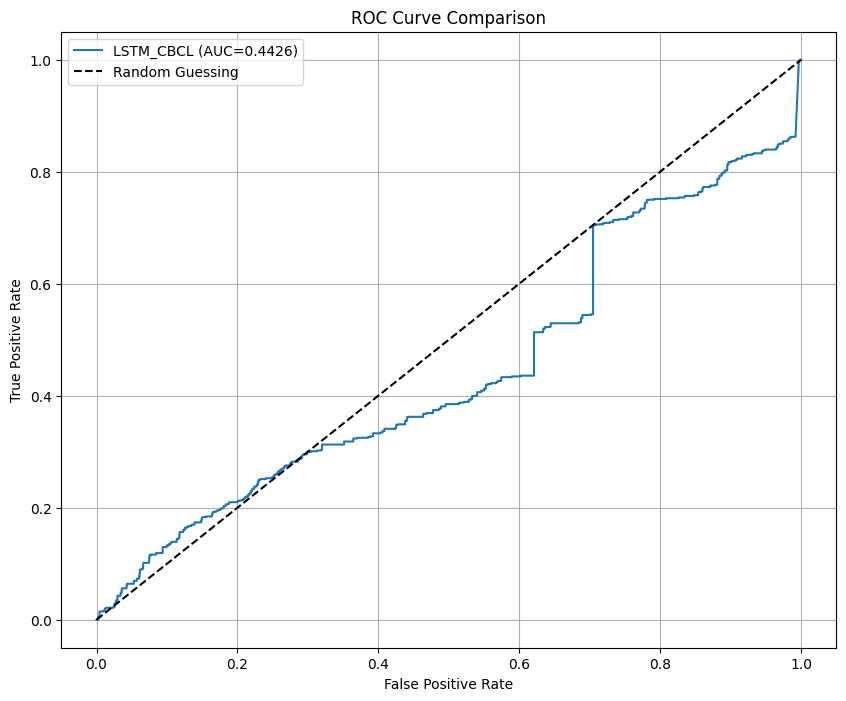

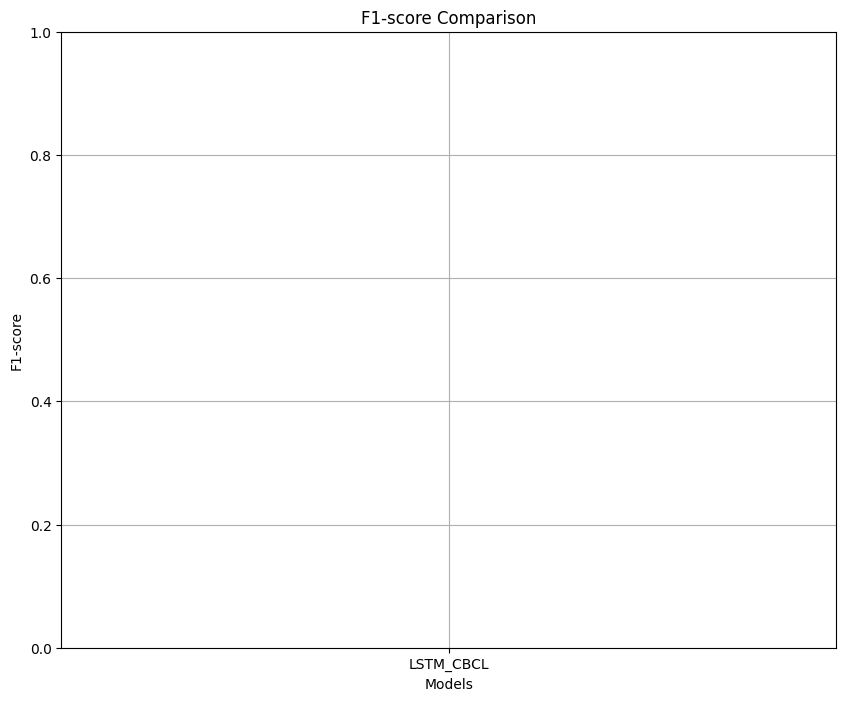

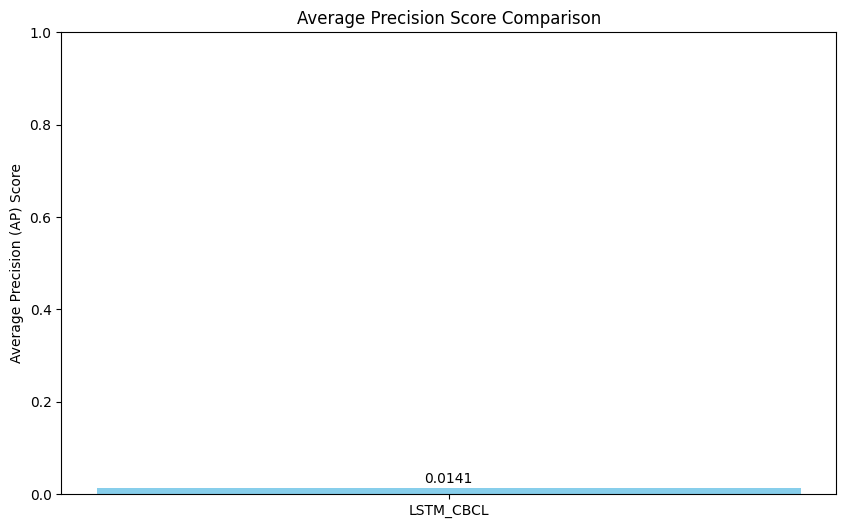

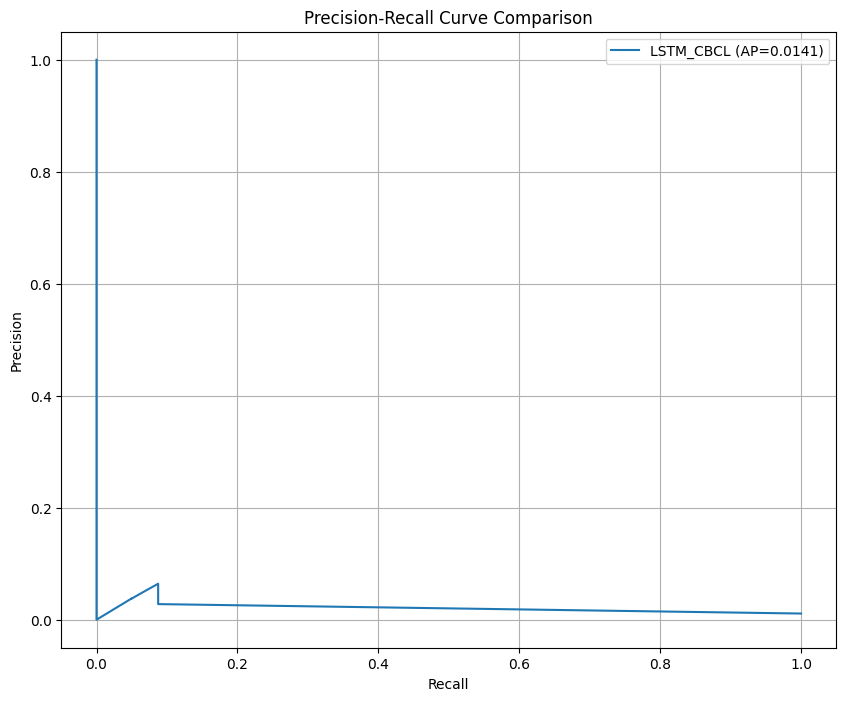

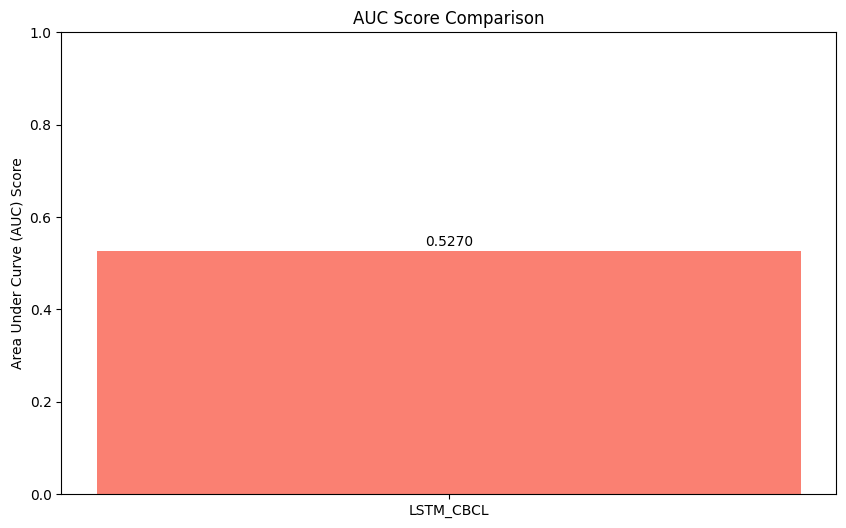

	 Rover S - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.072875 - val_loss: 0.063808
	 Breakdown: 
	 MSE: 0.028426, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.072654 - val_loss: 0.063440
	 Breakdown: 
	 MSE: 0.027699, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.072122 - val_loss: 0.063069
	 Breakdown: 
	 MSE: 0.030788, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.071789 - val_loss: 0.062698
	 Breakdown: 
	 MSE: 0.028310, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.071154 - val_loss: 0.062327
	 Breakdown: 
	 MSE: 0.030182, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.070849 - val_loss: 0.061958
	 Breakdown: 
	 MSE: 0.031309, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.071044 - val_loss: 0.061590
	 Breakdown: 
	 MSE: 0.028035, 

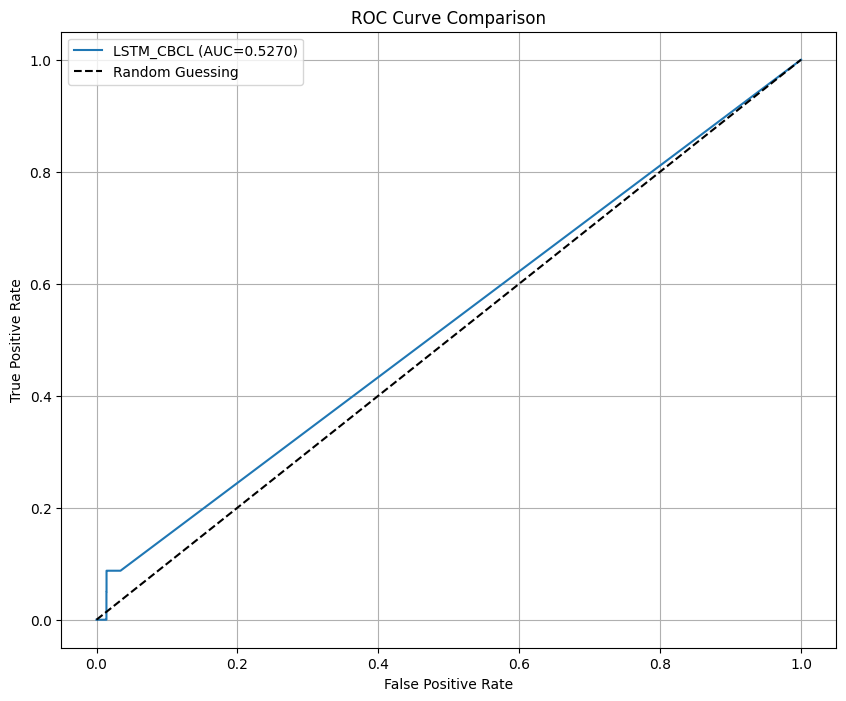

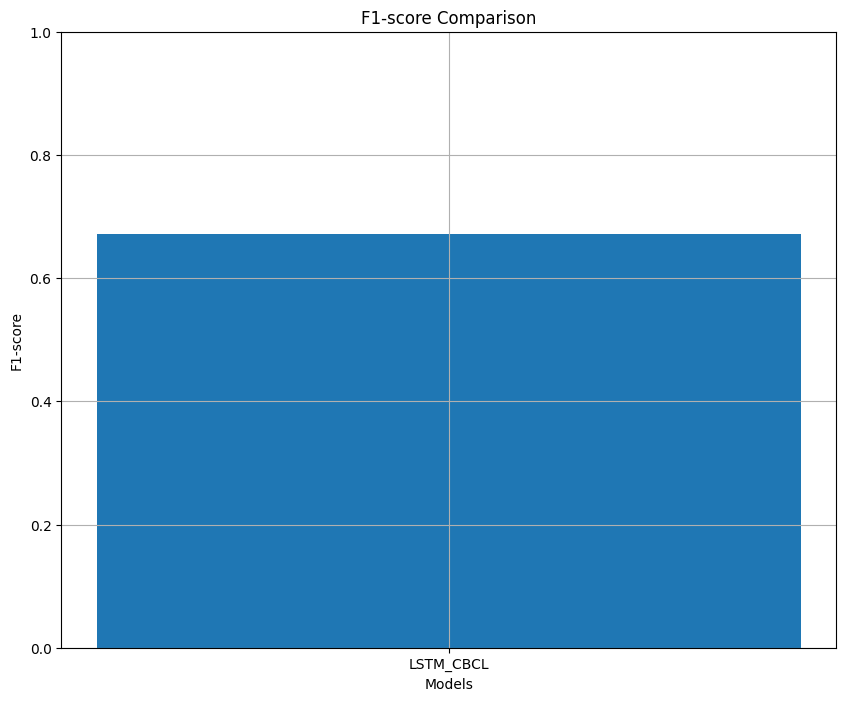

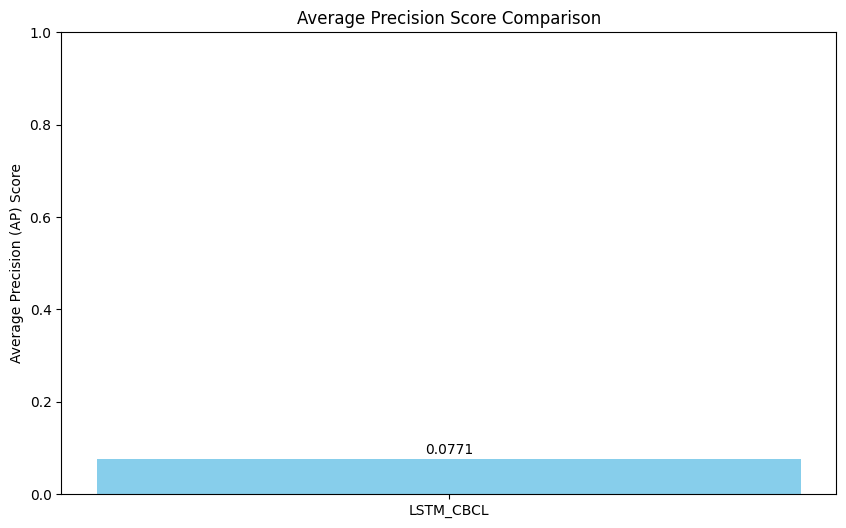

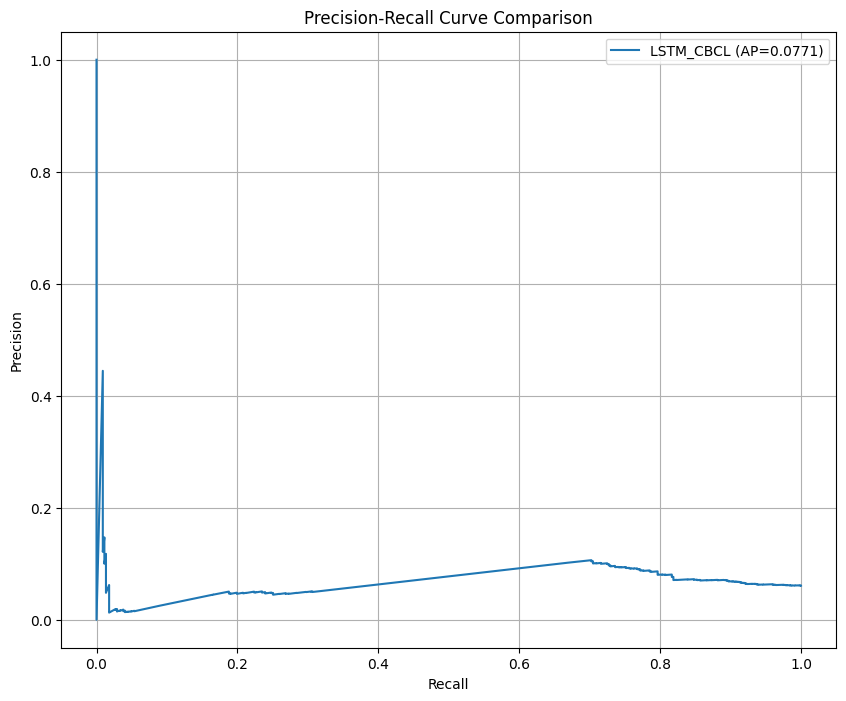

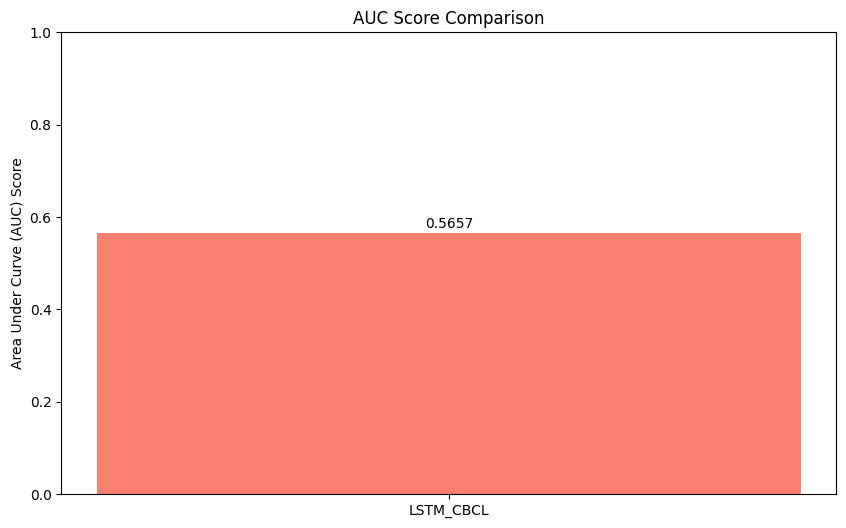

	 Rover T - Number 1
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.072846 - val_loss: 0.072609
	 Breakdown: 
	 MSE: 0.028458, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.072537 - val_loss: 0.072134
	 Breakdown: 
	 MSE: 0.028065, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.072055 - val_loss: 0.071656
	 Breakdown: 
	 MSE: 0.028110, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.071587 - val_loss: 0.071177
	 Breakdown: 
	 MSE: 0.027661, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.071168 - val_loss: 0.070697
	 Breakdown: 
	 MSE: 0.027625, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.070656 - val_loss: 0.070218
	 Breakdown: 
	 MSE: 0.028278, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.070102 - val_loss: 0.069738
	 Breakdown: 
	 MSE: 0.027275, 

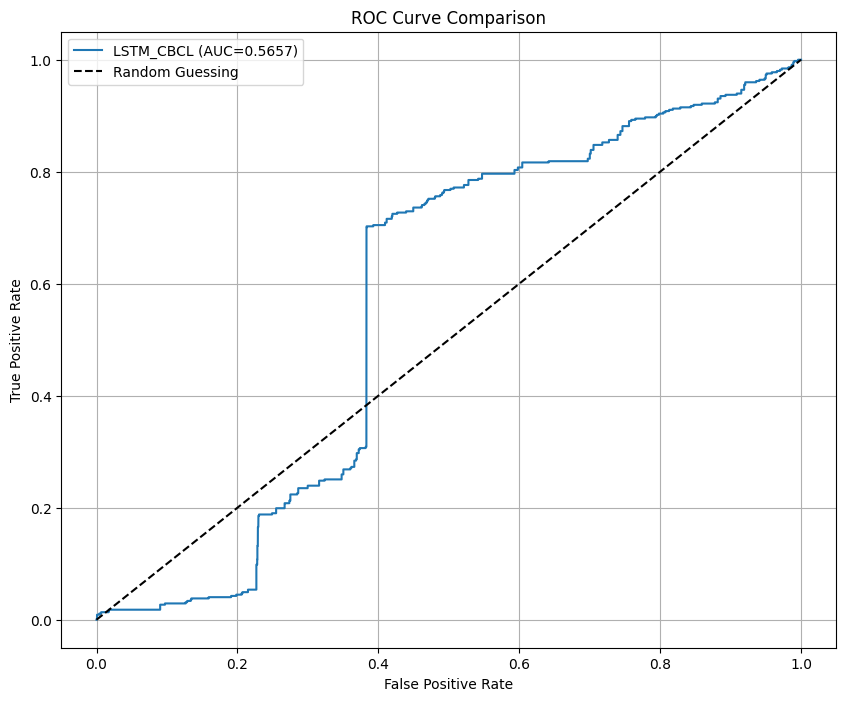

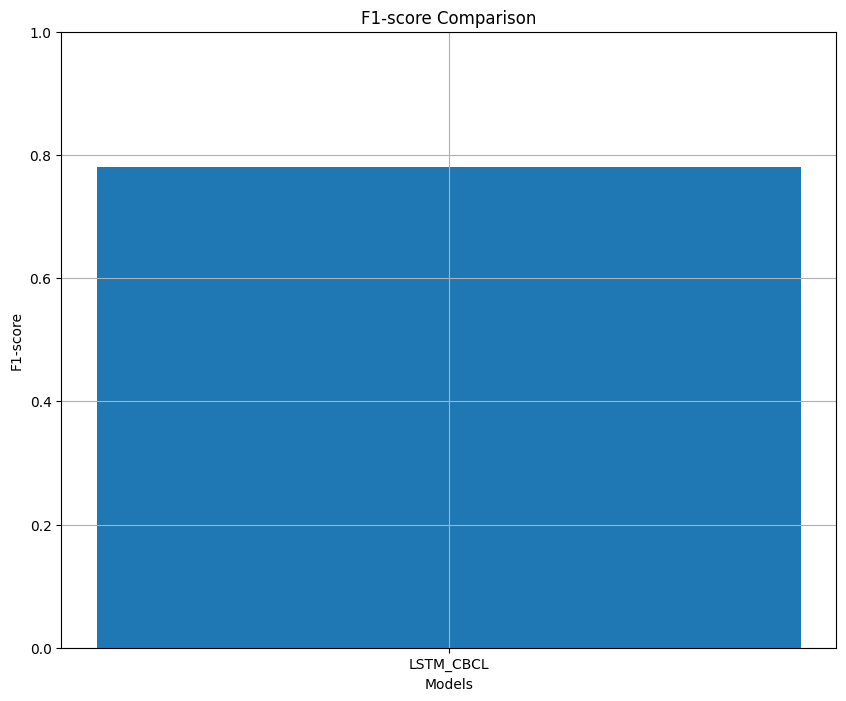

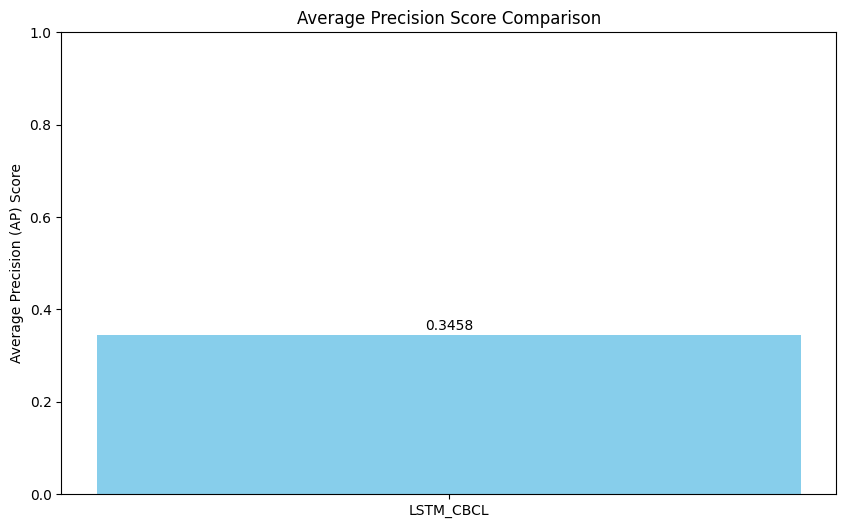

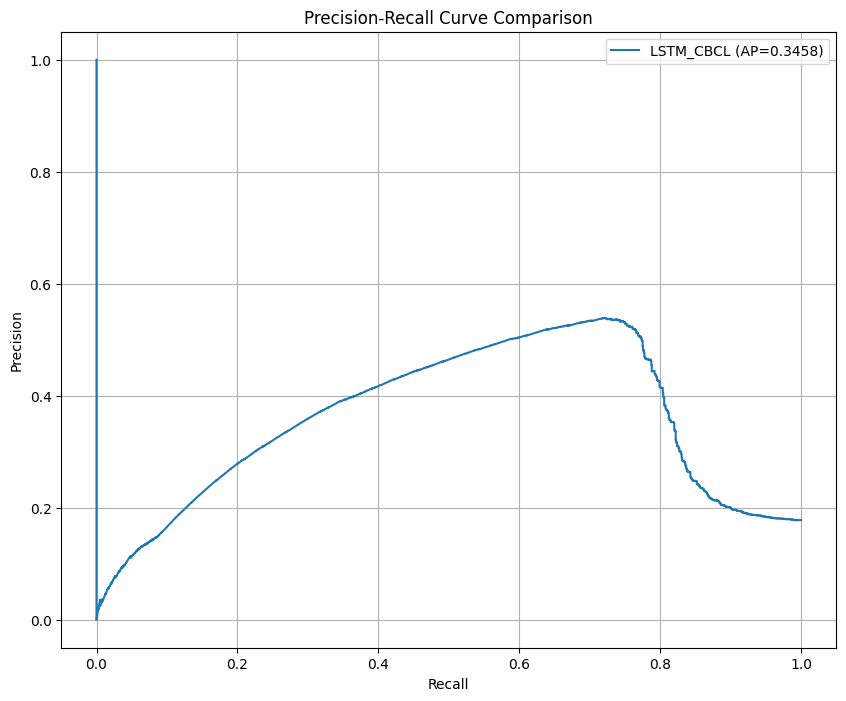

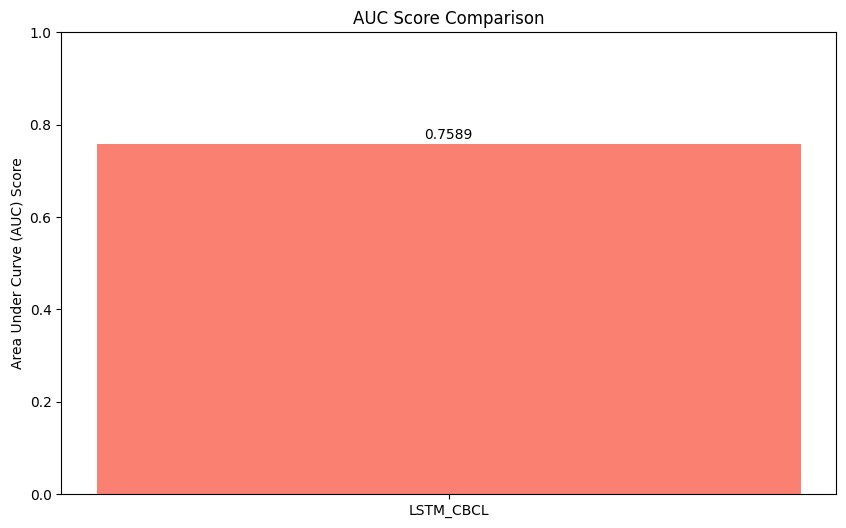

	 Rover T - Number 2
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.078172 - val_loss: 0.072277
	 Breakdown: 
	 MSE: 0.034120, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.078243 - val_loss: 0.071814
	 Breakdown: 
	 MSE: 0.034879, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.077454 - val_loss: 0.071349
	 Breakdown: 
	 MSE: 0.034674, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.077009 - val_loss: 0.070882
	 Breakdown: 
	 MSE: 0.033531, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.076368 - val_loss: 0.070414
	 Breakdown: 
	 MSE: 0.034472, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.076172 - val_loss: 0.069946
	 Breakdown: 
	 MSE: 0.033767, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.075750 - val_loss: 0.069478
	 Breakdown: 
	 MSE: 0.034534, 

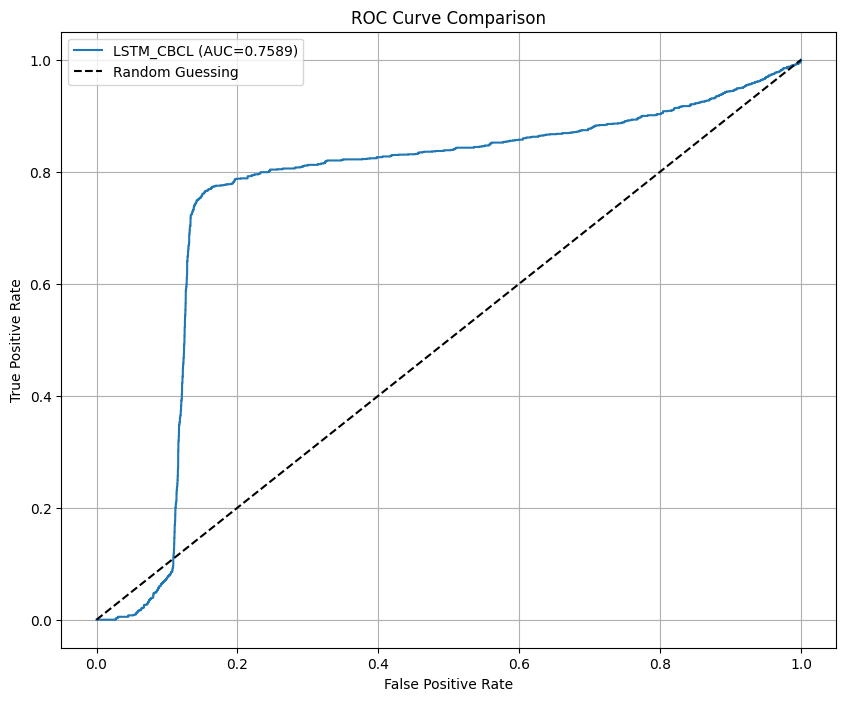

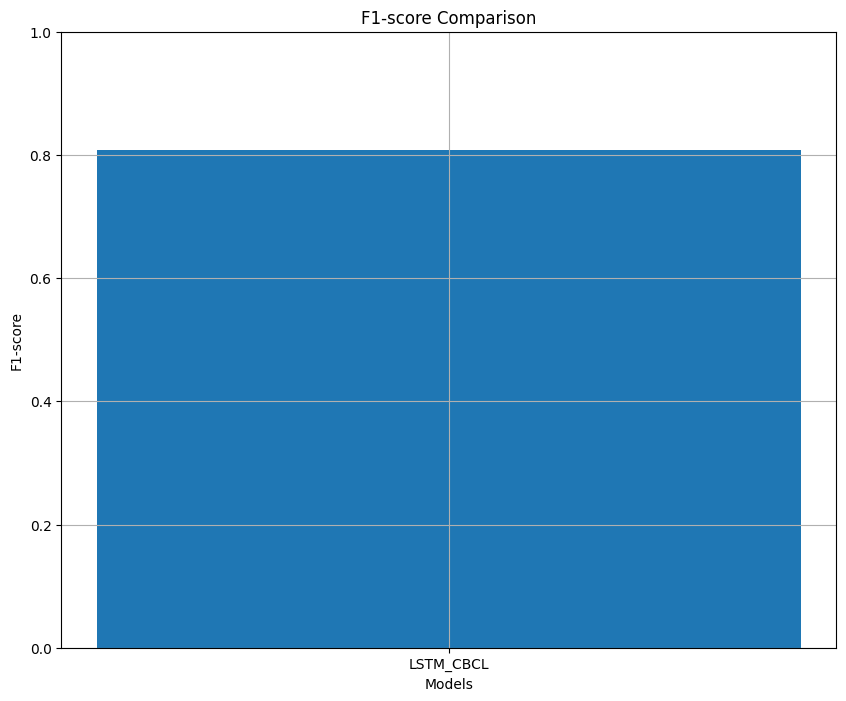

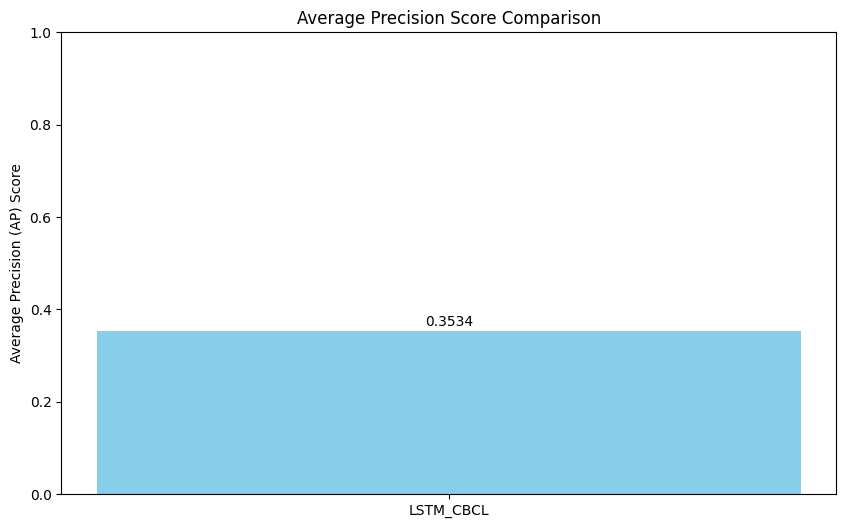

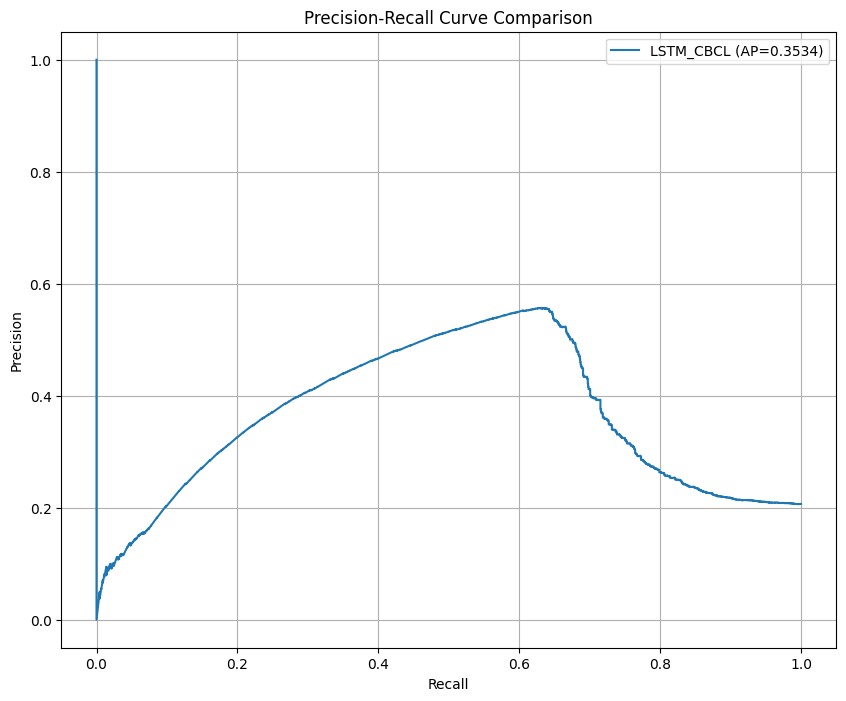

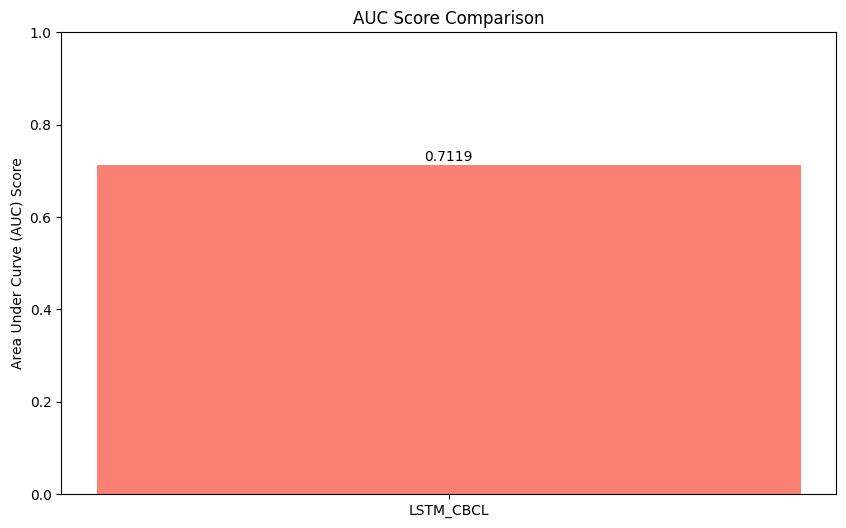

Testing models on WADI dataset:
		Training: LSTM_CBCL
Epoch 1/100 - train_loss: 0.221200 - val_loss: 0.176961
	 Breakdown: 
	 MSE: 0.136240, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 2/100 - train_loss: 0.128523 - val_loss: 0.105163
	 Breakdown: 
	 MSE: 0.068637, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 3/100 - train_loss: 0.092014 - val_loss: 0.082569
	 Breakdown: 
	 MSE: 0.051322, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 4/100 - train_loss: 0.074058 - val_loss: 0.069207
	 Breakdown: 
	 MSE: 0.042324, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 5/100 - train_loss: 0.063678 - val_loss: 0.061470
	 Breakdown: 
	 MSE: 0.039641, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 6/100 - train_loss: 0.057458 - val_loss: 0.056548
	 Breakdown: 
	 MSE: 0.036998, Contrastive: 0.000000, Cluster: 0.000000, Hinge: 0.000000
Epoch 7/100 - train_loss: 0.053160 - val_loss: 0.052811
	 Breakdown: 
	 MSE:

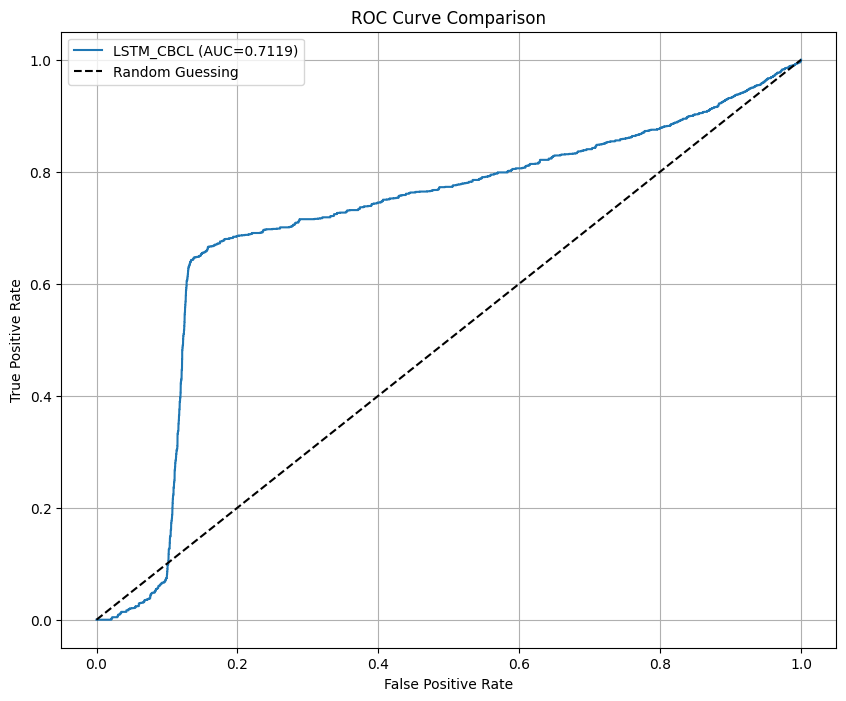

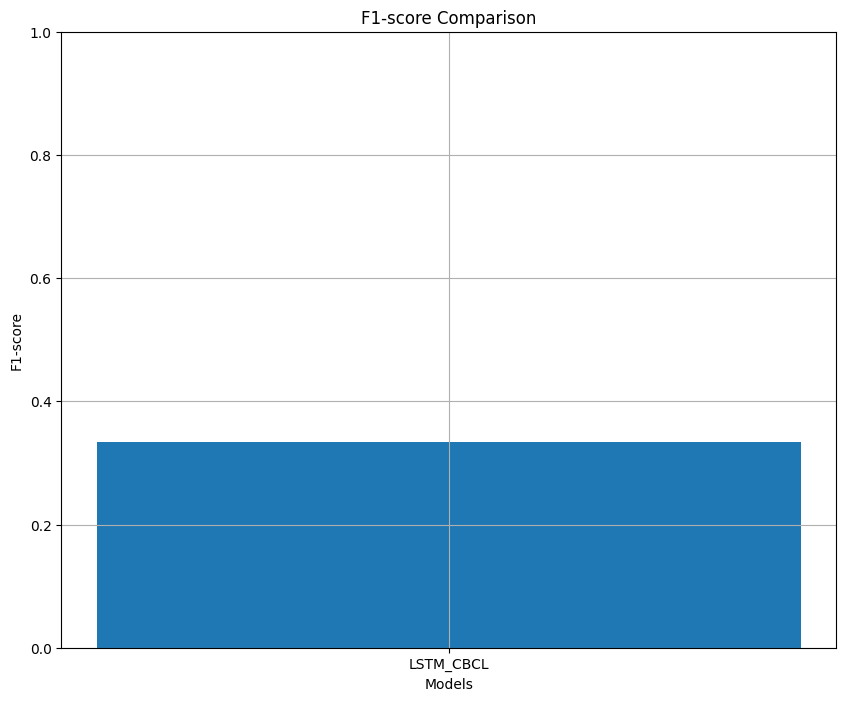

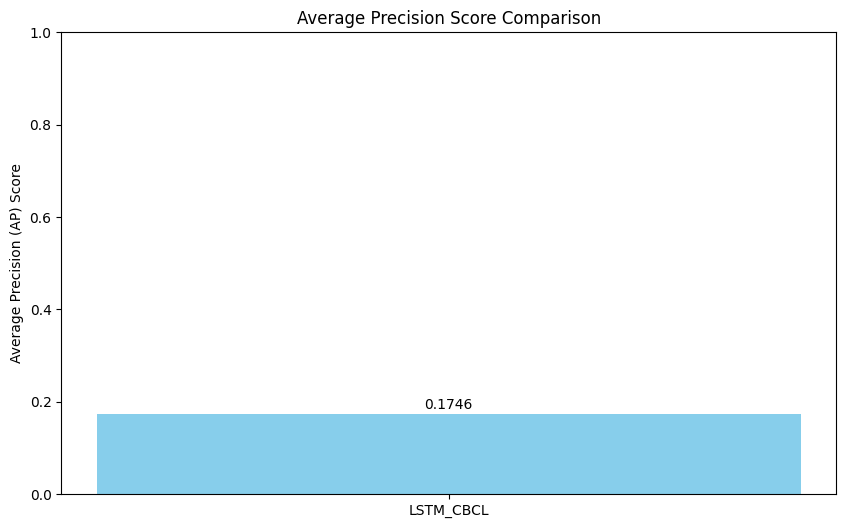

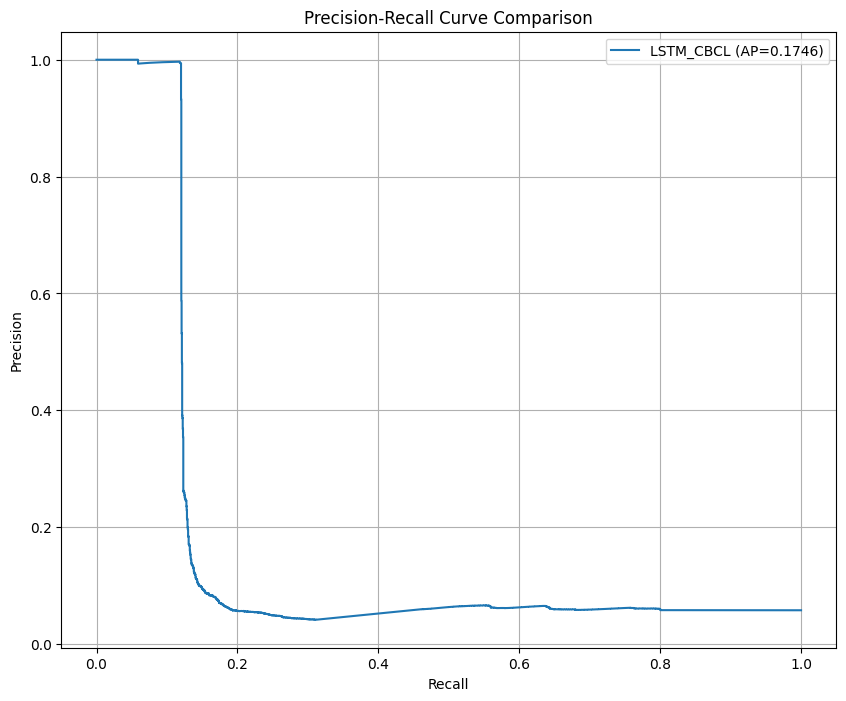

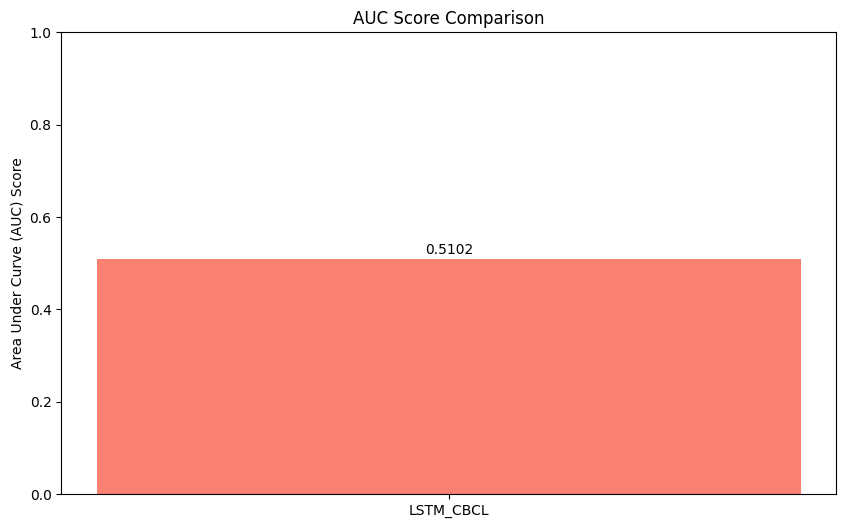

Average F1 Scores for SMD dataset:
	 LSTM_CBCL : 0.6806
Average F1 Scores for PSM dataset:
	 LSTM_CBCL : 0.7238
Average F1 Scores for SMAP_MSL dataset:
	 LSTM_CBCL : 0.5298
Average F1 Scores for WADI dataset:
	 LSTM_CBCL : 0.3333
Average ROC-AUC Scores for SMD dataset:
	 LSTM_CBCL : 0.8409
Average ROC-AUC Scores for PSM dataset:
	 LSTM_CBCL : 0.5697
Average ROC-AUC Scores for SMAP_MSL dataset:
	 LSTM_CBCL : 0.6231
Average ROC-AUC Scores for WADI dataset:
	 LSTM_CBCL : 0.5102
{'SMD': {'LSTM_CBCL': 0.6806148673280515}, 'PSM': {'LSTM_CBCL': 0.7238290331496203}, 'SMAP_MSL': {'LSTM_CBCL': 0.5298082756370072}, 'WADI': {'LSTM_CBCL': 0.33334826829159014}} {'SMD': {'LSTM_CBCL': 0.8408823217282486}, 'PSM': {'LSTM_CBCL': 0.569713612674142}, 'SMAP_MSL': {'LSTM_CBCL': 0.6231160759397169}, 'WADI': {'LSTM_CBCL': 0.5102453252075292}}
Average F1 Scores for SMD dataset:
	 LSTM_CBCL : 0.6806
Average F1 Scores for PSM dataset:
	 LSTM_CBCL : 0.7238
Average F1 Scores for SMAP_MSL dataset:
	 LSTM_CBCL : 0.52

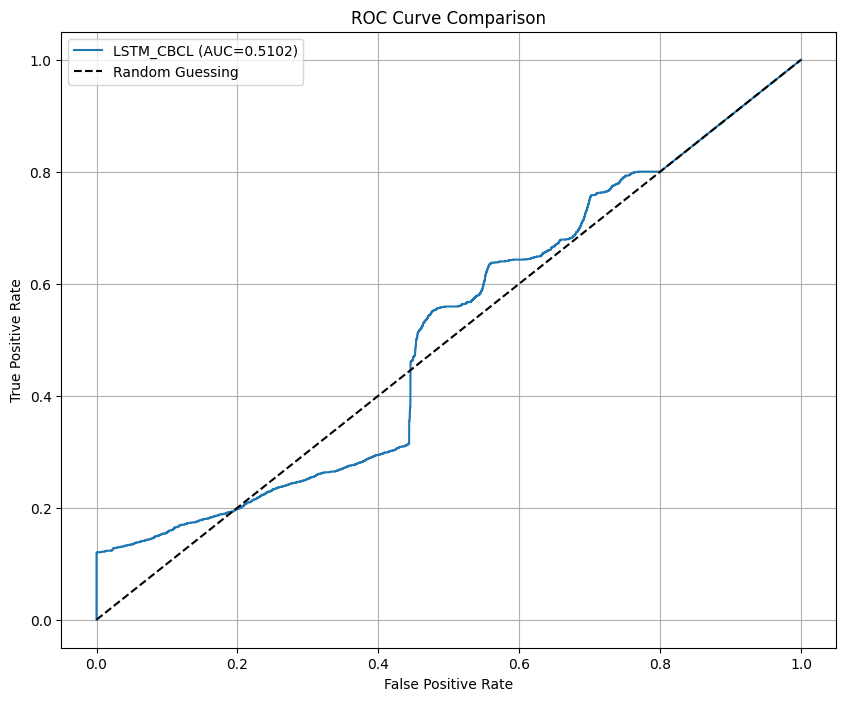

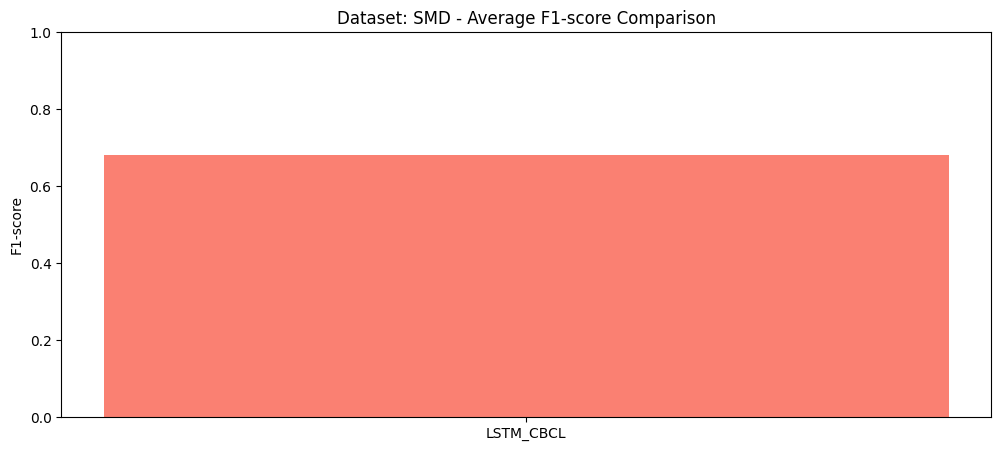

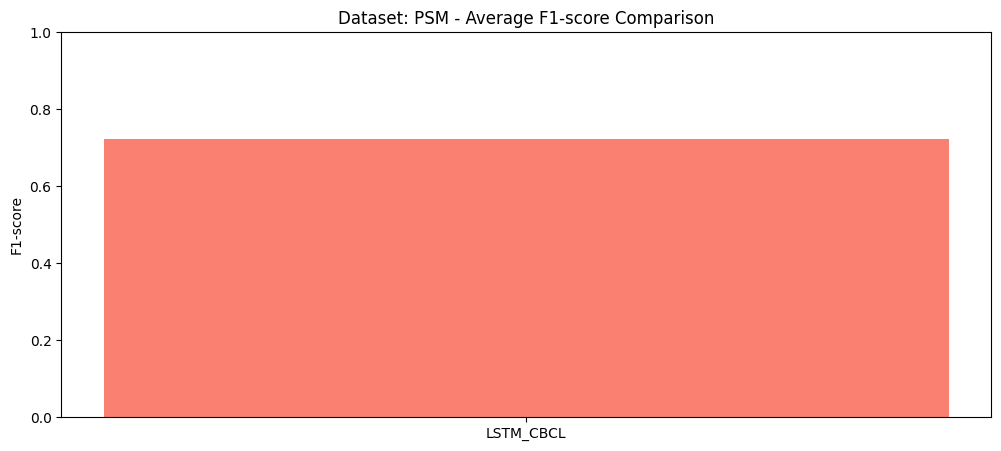

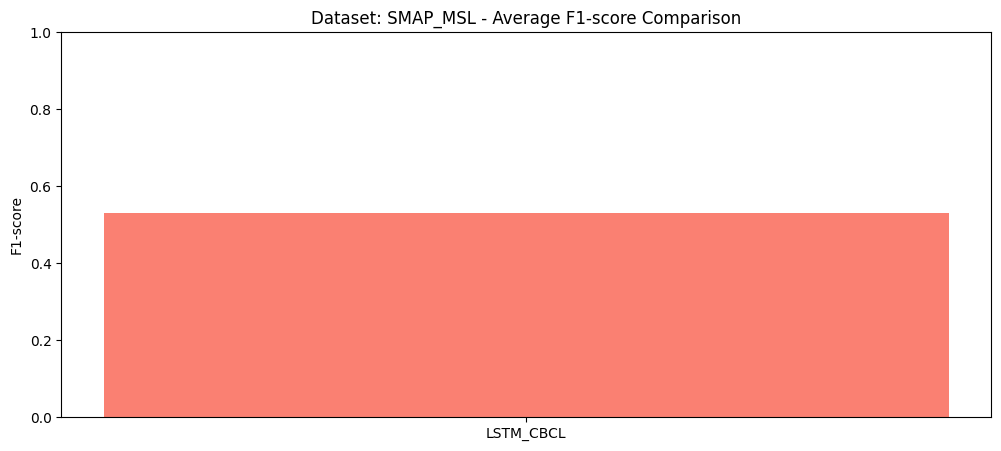

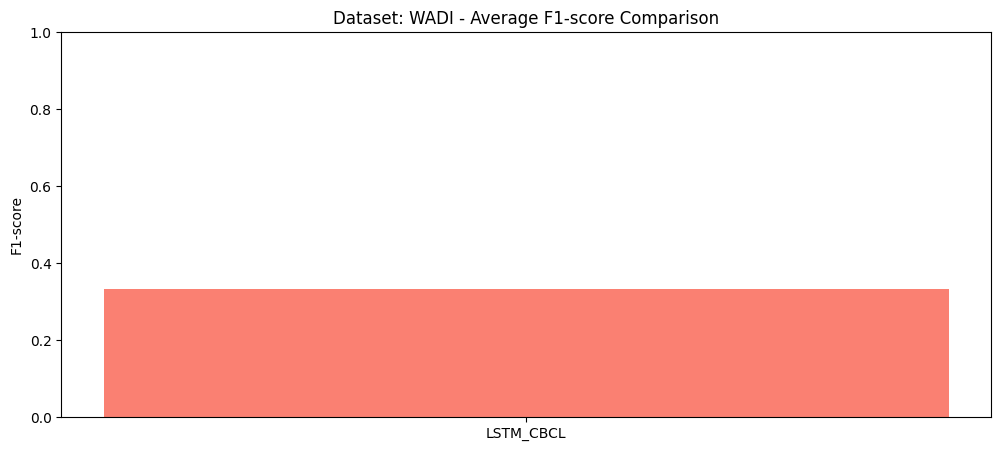

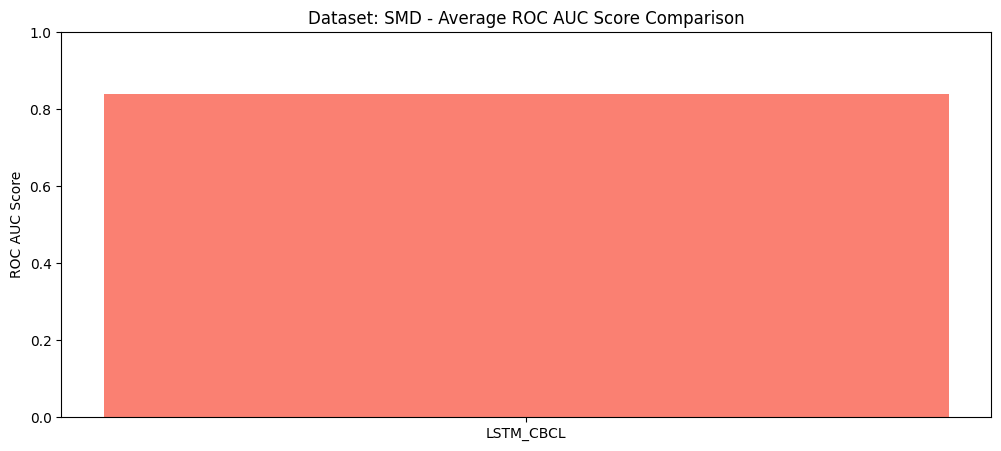

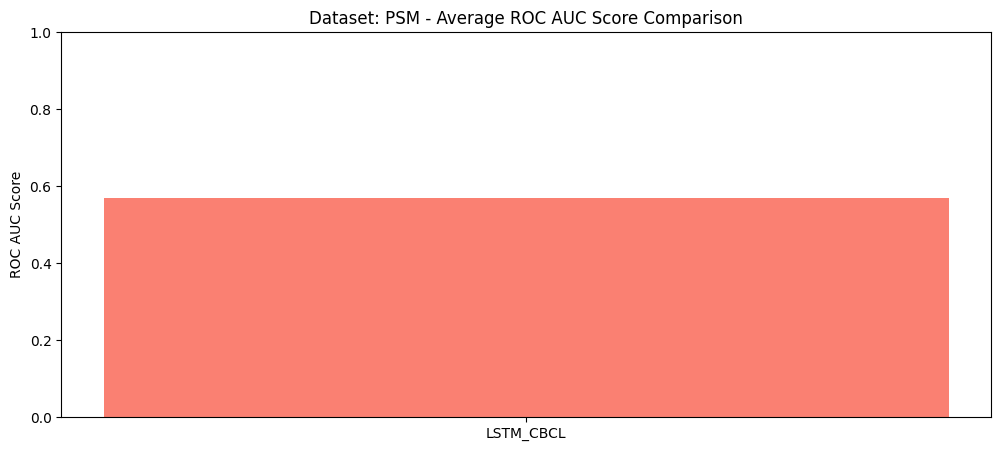

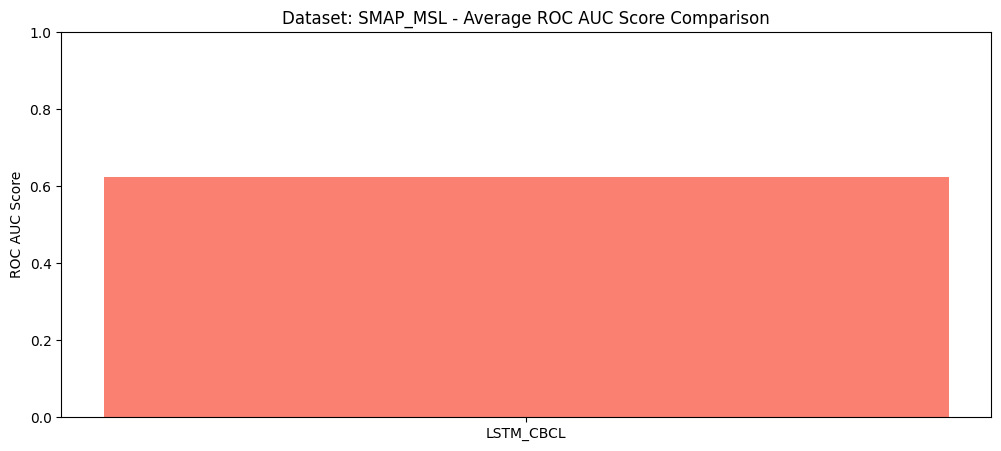

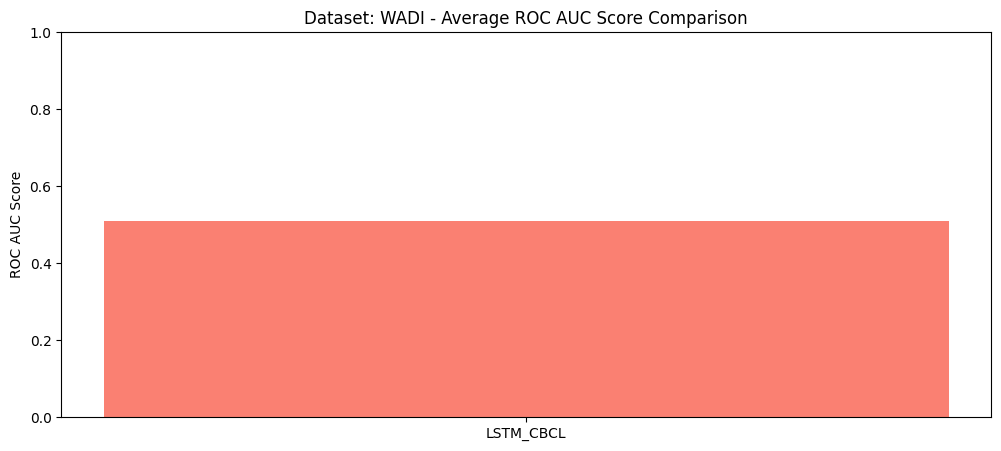

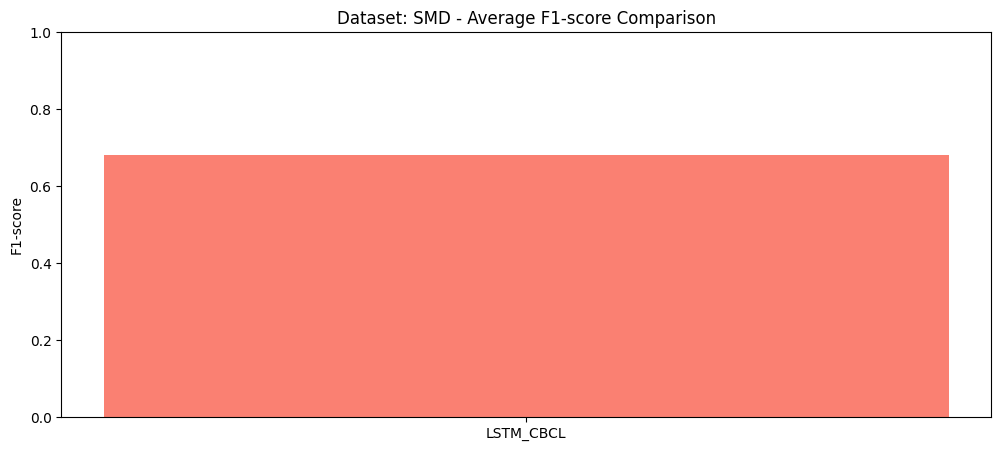

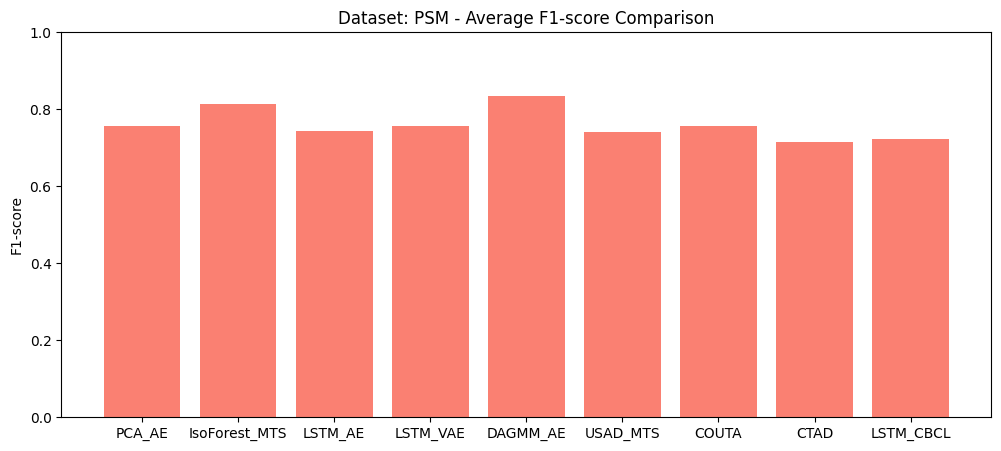

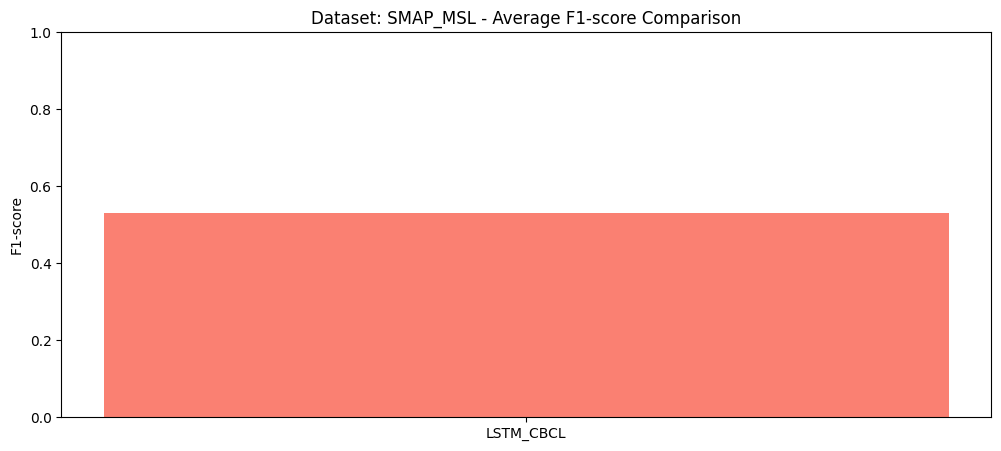

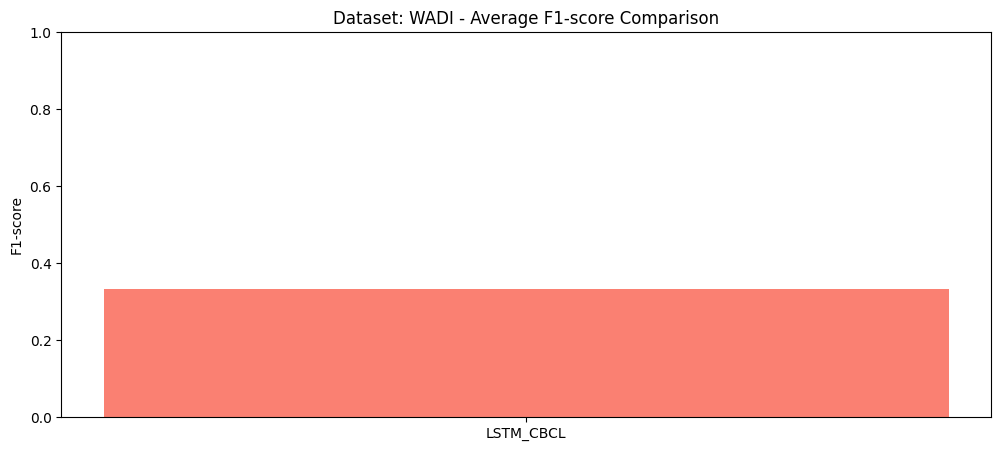

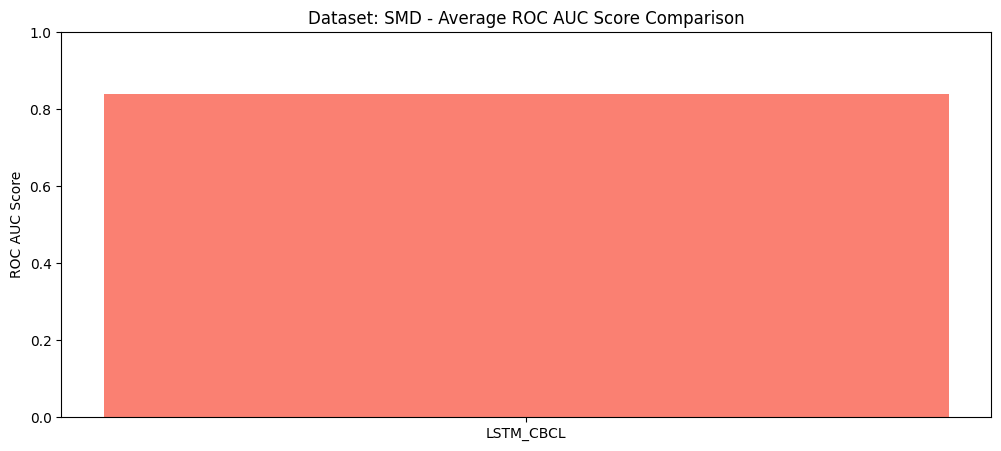

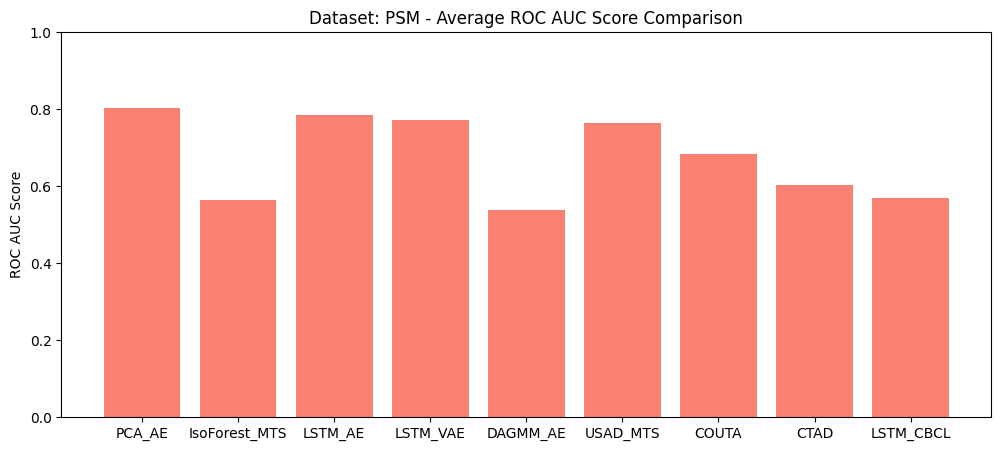

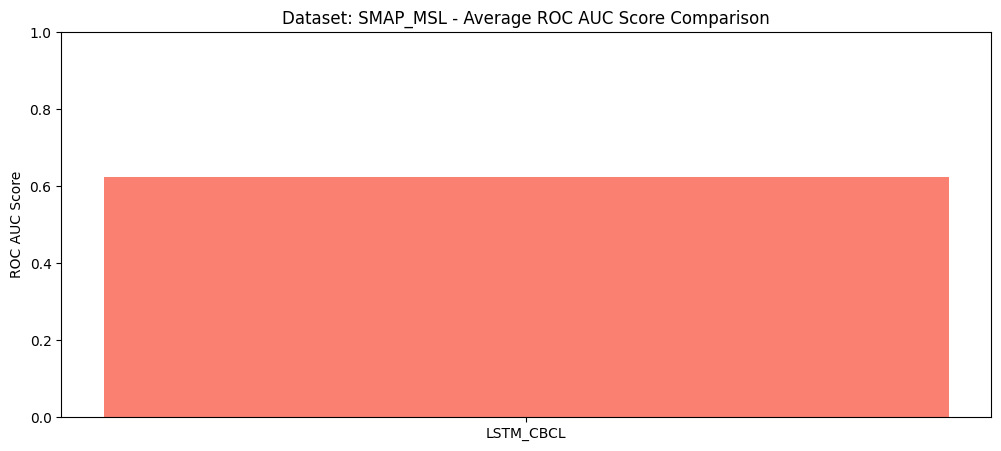

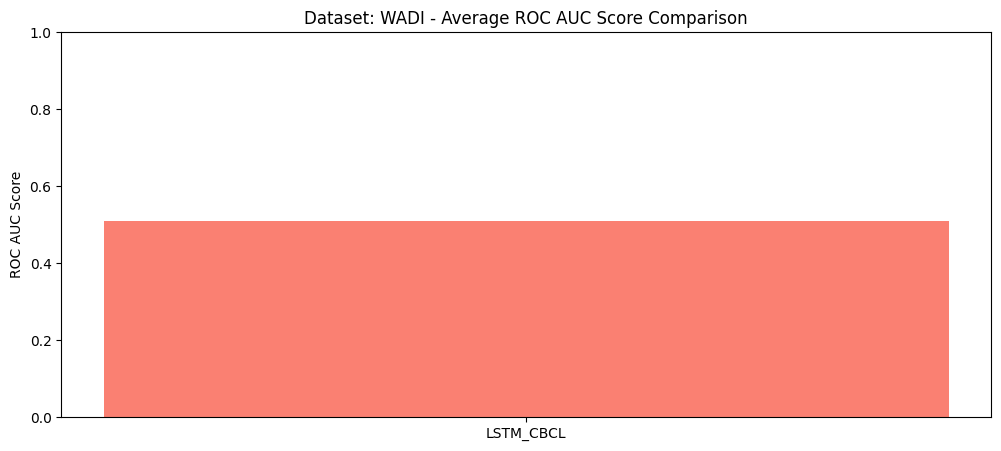

In [9]:
new_f1s, new_rocs = extra_model_results(use_timestamp_level=True, use_point_adjust=True, verbose=1)
compare_existing_scores(dir='Model Comparisons - Point Adjusted/Dataset Performance/', new_f1s=new_f1s, new_rocs=new_rocs)